# 30-Month Work-Disability Risk in SLE


- **Outcome:** transition from `Employed` to `Disability Benefit` status
  (formal work disability), instead of 180-day mortality.
- **Horizon:** 30 months (≈913 days).
- **Data:** visit-level SLE registry extract from Toronto Lupus Clinic.
- **External validation is intentionally omitted**, per task instructions.
- **Evaluation:** every model (LogReg, RSF, CoxPH, GRU, LSTM) is tuned and
  scored with **repeated, patient-grouped, stratified K-fold cross-validation**
  (never with an in-sample train == test fit) -- see "Repeated Cross-Validation
  Infrastructure" below, used by every Model N/5 section. Each model section
  additionally refits once on all landmark rows to produce the model object used
  for risk-sensitivity curves, the SHAP dashboard and the cross-model calibration
  plot; that refit is never the source of a reported performance number.

The landmarking and censoring logic below follows the "Step 1–3, as
implemented (v16)" specification supplied with this task: a growing-window
landmark set built from calendar-time visit gaps, with death (12-month) and
administrative-exit (6-month) censoring trims, and each landmark row
inverse-weighted by the number of landmarks contributed by its patient.

**Implementation note:** the sandbox this notebook was built in could not fit
both TensorFlow and PyTorch on disk, so the GRU/LSTM sequential models use
**PyTorch** rather than TensorFlow/Keras — architecturally identical
(2-layer recurrent classifier with dropout + batch-norm and a
time-distributed sigmoid head, trained on balanced class minibatches) but a
different framework. **Missing-feature imputation** (for LogReg, RSF, CoxPH,
GRU and LSTM alike) uses **MICE** (Multiple Imputation by Chained Equations,
scikit-learn's `IterativeImputer`), fit on the training rows of each split
only, in place of the denoising-autoencoder imputer used previously.

**Decision-model update:**

- The fixed *85 % sensitivity* operating threshold has been replaced by a
  **cost-weighted decision model**. Every model's threshold is now the one that
  minimises `COST_FN * FN + COST_FP * FP` over the landmark set. Rather than an
  assumed clinical / health-economic cost ratio, `COST_FN` and `COST_FP` are
  set **from the data**: `COST_FP = 1.0` and `COST_FN` is the observed
  negative:positive class-imbalance ratio (how much rarer 30-month work
  disability is than its absence) -- the same "inverse frequency" principle
  behind `class_weight='balanced'`, used elsewhere in this pipeline. Inside
  the repeated-CV loop this ratio is recomputed separately in every fold from
  that fold's own training labels, so no test-fold information leaks into the
  cost weights (see `compute_cost_weights` in the utilities cell).
- **Permutation feature importance** has been replaced, in every model, by
  **risk-sensitivity plots** (how the predicted 30-month risk moves as each
  feature is varied over its observed 5th–95th percentile range, all other
  features left as observed), and every model now also reports a
  **confusion matrix** at its cost-optimal threshold.


## Shared utilities (metrics, calibration, plotting, MICE imputer)

In [1]:
"""Shared utilities: metrics, calibration, plots -- mirrors the reporting
helpers used across every model in the original notebook (Wilson CIs,
cost-weighted threshold selection, calibration slope/intercept, decision
curve analysis, risk-distribution + calibration plot, confusion matrices,
risk-sensitivity plots)."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (recall_score, confusion_matrix, balanced_accuracy_score,
                              brier_score_loss, roc_curve, auc, precision_recall_curve,
                              average_precision_score)
from sklearn.calibration import calibration_curve
from lifelines.utils import concordance_index
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sns.set_style("whitegrid")
OUT_DIR = "figs"


def wilson_ci(p, n, z=1.96):
    if n <= 0:
        return 0.0, 0.0
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    err = z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2))) / denom
    return max(0, center - err), min(1, center + err)


# ---------------------------------------------------------------------------
# Cost-weighted decision model (replaces the fixed 85%-sensitivity threshold)
# ---------------------------------------------------------------------------
# Every alert decision is scored with an explicit misclassification cost:
#     total cost = COST_FN * (missed disability events)
#                + COST_FP * (unnecessary alerts)
# and the operating threshold is the one that minimises that cost. Only the
# RATIO COST_FN : COST_FP changes the chosen threshold. Rather than assuming an
# external clinical / health-economic cost figure, that ratio is derived
# directly from the data: COST_FP is fixed at 1.0 and COST_FN is set to the
# observed negative:positive class-imbalance ratio (how much rarer the
# 30-month work-disability outcome is than its absence) -- the same "inverse
# frequency" principle behind `class_weight='balanced'`, used elsewhere in
# this pipeline (LogReg, CoxPH's oversampled fit). A rarer event costs
# proportionally more to miss. See `compute_cost_weights` below; COST_FN /
# COST_FP are left as None here and set once `land["label"]` exists (right
# after the landmark set is built) -- inside the repeated-CV loop each fold
# instead computes its own from that fold's own training labels only, so no
# test-fold information leaks into the cost ratio.
# NB: risk scores are min-max standardised, so the threshold is a position on
# that 0-1 score, not a literal probability; it is therefore found empirically
# rather than from the closed-form cost_fp / (cost_fp + cost_fn) rule.
# Guarded assignment: this cell (shared utilities) is sometimes re-run later
# in the session (e.g. to pick up an edit) *after* Cell 4 has already derived
# COST_FN / COST_FP from the data. A plain `COST_FN = None` here would silently
# reset those globals back to None on that re-run and break every downstream
# function that reads them (`cost_curve`, `print_cost_metrics`, `cv_metrics`, ...)
# with a cryptic "unsupported operand type(s) for *: 'NoneType' and 'int'".
# Only initialise them the first time this cell runs in a session.
if "COST_FN" not in globals():
    COST_FN = None   # cost of a missed 30-month work-disability event (false negative) -- set from data
if "COST_FP" not in globals():
    COST_FP = None   # cost of an unnecessary alert / intervention (false positive) -- set from data


def compute_cost_weights(y, cost_fp=1.0):
    """Data-driven (COST_FN, COST_FP): COST_FP fixed at `cost_fp`, COST_FN set
    to the negative:positive class ratio observed in `y`, so missing the
    rarer outcome costs proportionally more -- no external cost assumption is
    injected. Falls back to a neutral 1:1 ratio if `y` has only one class
    (e.g. a degenerate fold with no events or no non-events)."""
    y = np.asarray(y).astype(int)
    n = len(y)
    n_pos = int(y.sum())
    if n_pos == 0 or n_pos == n:
        return float(cost_fp), float(cost_fp)
    return float(cost_fp * (n - n_pos) / n_pos), float(cost_fp)


def cost_curve(y_true, risks, cost_fn=None, cost_fp=None, n_thresholds=1001):
    """Total misclassification cost at every candidate threshold."""
    cost_fn = COST_FN if cost_fn is None else cost_fn
    cost_fp = COST_FP if cost_fp is None else cost_fp
    y_true = np.asarray(y_true).astype(int)
    risks = np.asarray(risks, dtype=float)
    thresholds = np.linspace(0, 1, n_thresholds)
    pos_sorted = np.sort(risks[y_true == 1])
    neg_sorted = np.sort(risks[y_true == 0])
    fn = np.searchsorted(pos_sorted, thresholds, side="left")                       # pos with risk <  t
    fp = len(neg_sorted) - np.searchsorted(neg_sorted, thresholds, side="left")     # neg with risk >= t
    return thresholds, cost_fn * fn + cost_fp * fp


def find_cost_optimal_threshold(y_true, risks, cost_fn=None, cost_fp=None):
    """Threshold that minimises COST_FN*FN + COST_FP*FP (ties -> median of the tied thresholds)."""
    thresholds, costs = cost_curve(y_true, risks, cost_fn, cost_fp)
    tied = np.flatnonzero(costs == costs.min())
    return float(thresholds[tied[len(tied) // 2]])


def print_cost_metrics(model_name, y_true, y_pred, threshold, cost_fn=None, cost_fp=None):
    cost_fn = COST_FN if cost_fn is None else cost_fn
    cost_fp = COST_FP if cost_fp is None else cost_fp
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    n = tn + fp + fn + tp
    total = cost_fn * fn + cost_fp * fp
    alert_all = cost_fp * (tn + fp)      # alert everyone: every non-event is a false positive
    alert_none = cost_fn * (tp + fn)     # alert nobody: every event is a false negative
    best_default = min(alert_all, alert_none)
    saving = 1 - total / best_default if best_default > 0 else 0.0

    print("\n" + "=" * 70)
    print(f"{model_name} -- COST-WEIGHTED DECISION MODEL")
    print("-" * 70)
    print(f"{'Cost weights (FN : FP)':<38} | {cost_fn:g} : {cost_fp:g}")
    print(f"{'Cost-optimal threshold':<38} | {threshold:.3f}")
    print(f"{'TP / FP / FN / TN':<38} | {tp} / {fp} / {fn} / {tn}")
    print(f"{'Total expected cost':<38} | {total:.1f}")
    print(f"{'Cost per 100 landmarks':<38} | {100 * total / n:.2f}")
    print(f"{'Cost: alert-all / alert-none':<38} | {alert_all:.1f} / {alert_none:.1f}")
    print(f"{'Saving vs best default strategy':<38} | {saving:.1%}")
    print("=" * 70)


def calibration_stats(y_true, risks, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, risks, n_bins=n_bins)
    slope, intercept, r_value, p_value, std_err = stats.linregress(prob_pred, prob_true)
    return slope, intercept, r_value ** 2, prob_true, prob_pred


def report_comprehensive_metrics(model_name, y_true, y_pred, risks, c_idx, duration=None, event=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    slope, intercept, r2, _, _ = calibration_stats(y_true, risks)
    b_score = brier_score_loss(y_true, risks)

    metrics = {
        "Sensitivity": (tp / (tp + fn) if (tp + fn) > 0 else 0, tp + fn),
        "Specificity": (tn / (tn + fp) if (tn + fp) > 0 else 0, tn + fp),
        "PPV": (tp / (tp + fp) if (tp + fp) > 0 else 0, tp + fp),
        "NPV": (tn / (tn + fn) if (tn + fn) > 0 else 0, tn + fn),
        "Balanced Accuracy": (balanced_accuracy_score(y_true, y_pred), len(y_true)),
    }

    print("\n" + "=" * 78)
    print(f"{model_name} -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS")
    print("-" * 78)
    print(f"{'METRIC':<30} | {'VALUE':<10} | {'95% CI / INFO':<25}")
    print("-" * 78)
    print(f"{'Concordance Index':<30} | {c_idx:.4f}     | Discrimination")
    print(f"{'Brier Score':<30} | {b_score:.4f}     | Overall accuracy (lower=better)")
    print(f"{'Calibration Slope':<30} | {slope:.4f}     | Ideal = 1.0")
    print(f"{'Calibration Intercept':<30} | {intercept:.4f}     | Ideal = 0.0")
    for name, (val, n) in metrics.items():
        low, high = wilson_ci(val, n)
        print(f"{name:<30} | {val:.4f}     | [{low:.3f}, {high:.3f}]")
    print("=" * 78)
    return {"c_index": c_idx, "brier": b_score, "slope": slope, "intercept": intercept,
            **{k: v[0] for k, v in metrics.items()}}


def print_operational_metrics(model_name, metadata_df, y_pred_col="y_pred", label_col="label",
                               pid_col="pid", date_col="visit_date", pt=0.15):
    df = metadata_df.copy()
    n = len(df)
    alerts_per_100 = (df[y_pred_col].sum() / n) * 100
    prop_alert = df[y_pred_col].mean()
    observed_prevalence = df[label_col].mean()

    tp_mask = (df[y_pred_col] == 1) & (df[label_col] == 1)
    tiw_tp, tiw_fp = [], []
    for pid, g in df.groupby(pid_col):
        alerts = g[g[y_pred_col] == 1]
        if not alerts.empty:
            duration = (g[date_col].max() - alerts[date_col].min()).days
            if g[label_col].any():
                tiw_tp.append(duration)
            else:
                tiw_fp.append(duration)

    tp = ((df[y_pred_col] == 1) & (df[label_col] == 1)).sum()
    fp = ((df[y_pred_col] == 1) & (df[label_col] == 0)).sum()
    net_benefit = (tp / n) - (fp / n) * (pt / (1 - pt))

    print("\n" + "=" * 70)
    print(f"{model_name} -- OPERATIONAL / CLINICAL-BURDEN METRICS")
    print("-" * 70)
    print(f"{'Alerts per 100 Patient-Visits':<45} | {alerts_per_100:.2f}")
    print(f"{'Proportion of Visits in Alert':<45} | {prop_alert:.2%}")
    print(f"{'Observed Prevalence of Visits That Should Be Alerted':<45} | {observed_prevalence:.2%}")
    print(f"{'Median Time-in-Warning (TP, days)':<45} | {np.median(tiw_tp) if tiw_tp else 0:.1f}")
    print(f"{'Median Time-in-Warning (FP, days)':<45} | {np.median(tiw_fp) if tiw_fp else 0:.1f}")
    print(f"{'Net Benefit (at pt=0.15)':<45} | {net_benefit:.4f}")
    print("=" * 70)


def build_patient_level_frame(land, risks, y_pred):
    """Collapses landmark-row predictions to one row per patient by accumulating
    that patient's full follow-up. A patient who eventually goes into work
    disability (`event == 1`) is a true positive if ANY landmark in their
    follow-up was alerted (`y_pred == 1` at any visit); a patient who never
    goes into work disability is a true negative only if NO landmark in their
    follow-up was ever alerted. `risk` is the peak (max) risk over that
    patient's follow-up, so thresholding `risk` at the same operational
    threshold used to produce `y_pred` reproduces "alerted at any point"
    exactly. `duration`/`event` are taken from the patient's earliest
    landmark (the longest available follow-up window for that patient)."""
    df = land[["pid", "visit_date", "duration", "event"]].copy().reset_index(drop=True)
    df["risk"] = np.asarray(risks, dtype=float)
    df["y_pred"] = np.asarray(y_pred).astype(int)
    df = df.sort_values(["pid", "visit_date"])
    first_duration = df.groupby("pid", sort=False)["duration"].first()
    agg = df.groupby("pid", sort=False).agg(
        label=("event", "max"),      # eventually goes into work disability
        risk=("risk", "max"),        # peak risk over the patient's follow-up
        y_pred=("y_pred", "max"),    # alerted at any point in follow-up
        n_visits=("y_pred", "size"),
        n_alerts=("y_pred", "sum"),
    )
    agg["duration"] = first_duration
    agg["event"] = agg["label"]
    return agg.reset_index()


def print_patient_operational_metrics(model_name, patient_df, y_pred_col="y_pred", label_col="label"):
    n = len(patient_df)
    n_alerted = int(patient_df[y_pred_col].sum())
    n_events = int(patient_df[label_col].sum())
    prop_alerted = patient_df[y_pred_col].mean()
    observed_prevalence = patient_df[label_col].mean()
    avg_visits = patient_df["n_visits"].mean()
    alerted = patient_df.loc[patient_df[y_pred_col] == 1, "n_alerts"]
    avg_alerts_among_alerted = alerted.mean() if len(alerted) else 0.0

    print("\n" + "=" * 70)
    print(f"{model_name} -- PATIENT-LEVEL OPERATIONAL METRICS")
    print("-" * 70)
    print(f"{'Patients':<55} | {n}")
    print(f"{'Patients Ever Alerted (at any point in follow-up)':<55} | {n_alerted}")
    print(f"{'Proportion of Patients Alerted':<55} | {prop_alerted:.2%}")
    print(f"{'Observed Prevalence of Patients Who Should Be Alerted':<55} | {observed_prevalence:.2%}  ({n_events} patients)")
    print(f"{'Mean Landmark Visits per Patient':<55} | {avg_visits:.1f}")
    if len(alerted):
        print(f"{'Mean Alerted Visits, Among Alerted Patients':<55} | {avg_alerts_among_alerted:.1f}")
    print("=" * 70)


def plot_decision_curve(model_name, y_true, y_prob, color="#2c7da0", save=None):
    thresholds = np.linspace(0.01, 0.99, 100)
    n = len(y_true)
    net_benefit_model, net_benefit_all = [], []
    for t in thresholds:
        tp = np.sum((y_prob >= t) & (y_true == 1))
        fp = np.sum((y_prob >= t) & (y_true == 0))
        net_benefit_model.append((tp / n) - (fp / n) * (t / (1 - t)))
        tp_all, fp_all = np.sum(y_true == 1), np.sum(y_true == 0)
        net_benefit_all.append((tp_all / n) - (fp_all / n) * (t / (1 - t)))

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, net_benefit_model, label=f"{model_name}", color=color, lw=2)
    plt.plot(thresholds, net_benefit_all, label="Treat All", linestyle="--", color="gray", alpha=0.7)
    plt.axhline(0, label="Treat None", color="black", lw=1)
    plt.ylim(-0.05, max(0.05, max(net_benefit_model) * 1.2))
    plt.xlabel("Probability Threshold")
    plt.ylabel("Net Benefit")
    plt.title(f"Decision Curve Analysis -- {model_name}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_risk_distribution_and_calibration(model_name, risks, y_true, threshold, color_pos="#e74c3c",
                                            color_neg="#3498db", save=None):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    sns.histplot(risks[y_true == 1], color=color_pos, label="Disability within 30mo", kde=True,
                 bins=30, alpha=0.5, ax=ax1)
    sns.histplot(risks[y_true == 0], color=color_neg, label="No disability > 30mo", kde=True,
                 bins=30, alpha=0.3, ax=ax1)
    ax1.axvline(threshold, color="black", linestyle="--", label=f"Threshold: {threshold:.2f}")
    ax1.set_xlabel(f"{model_name} Standardized 30-Month Risk Score")
    ax1.set_ylabel("Landmark Count")

    ax2 = ax1.twinx()
    prob_true, prob_pred = calibration_curve(y_true, risks, n_bins=10)
    ax2.plot(prob_pred, prob_true, "s-", color="green", label="Observed")
    ax2.plot([0, 1], [0, 1], "k:", alpha=0.3)
    ax2.set_ylabel("Actual 30-Month Disability Rate")

    plt.title(f"30-Month Work-Disability Risk: Distribution & Calibration -- {model_name}")
    ax1.legend(loc="upper left")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_performance_grid(model_name, y_true, y_prob, best_t, save=None):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color="#444444", lw=2, label=f"AUC = {roc_auc:.2f}")
    axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.6)
    axes[0].set_title("(a) ROC curve")
    axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
    axes[0].legend(loc="lower right")

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    axes[1].plot(recall, precision, color="#6b2d5c", lw=2, label=f"PR-AUC = {pr_auc:.3f}")
    axes[1].axhline(y=np.mean(y_true), color="gray", linestyle="--", alpha=0.6,
                     label=f"Baseline ({np.mean(y_true):.2f})")
    axes[1].set_title("(b) Precision-Recall curve")
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].legend(loc="upper right")

    thresholds = np.linspace(0, 1, 100)
    sens, spec, ppv, npv = [], [], [], []
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        ppv.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
        npv.append(tn / (tn + fn) if (tn + fn) > 0 else 1)

    axes[2].plot(thresholds, sens, color="#2d6b6b", lw=2, label="Sensitivity")
    axes[2].plot(thresholds, spec, color="#8c564b", lw=2, label="Specificity")
    axes[2].axvline(best_t, color="#444444", linestyle="--", alpha=0.8, label=f"Thresh {best_t:.2f}")
    axes[2].set_title("(c) Sensitivity-specificity trade-off")
    axes[2].set_xlabel("Threshold"); axes[2].legend(loc="lower left")

    axes[3].plot(thresholds, ppv, color="#546e7a", lw=2, label="PPV")
    axes[3].plot(thresholds, npv, color="#7e57c2", lw=2, label="NPV")
    axes[3].axvline(best_t, color="#444444", linestyle="--", alpha=0.8, label="Thresh")
    axes[3].set_title("(d) PPV-NPV trade-off")
    axes[3].set_xlabel("Threshold"); axes[3].legend(loc="lower left")

    plt.suptitle(f"{model_name} -- Performance Grid (30-Month Work-Disability Risk)", y=1.03, fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_cost_decision_and_confusion(model_name, y_true, risks, threshold, cost_fn=None, cost_fp=None,
                                      save=None):
    """(a) cost-vs-threshold curve with the cost-optimal operating point,
    (b) confusion matrix at that threshold (counts + row-normalised %)."""
    cost_fn = COST_FN if cost_fn is None else cost_fn
    cost_fp = COST_FP if cost_fp is None else cost_fp
    y_true = np.asarray(y_true).astype(int)
    risks = np.asarray(risks, dtype=float)
    y_pred = (risks >= threshold).astype(int)
    n = len(y_true)

    thresholds, costs = cost_curve(y_true, risks, cost_fn, cost_fp)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    total = cost_fn * fn + cost_fp * fp

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.35, 1]})

    ax = axes[0]
    ax.plot(thresholds, costs / n, color="#2c3e50", lw=2, label="Expected cost per landmark")
    ax.axhline(cost_fp * (y_true == 0).sum() / n, color="gray", ls="--", alpha=0.7, label="Alert everyone")
    ax.axhline(cost_fn * (y_true == 1).sum() / n, color="gray", ls=":", alpha=0.9, label="Alert no one")
    ax.axvline(threshold, color="#c0392b", ls="--", lw=1.5)
    ax.scatter([threshold], [total / n], color="#c0392b", zorder=5, s=60,
               label=f"Cost-optimal threshold = {threshold:.3f}")
    ax.set_xlabel("Risk threshold")
    ax.set_ylabel("Expected cost per landmark")
    ax.set_title(f"(a) Cost-weighted threshold (FN : FP = {cost_fn:g} : {cost_fp:g})")
    ax.legend(loc="best", fontsize=9)

    ax = axes[1]
    row_sums = cm.sum(axis=1, keepdims=True)
    row_pct = np.divide(cm, row_sums, out=np.zeros(cm.shape, dtype=float), where=row_sums > 0)
    annot = np.array([[f"{cm[i, j]:,}\n({row_pct[i, j]:.1%})" for j in range(2)] for i in range(2)])
    sns.heatmap(row_pct, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False, ax=ax,
                xticklabels=["No disability", "Disability <=30mo"],
                yticklabels=["No disability", "Disability <=30mo"],
                annot_kws={"fontsize": 13, "fontweight": "bold"}, linewidths=1, linecolor="white")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"(b) Confusion matrix @ threshold {threshold:.3f}\n"
                 f"Total cost = {total:.0f} (cell % = share of each actual class)")

    plt.suptitle(f"{model_name} -- Cost-Weighted Decision (30-Month Work-Disability Risk)", y=1.03, fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def compute_risk_sensitivity(feature_cols, land, predict_override, n_grid=15, n_sample=400, seed=240,
                              lo_q=5, hi_q=95):
    """Model-agnostic risk-sensitivity (partial-dependence style) curves.

    For every feature, a random sample of landmarks is held as observed except
    that this one feature is set to each value on a grid spanning its observed
    lo_q-hi_q percentile range (or to 0/1 for binary features). The
    standardised risk is re-predicted for the whole sample at every grid value.

    predict_override(rows, j, v) -> risks for landmark rows `rows` with feature
    index j forced to value v (in original feature units).
    """
    rng = np.random.RandomState(seed)
    rows = rng.choice(len(land), size=min(n_sample, len(land)), replace=False)
    curves = {}
    for j, col in enumerate(feature_cols):
        vals = land[col].dropna().values.astype(float)
        uniq = np.unique(vals)
        binary = len(uniq) <= 2
        if binary:
            grid = uniq
        else:
            grid = np.unique(np.linspace(np.percentile(vals, lo_q), np.percentile(vals, hi_q), n_grid))
            if len(grid) < 2:
                grid = np.array([vals.min(), vals.max()])
        mean, q25, q75 = [], [], []
        for v in grid:
            r = np.asarray(predict_override(rows, j, v), dtype=float)
            mean.append(r.mean()); q25.append(np.percentile(r, 25)); q75.append(np.percentile(r, 75))
        curves[col] = {"grid": grid, "mean": np.array(mean), "q25": np.array(q25),
                       "q75": np.array(q75), "binary": binary, "median": float(np.median(vals))}
    return curves


def plot_risk_sensitivity(model_name, curves, threshold=None, save=None, ncols=4):
    """Small-multiples risk-sensitivity plot (one panel per feature) + ranked table."""
    names = list(curves)
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.6 * nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, names):
        c = curves[col]
        label = DISPLAY_NAMES.get(col, col)
        if c["binary"]:
            x = np.arange(len(c["grid"]))
            ax.bar(x, c["mean"], color="#9ecae1", edgecolor="#444444", width=0.55)
            lower_err = np.clip(c["mean"] - c["q25"], 0, None)
            upper_err = np.clip(c["q75"] - c["mean"], 0, None)
            ax.errorbar(x, c["mean"], yerr=[lower_err, upper_err], fmt="none",
                        ecolor="black", capsize=5, elinewidth=1.5)
            ax.set_xticks(x)
            ax.set_xticklabels([f"{g:g}" for g in c["grid"]])
        else:
            ax.fill_between(c["grid"], c["q25"], c["q75"], color="#9ecae1", alpha=0.45,
                            label="IQR across patients")
            ax.plot(c["grid"], c["mean"], color="#08519c", lw=2.5, label="Mean predicted risk")
            ax.axvline(c["median"], color="gray", ls=":", alpha=0.8, label="Observed median")
        if threshold is not None:
            ax.axhline(threshold, color="#c0392b", ls="--", lw=1.3, label=f"Cost-optimal threshold ({threshold:.2f})")
        ax.set_title(label, fontsize=11, fontweight="bold")
        ax.set_xlabel("Feature value (original units)", fontsize=9)
    for ax in axes[len(names):]:
        ax.set_visible(False)
    for r in range(nrows):
        axes[r * ncols].set_ylabel("Standardised 30-month risk")

    handles, labels = [], []
    for ax in axes[:len(names)]:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h); labels.append(l)
    fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False, fontsize=10,
               bbox_to_anchor=(0.5, -0.05))
    plt.suptitle(f"Risk Sensitivity -- {model_name} (feature varied over its 5th-95th percentile, "
                 f"others as observed)", y=1.02, fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    summary = pd.DataFrame([{
        "Feature": DISPLAY_NAMES.get(col, col),
        "Risk @ low value": c["mean"][0], "Risk @ high value": c["mean"][-1],
        "Risk swing (max-min)": c["mean"].max() - c["mean"].min(),
    } for col, c in curves.items()]).sort_values("Risk swing (max-min)", ascending=False)
    print(f"\nRisk-sensitivity summary -- {model_name} (mean standardised risk; ranked by swing)")
    print(summary.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    return summary


"""Multiple Imputation by Chained Equations (MICE) for learned feature
imputation, used by the LogReg, RSF, CoxPH and sequential (GRU/LSTM) landmark
models -- replaces the denoising-autoencoder (DAE) imputer used previously.
Built on scikit-learn's `IterativeImputer`, which implements the MICE
algorithm: each feature with missing values is regressed on the others in
turn, cycling for `max_iter` rounds until the imputations stabilise.

`train_mice` fits `n_imputations` independent chains (different random seeds;
when `n_imputations > 1` each chain also draws stochastically from the
posterior predictive distribution via `sample_posterior=True`, so the chains
actually differ). `impute_with_mice` applies every chain to new data and
averages the completed feature matrices. Averaging completed datasets, rather
than pooling per-model estimates with Rubin's rules, is a pragmatic choice
here: this one imputer feeds five very different downstream models (LogReg,
RSF, CoxPH, GRU, LSTM), and there is no single analytic pooling rule that
applies to all of them. `n_imputations=1` (the default, matching the previous
single-reconstruction DAE) is a plain, deterministic MICE imputation; raising
it runs and averages several chains, which is closer to conventional
multiple imputation."""
import numpy as np
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  (registers IterativeImputer)
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge


def train_mice(X_nan, max_iter=10, n_imputations=1, seed=240):
    """Fits `n_imputations` chained-equations imputers on `X_nan` (rows may
    contain NaNs) and returns the list of fitted imputers."""
    imputers = []
    for m in range(n_imputations):
        imp = IterativeImputer(
            estimator=BayesianRidge(),
            max_iter=max_iter,
            sample_posterior=(n_imputations > 1),
            random_state=seed + m,
        )
        imp.fit(X_nan)
        imputers.append(imp)
    return imputers


def impute_with_mice(imputers, X_nan):
    """Applies every fitted chain in `imputers` to `X_nan` and averages the
    completed feature matrices. Observed entries are left unchanged; only
    the NaN entries are replaced by the (averaged) chained-equation
    predictions -- same contract as the previous `impute_with_dae`."""
    X_nan = np.asarray(X_nan, dtype=float)
    mask = np.isnan(X_nan)
    completed = np.mean([imp.transform(X_nan) for imp in imputers], axis=0)
    X_final = X_nan.copy()
    X_final[mask] = completed[mask]
    return X_final

"""Post-hoc risk calibration. Fits Platt scaling (fallback: identity) on a
held-out split, then applies a Saerens/King-Zeng-style prior-shift correction
so the calibrated probabilities target a chosen prevalence. Default is the
landmark sample's own empirical event rate (land['label'].mean()), so the
correction is a check/no-op unless you explicitly pass a different target.
Prints the target and calibration-fold prevalence every time it's called so
you can confirm what's being used. Final [0,1] rescale is applied separately,
per model, via each model's own final_scaler (fit once, reused for risk-
sensitivity overrides)."""
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression as _PlattLR
from sklearn.isotonic import IsotonicRegression


class _IdentityCalibrator:
    def transform(self, raw):
        return np.clip(np.asarray(raw, dtype=float), 1e-5, 1 - 1e-5)


def fit_risk_calibrator(raw_risks, y_true, method="platt", seed=240,
                         min_events=15, test_size=0.3, target_prevalence=None,
                         model_name=""):
    raw_risks = np.asarray(raw_risks, dtype=float).reshape(-1, 1)
    y_true = np.asarray(y_true).astype(int)

    sample_prevalence = float(y_true.mean()) if len(y_true) else float("nan")
    if target_prevalence is None:
        target_prevalence = sample_prevalence

    tag = f"[{model_name}] " if model_name else ""

    if y_true.sum() < min_events or (len(y_true) - y_true.sum()) < min_events:
        print(f"{tag}Too few events for a stable calibrator -- falling back to identity. "
              f"Landmark sample prevalence: {sample_prevalence:.1%}")
        cal = _IdentityCalibrator()
        cal._train_prevalence = sample_prevalence
        cal._target_prevalence = target_prevalence
        return cal

    idx_fit, idx_cal = train_test_split(
        np.arange(len(raw_risks)), test_size=test_size, stratify=y_true, random_state=seed)

    if y_true[idx_cal].sum() < min_events:
        idx_cal = np.arange(len(raw_risks))  # not enough events in the split -- use everything

    if method == "isotonic":
        calibrator = IsotonicRegression(out_of_bounds="clip")
        calibrator.fit(raw_risks[idx_cal].flatten(), y_true[idx_cal])
    else:
        calibrator = _PlattLR()
        calibrator.fit(raw_risks[idx_cal], y_true[idx_cal])

    train_prevalence = float(y_true[idx_cal].mean())
    calibrator._method = method
    calibrator._train_prevalence = train_prevalence
    calibrator._target_prevalence = target_prevalence

    print(f"{tag}Landmark sample prevalence: {sample_prevalence:.1%}  |  "
          f"Calibration-fold prevalence: {train_prevalence:.1%}  |  "
          f"Target prevalence used: {target_prevalence:.1%}")

    return calibrator


def _prior_correct(p, train_prev, target_prev):
    """Rescales probabilities fit at `train_prev` base rate onto
    `target_prev`, preserving the model's likelihood-ratio structure
    (Saerens et al. 2002 / King & Zeng 2001 prior-shift correction)."""
    p = np.clip(p, 1e-6, 1 - 1e-6)
    train_prev = np.clip(train_prev, 1e-6, 1 - 1e-6)
    target_prev = np.clip(target_prev, 1e-6, 1 - 1e-6)
    odds = (p / (1 - p)) * (target_prev / (1 - target_prev)) / (train_prev / (1 - train_prev))
    return odds / (1 + odds)


"""Robust CoxPHFitter wrapper. Two distinct MICE-related failure modes can
make the unpenalized Cox Hessian singular and make lifelines raise
`ConvergenceError: delta contains nan value(s)`:
  1. A handful of rows nearly collinear (a missing value gets filled as a
     near-exact linear combination of that row's other features) -- an
     increasing ridge penalizer fixes this.
  2. A covariate that is *exactly* constant within a fold (e.g. a rarely-
     used drug-dose feature where nobody in that fold's training rows took
     the drug). A constant column contributes nothing to the gradient or
     Hessian in its own direction, so -- unlike case 1 -- NO amount of ridge
     penalizer rescues it (confirmed empirically: penalizer up to 1e6 still
     fails); the only fix is to drop it from the fit. Dropping it is safe:
     a constant feature carries no information to estimate a coefficient
     for, and lifelines' `predict_survival_function` only looks at the
     columns the model was actually fit on, so passing the full feature
     set (including the dropped constant column) at prediction time still
     works unchanged.
This wrapper first drops any exactly-constant covariate column, then
retries with an increasing ridge penalizer for the remaining (case-1-style)
ill-conditioning, instead of letting one bad fold take the model out of the
whole repeated-CV run."""
from lifelines import CoxPHFitter


def fit_cox_with_backoff(df, duration_col="duration", event_col="event", weights_col="weight",
                          penalizers=(0.1, 1.0, 5.0, 20.0), robust=True, verbose_label=None):
    non_covariate_cols = {duration_col, event_col, weights_col}
    covariate_cols = [c for c in df.columns if c not in non_covariate_cols]
    const_cols = [c for c in covariate_cols if df[c].nunique(dropna=True) <= 1]
    if const_cols:
        if verbose_label:
            print(f"  [{verbose_label}] Dropping constant covariate(s) for this fit "
                  f"(no ridge penalizer can rescue a zero-variance column): {const_cols}")
        df = df.drop(columns=const_cols)

    last_exc = None
    for pen in penalizers:
        cph = CoxPHFitter(penalizer=pen)
        try:
            cph.fit(df, duration_col=duration_col, event_col=event_col,
                    weights_col=weights_col, robust=robust)
            if pen != penalizers[0] and verbose_label:
                print(f"  [{verbose_label}] CoxPH converged with penalizer={pen} "
                      f"(penalizer={penalizers[0]} failed to converge).")
            return cph
        except Exception as exc:
            last_exc = exc
            continue
    raise last_exc


def apply_risk_calibrator(calibrator, raw_risks):
    """Returns a calibrated, prior-corrected probability -- NOT yet rescaled
    to [0,1]. Each model rescales separately with its own final_scaler."""
    raw_risks = np.asarray(raw_risks, dtype=float)
    if isinstance(calibrator, _IdentityCalibrator):
        p = calibrator.transform(raw_risks)
    else:
        if getattr(calibrator, "_method", None) == "isotonic":
            p = calibrator.predict(raw_risks.flatten())
        else:
            p = calibrator.predict_proba(raw_risks.reshape(-1, 1))[:, 1]
        p = np.clip(p, 1e-5, 1 - 1e-5)

    train_prev = getattr(calibrator, "_train_prevalence", None)
    target_prev = getattr(calibrator, "_target_prevalence", None)
    if train_prev is not None and target_prev is not None:
        p = _prior_correct(p, train_prev, target_prev)

    return p

## Step 1–3 — Data, Landmark Set, and Censoring

Builds the growing-window landmark dataset directly from `sledatacutsdi.csv`:
eligibility requires `cat == 'Employed'` at every visit up to and including
the landmark; a patient's very last observed visit is dropped (no forward
information); death (`STATUS == 'Dead'`) trims the last 12 months of
follow-up before deriving the censoring clock, and administrative exit
(`end_state` in `{Unemployed, Early Retirement, Economically Inactive}`)
trims the last 6 months, anchored to the patient's last observed visit date.
Loss-to-follow-up is not separately identified and falls back to ordinary
right-censoring.


In [2]:
"""
Landmark data preparation for the 30-month work-disability model  (v17: index = first Employed visit).

Patient-level decisions, applied in this order (each patient exits at the FIRST rule that fails):
  0. Raw file                      : every unique PTNO.
  1. Usable rows                   : rows with PTNO, ASSDT and cat present (after de-duplicating PTNO+ASSDT).
  2. Ever Employed                 : >=1 visit with cat == 'Employed'.  Follow-up INDEX = first Employed visit
                                     (visits before it are kept only as history for the sequence models).
  3. Forward information           : the patient's last observed visit is never a landmark, so at least one
                                     Employed-run visit must come before it.
  4. Resolvable 30-month label     : at least one landmark can be labelled:
                                       event in <= horizon            -> label 1
                                       event after horizon            -> label 0
                                       no event, trimmed follow-up
                                       >= horizon after the landmark  -> label 0
                                       otherwise (censored early)     -> not usable as a binary label.
Landmarks: every Employed visit from the index visit onward that lies in the same uninterrupted Employed run
(require_continuous_employment=True, the original growing-window rule) or, if False, every later Employed visit
that is still before the disability transition.
Event = first 'Disability Benefit' visit strictly AFTER the index visit.
Censoring trims (no-event patients only): death -> last 12 months, admin exit -> last ADMIN_TRIM_DAYS.
Each landmark row is weighted 1 / (landmarks contributed by that patient).

--- Adapted to run on lupus_merged_visit_level.csv --------------------------
The raw extract has no 'cat' / 'Disability Benefit' column and is missing
several FEATURE_COLS fields outright. Everything below this banner (down to
_load_raw's dropna call) derives those fields from columns that ARE in the
CSV (EMP, end_state, AGE_AT_VISIT_YEARS, STERDOSE, IS_*_DOSE, STATUS, ...).
No other logic in this cell has been changed.

Work-disability ('Disability Benefit') definition, derived per visit from EMP:
  - EMP == 'disabled'                                            -> Disability Benefit
  - EMP == 'sick leave' AND the patient has been on an
    uninterrupted sick-leave run for >= SICK_LEAVE_DISABILITY_DAYS
    (default 365 days / 12 months of continuous sick leave)      -> Disability Benefit
  - EMP == 'employed'                                            -> Employed
  - anything else                                                -> Title-cased EMP value
SICK_LEAVE_DISABILITY_DAYS is a single tunable constant so the sick-leave
range used to flag work disability can be varied (e.g. 180, 270, 365, 730).

STATUS in this extract uses the code 'D' (not the literal string 'Dead') to
mark a patient as deceased, so the death-censoring check below compares
against 'D' instead of 'Dead'.
"""
import numpy as np
import pandas as pd

RAW_PATH = "lupus_merged_visit_level.csv"

FEATURE_COLS = [
    "SLEDAI2_I",             # disease activity (SLEDAI-2K total)
    "score_n",               # cumulative organ damage (SDI)
    "age_at_record",         # age at visit
    "disease_duration_yrs",  # recomputed disease duration (ASSDT - DATEOFDX)
    "DAYS_SINCE_LAST_VISIT", # calendar gap since prior visit
    "STERAVER",      # cumulative treatment burden (steroids)
    "STPDOSE",             # currently on high-dose steroids (binary)
    "RIT_AVDS",  # sick-leave history (binary),
    "BEL_AVDS",
    "IS_CYCLOPHOSPHAMIDE_DOSE",
    "IS_MYCOPHENOLATE_DOSE",
    "IS_METHOTREXATE_DOSE"
]

DISPLAY_NAMES = {
    "SLEDAI2_I": "SLEDAI-2K (Disease Activity)",
    "score_n": "SDI Damage Score",
    "age_at_record": "Age",
    "disease_duration_yrs": "Disease Duration (yrs)",
    "DAYS_SINCE_LAST_VISIT": "Days Since Last Visit",
    "STERAVER": "Avg Steroid Dose",
    "STPDOSE": "Avg Steroid Dose Per Injection",
    "RIT_AVDS": "Avg Rituximab",
    "BEL_AVDS": "Avg Belimumab Dose",
    "IS_CYCLOPHOSPHAMIDE_DOSE": "Avg Cyclophosphamide Dose",
    "IS_MYCOPHENOLATE_DOSE": "Avg Mycophenolate Dose",
    "IS_METHOTREXATE_DOSE": "Avg Methotrexate Dose"
}

ADMIN_EXIT_STATES = {"Unemployed", "Early Retirement", "Economically Inactive"}
DEATH_TRIM_DAYS = 365          # 12 months
ADMIN_TRIM_DAYS = 30           # 1 month (your current setting)
HORIZON_DAYS = round(30 * 365.25 / 12)  # 30-month horizon ~= 913 days

# --- work-disability / feature-derivation constants (new) -------------------
SICK_LEAVE_DISABILITY_DAYS = 365   # length of an uninterrupted sick-leave run
                                    # that counts as "on work disability";
                                    # vary this (e.g. 180 / 270 / 365 / 730) to
                                    # test different sick-leave ranges.
HIGH_DOSE_STEROID_MG = 20          # STERDOSE (mg/day) cutoff for "high_dose"


def _derive_features(df, sick_leave_disability_days=SICK_LEAVE_DISABILITY_DAYS,
                      high_dose_steroid_mg=HIGH_DOSE_STEROID_MG):
    """Builds every column FEATURE_COLS / the landmark logic need that is not
    already a raw column in lupus_merged_visit_level.csv, in place, on a
    PTNO/ASSDT-sorted copy of df."""
    df = df.sort_values(["PTNO", "ASSDT"]).reset_index(drop=True)
    emp = df["EMP"].astype(str)

    # ---- simple vectorised derivations -------------------------------------
    df["age_at_record"] = df["AGE_AT_VISIT_YEARS"]
    df["days_since_last_visit"] = df.groupby("PTNO")["ASSDT"].diff().dt.days.fillna(0)

    ster_dose = df["STERDOSE"].fillna(0)
    df["cum_steroid_dose"] = ster_dose.groupby(df["PTNO"]).cumsum()
    df["high_dose"] = (ster_dose >= high_dose_steroid_mg).astype(int)

    df["cum_cyclophosphamide"] = df["IS_CYCLOPHOSPHAMIDE_DOSE"].fillna(0).groupby(df["PTNO"]).cumsum()
    df["cum_mycophenolate"] = df["IS_MYCOPHENOLATE_DOSE"].fillna(0).groupby(df["PTNO"]).cumsum()
    df["cum_methotrexate"] = df["IS_METHOTREXATE_DOSE"].fillna(0).groupby(df["PTNO"]).cumsum()

    # ---- 'cat' (work-disability definition) + sick-leave-run tracking -----
    # needs a sequential, per-patient pass (an uninterrupted sick-leave run
    # resets whenever EMP != 'sick leave').
    n = len(df)
    sick_run_days = np.zeros(n, dtype=float)
    has_short_sick_leave = np.zeros(n, dtype=int)
    cat = np.empty(n, dtype=object)

    for _, idx in df.groupby("PTNO", sort=False).groups.items():
        idx = list(idx)
        run_start = None
        seen_short_spell = False
        for i in idx:
            e = emp.iloc[i]
            if e == "sick leave":
                if run_start is None:
                    run_start = df["ASSDT"].iloc[i]
                sick_run_days[i] = (df["ASSDT"].iloc[i] - run_start).days
            else:
                run_start = None

            on_long_sick_leave = (e == "sick leave") and (sick_run_days[i] >= sick_leave_disability_days)
            if e == "disabled" or on_long_sick_leave:
                cat[i] = "Disability Benefit"
            elif e == "employed":
                cat[i] = "Employed"
            else:
                cat[i] = e.title() if e is not None else e

            has_short_sick_leave[i] = int(seen_short_spell)
            if e == "sick leave" and not on_long_sick_leave:
                seen_short_spell = True

    df["cat"] = cat
    df["sick_leave_run_days"] = sick_run_days
    df["has_short_sick_leave"] = has_short_sick_leave
    return df


def _load_raw(path=RAW_PATH):
    df = pd.read_csv(path, low_memory=False)
    audit = {"raw_rows": len(df), "raw_patients": df["PTNO"].nunique(dropna=True)}

    # De-duplicate visit rows (repeated PTNO+ASSDT artefact rows): keep the first.
    df = df.drop_duplicates(subset=["PTNO", "ASSDT"], keep="first").reset_index(drop=True)
    audit["rows_after_dedup"] = len(df)

    df["ASSDT"] = pd.to_datetime(df["ASSDT"], errors="coerce")
    df["DATEOFDX"] = pd.to_datetime(df["DATEOFDX"], errors="coerce")
    df["DEATHDT"] = pd.to_datetime(df["DEATHDT"], errors="coerce")
    df["LCDT"] = pd.to_datetime(df["LCDT"], errors="coerce", utc=True).dt.tz_localize(None)

    df = _derive_features(df)
    df["score_n"] = df["SDI_TOTAL"]

    df = df.dropna(subset=["PTNO", "ASSDT", "cat"]).copy()
    audit["rows_after_dropna"] = len(df)
    audit["usable_patients"] = df["PTNO"].nunique()
    df["disease_duration_yrs"] = (df["ASSDT"] - df["DATEOFDX"]).dt.days / 365.25
    return df, audit


def _plan_patient(p, horizon_days, require_continuous_employment=True):
    """Apply every eligibility decision to ONE patient (p sorted by ASSDT).
    Returns a plan dict; plan['exit'] is None if the patient contributes, else the reason code."""
    status = p["STATUS"].iloc[0]
    end_state = p["end_state"].iloc[0]
    emp = (p["cat"] == "Employed").values
    n = len(p)
    plan = {"exit": None, "kept": [], "status": status, "end_state": end_state, "n_visits": n,
            "first_visit_not_employed": bool(not emp[0]), "prior_disability": False,
            "has_event": False, "n_run": 0, "n_last_dropped": 0, "n_not_at_risk": 0,
            "n_unlabelled": 0, "trim_only_loss": False, "trim_type": "none"}

    # ---- Decision 2: ever Employed -> index visit
    if not emp.any():
        plan["exit"] = "never_employed"
        return plan
    first = int(np.argmax(emp))
    index_date = p["ASSDT"].iloc[first]

    if require_continuous_employment:
        end = first
        while end < n and emp[end]:
            end += 1
        run = list(range(first, end))
    else:
        run = [i for i in range(first, n) if emp[i]]
    plan["n_run"] = len(run)

    # ---- Decision 3: drop the last observed visit (no forward information)
    cand = [i for i in run if i != n - 1]
    plan["n_last_dropped"] = len(run) - len(cand)
    if not cand:
        plan["exit"] = "no_forward_visit"
        return plan

    # ---- Event / censoring clock
    is_db = (p["cat"] == "Disability Benefit").values
    dates = p["ASSDT"]
    plan["prior_disability"] = bool((is_db & (dates < index_date).values).any())
    db_after = is_db & (dates > index_date).values
    transition = dates[db_after].min() if db_after.any() else pd.NaT
    has_event = pd.notna(transition)
    plan["has_event"] = has_event

    last_fup = dates.max()
    if status == "D":
        trim_days, plan["trim_type"] = DEATH_TRIM_DAYS, "death"
    elif end_state in ADMIN_EXIT_STATES:
        trim_days, plan["trim_type"] = ADMIN_TRIM_DAYS, "admin_exit"
    else:
        trim_days = 0
    last_fup_trimmed = last_fup - pd.Timedelta(days=trim_days)

    # ---- Decision 4: label each candidate landmark
    for i in cand:
        vd = dates.iloc[i]
        if has_event:
            tte = (transition - vd).days
            if tte <= 0:                       # already on disability benefit -> not at risk
                plan["n_not_at_risk"] += 1
                continue
            label, duration = int(tte <= horizon_days), tte
        else:
            fu = (last_fup_trimmed - vd).days
            if fu < horizon_days:              # censored before the horizon -> no binary label
                plan["n_unlabelled"] += 1
                continue
            label, duration = 0, fu
        plan["kept"].append((i, label, max(0.1, duration)))

    if not plan["kept"]:
        plan["exit"] = "no_resolvable_label"
        # would the patient have survived without the death/admin trim?
        plan["trim_only_loss"] = (not has_event) and trim_days > 0 and any(
            (last_fup - dates.iloc[i]).days >= horizon_days for i in cand)
    return plan


def print_patient_funnel(plans, audit, land, horizon_days):
    """Patient-level attrition, one decision at a time."""
    n0 = audit["raw_patients"]
    n_usable = audit["usable_patients"]
    reasons = pd.Series({pid: pl["exit"] for pid, pl in plans.items()}, dtype=object)
    lost = {r: int((reasons == r).sum()) for r in ["never_employed", "no_forward_visit", "no_resolvable_label"]}

    steps = [
        ("Patients in raw file", n0, None),
        ("1. Have usable rows (PTNO, ASSDT, cat present)", n_usable, n0 - n_usable),
    ]
    left = n_usable
    for label, key in [("2. Ever 'Employed'  (index = first Employed visit)", "never_employed"),
                       ("3. Employed-run visit before last observed visit", "no_forward_visit"),
                       (f"4. >=1 landmark with resolvable {horizon_days}-day label", "no_resolvable_label")]:
        left -= lost[key]
        steps.append((label, left, lost[key]))
    assert left == land["pid"].nunique(), (left, land["pid"].nunique())

    W = 92
    print("=" * W)
    print("PATIENT-LEVEL ATTRITION FUNNEL  (each patient exits at the first rule they fail)")
    print("-" * W)
    print(f"{'DECISION':<58}{'LEFT':>8}{'LOST':>8}{'% OF START':>12}")
    print("-" * W)
    for label, n_left, n_lost in steps:
        print(f"{label:<58}{n_left:>8}{'' if n_lost is None else n_lost:>8}{n_left / n0:>12.1%}")
    print("=" * W)

    fu = pd.DataFrame([pl for pl in plans.values()])
    fu["exit"] = fu["exit"].fillna("contributes")

    # --- why step 4 removes people
    s4 = fu[fu["exit"] == "no_resolvable_label"]
    print(f"\nStep 4 detail -- {len(s4)} patients have Employed visits but no landmark with a usable label:")
    if len(s4):
        print(f"  no event & censored before {horizon_days} d of (trimmed) follow-up : {int((~s4['has_event']).sum())}")
        print(f"     of which lost ONLY because of the death/admin trim          : {int(s4['trim_only_loss'].sum())}")
        print(f"     by trim type                                                 : "
              f"{s4.loc[~s4['has_event'], 'trim_type'].value_counts().to_dict()}")
        print(f"  event patients with no landmark strictly before the event       : {int(s4['has_event'].sum())}")
    s3 = fu[fu["exit"] == "no_forward_visit"]
    if len(s3):
        print(f"\nStep 3 detail -- {len(s3)} patients: their only Employed-run visit(s) is the last observed visit; "
              f"visit-count distribution: {s3['n_visits'].value_counts().sort_index().to_dict()}")

    # --- who is in the final cohort
    c = fu[fu["exit"] == "contributes"]
    print(f"\nFinal cohort: {len(c)} patients  |  {int(c['has_event'].sum())} with a disability event, "
          f"{int((~c['has_event']).sum())} event-free")
    print(f"  first-ever visit NOT Employed (recovered by starting at first Employed visit): "
          f"{int(c['first_visit_not_employed'].sum())}")
    print(f"  had a Disability Benefit visit BEFORE their index visit (kept; event = later transition): "
          f"{int(c['prior_disability'].sum())}")

    # --- landmark-row waterfall
    all_run = int(fu["n_run"].sum())
    print("\nLANDMARK-ROW WATERFALL (visits, not patients)")
    print("-" * W)
    rows_ = [("Employed-run visits from index visit onward", all_run),
             ("  - last observed visit of each patient (no forward info)", -int(fu["n_last_dropped"].sum())),
             ("  - already on disability benefit at that visit", -int(fu["n_not_at_risk"].sum())),
             (f"  - no-event, censored before {horizon_days} d", -int(fu["n_unlabelled"].sum()))]
    for label, v in rows_:
        print(f"{label:<70}{v:>10}")
    print(f"{'= Landmark rows in dataset':<70}{len(land):>10}")
    print(f"{'  positives (event within horizon)':<70}{int(land['label'].sum()):>10} ({land['label'].mean():.2%})")
    print("=" * W)


def build_landmark_dataset(path=RAW_PATH, horizon_days=HORIZON_DAYS, verbose=True,
                            with_sequences=False, sequence_length=12,
                            require_continuous_employment=True):
    df, audit = _load_raw(path)
    rows, sequences, plans = [], [], {}

    for pid, p_data in df.groupby("PTNO"):
        p_data = p_data.sort_values("ASSDT").reset_index(drop=True)
        plan = _plan_patient(p_data, horizon_days, require_continuous_employment)
        plans[pid] = plan
        if not plan["kept"]:
            continue

        n_w = len(plan["kept"])
        for i, label, duration in plan["kept"]:
            if with_sequences:
                seq = p_data[FEATURE_COLS].iloc[: i + 1].values.astype(float)[-sequence_length:]
                if len(seq) < sequence_length:
                    seq = np.pad(seq, ((sequence_length - len(seq), 0), (0, 0)),
                                 mode="constant", constant_values=np.nan)
                sequences.append(seq)
            rows.append({
                "pid": pid,
                "visit_date": p_data["ASSDT"].iloc[i],
                "label": label,
                "duration": duration,
                "event": 1 if plan["has_event"] else 0,
                "status": plan["status"],
                "end_state": plan["end_state"],
                "censor_reason": ("death" if plan["status"] == "D"
                                  else "admin_exit" if plan["end_state"] in ADMIN_EXIT_STATES
                                  else "admin_or_ltfu"),
                **{c: p_data[c].iloc[i] for c in FEATURE_COLS},
                "weight": 1.0 / n_w,
            })

    land = pd.DataFrame(rows)

    if verbose:
        print_patient_funnel(plans, audit, land, horizon_days)
        print(f"\nHorizon (days / months): {horizon_days} / 30")
        print(land["censor_reason"].value_counts())

    if with_sequences:
        return land, np.array(sequences)
    return land

land, X_seq = build_landmark_dataset(with_sequences=True)

# Cost weights are derived from the data, not assumed: COST_FN is set to the
# observed negative:positive class ratio in the full landmark set (COST_FP
# fixed at 1.0), so missing the rarer 30-month work-disability outcome costs
# proportionally more than an unnecessary alert. This global COST_FN/COST_FP
# is used for final reporting (e.g. pooled out-of-fold predictions); inside
# the repeated-CV loop each fold instead derives its own cost weights from
# that fold's own training labels only, to avoid leaking test-fold
# information into the cost ratio (see `compute_cost_weights` and its use in
# `run_repeated_cv`).
COST_FN, COST_FP = compute_cost_weights(land["label"].values)
print(f"Data-driven cost weights from empirical event prevalence "
      f"({land['label'].mean():.2%}): COST_FN = {COST_FN:.2f}, COST_FP = {COST_FP:.2f} "
      f"(ratio {COST_FN / COST_FP:.2f} : 1).")


PATIENT-LEVEL ATTRITION FUNNEL  (each patient exits at the first rule they fail)
--------------------------------------------------------------------------------------------
DECISION                                                      LEFT    LOST  % OF START
--------------------------------------------------------------------------------------------
Patients in raw file                                          1898              100.0%
1. Have usable rows (PTNO, ASSDT, cat present)                1898       0      100.0%
2. Ever 'Employed'  (index = first Employed visit)            1121     777       59.1%
3. Employed-run visit before last observed visit              1066      55       56.2%
4. >=1 landmark with resolvable 913-day label                  889     177       46.8%

Step 4 detail -- 177 patients have Employed visits but no landmark with a usable label:
  no event & censored before 913 d of (trimmed) follow-up : 177
     of which lost ONLY because of the death/admin trim   

1. FOLLOW-UP LENGTH  (months from first Employed visit; horizon = 30.0 mo; data cut = 2024-04-08)
----------------------------------------------------------------------------------------------------
GROUP                                                         N  MEDIAN             IQR    MIN    MAX
A. Only Employed visit is the last visit (lost, step 3)      55     0.0       0.0 - 0.0  -12.0    0.0
B. Event patients (kept)                                    176   194.1   114.5 - 277.1    3.6  463.2
C. Event-free, follow-up >= horizon (kept)                  713   119.1    72.2 - 204.9   30.4  407.1
D. Event-free, follow-up < horizon (LOST, step 4)           177    13.7      6.2 - 21.2   -9.9   29.0

Group D follow-up in bands (how far short of the 30-month horizon?):
  <= 0 (trim erased it)           4    2.3%  cumulative   2.3%
  0-6 mo                         37   20.9%  cumulative  23.2%
  6-12 mo                        38   21.5%  cumulative  44.6%
  12-18 mo                      

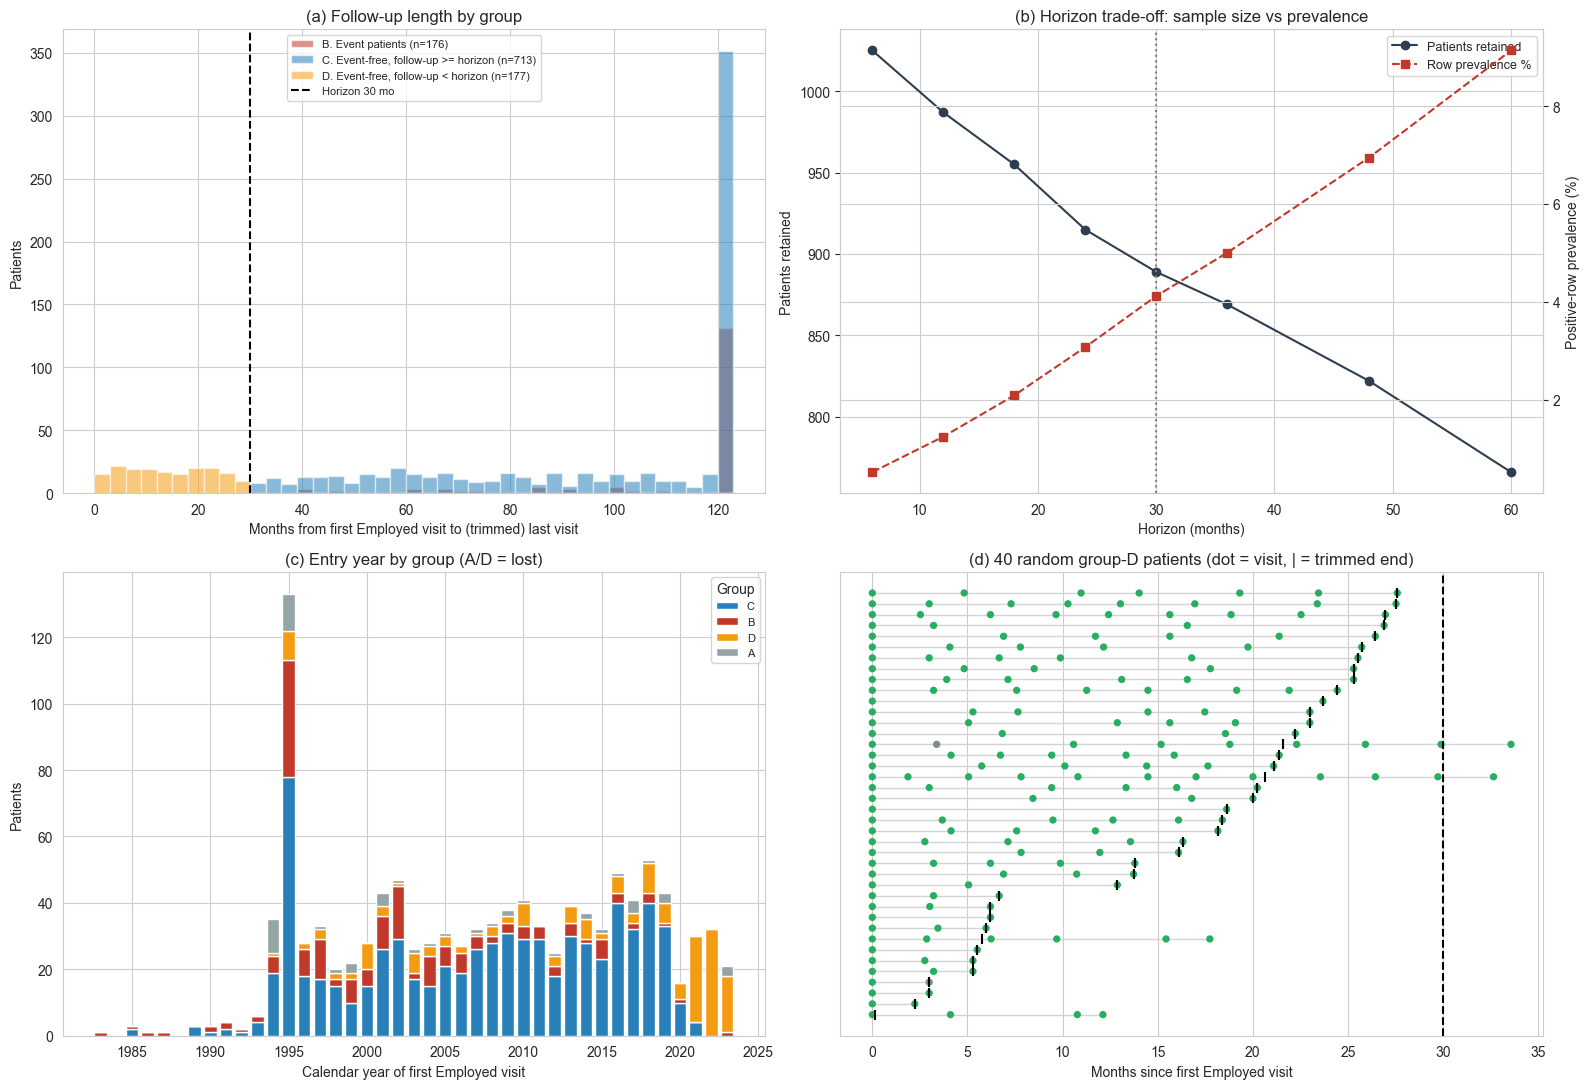

In [3]:
"""
Follow-up diagnostics for the landmark cohort.  Run AFTER the landmark-builder cell (uses its
_load_raw, _plan_patient, FEATURE_COLS, DISPLAY_NAMES, ADMIN_EXIT_STATES, *_TRIM_DAYS, HORIZON_DAYS).

Answers: how long is follow-up for the patients lost at step 4, WHY is it short (late entry vs dropout vs
death/exit), how does it look visit-by-visit, how does the cohort change with the horizon, and does
dropping/keeping patients by follow-up length bias the cohort?
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GROUP_LABELS = {
    "A": "A. Only Employed visit is the last visit (lost, step 3)",
    "B": "B. Event patients (kept)",
    "C": "C. Event-free, follow-up >= horizon (kept)",
    "D": "D. Event-free, follow-up < horizon (LOST, step 4)",
}
MONTH = 365.25 / 12


def followup_diagnostics(path=RAW_PATH, horizon_days=HORIZON_DAYS, require_continuous_employment=True,
                         horizon_grid_months=(6, 12, 18, 24, 30, 36, 48, 60), ltfu_window_days=365,
                         n_swim=40, seed=240, plot=True):
    df, _ = _load_raw(path)
    data_cut = df["ASSDT"].max()
    frames = {pid: g.sort_values("ASSDT").reset_index(drop=True) for pid, g in df.groupby("PTNO")}
    H_m = horizon_days / MONTH

    # ------------------------------------------------------------------ one row per patient
    recs = []
    for pid, p in frames.items():
        emp = (p["cat"] == "Employed").values
        if not emp.any():
            continue
        plan = _plan_patient(p, horizon_days, require_continuous_employment)
        dates = p["ASSDT"]
        first = int(np.argmax(emp)); idx = dates.iloc[first]
        status, end_state = plan["status"], plan["end_state"]
        trim = DEATH_TRIM_DAYS if status == "D" else ADMIN_TRIM_DAYS if end_state in ADMIN_EXIT_STATES else 0
        last_visit = dates.max()
        db_after = ((p["cat"] == "Disability Benefit") & (dates > idx)).values
        trans = dates[db_after].min() if db_after.any() else pd.NaT
        has_event = bool(pd.notna(trans))
        post = dates[dates >= idx]
        gaps = post.diff().dt.days.dropna()

        if plan["exit"] == "no_forward_visit":
            grp = "A"
        elif plan["exit"] == "no_resolvable_label":
            grp = "D"
        else:
            grp = "B" if has_event else "C"

        reason = ""
        if grp == "D":
            if status == "D":
                reason = "Died (last 12 mo trimmed)"
            elif end_state in ADMIN_EXIT_STATES:
                reason = "Administrative exit (unemployed/retired/inactive)"
            elif (data_cut - last_visit).days <= ltfu_window_days:
                reason = "Still active at data cut (late entry / short observation)"
            else:
                reason = "Stopped attending > 1 yr before data cut (probable LTFU)"

        lcdt = p["LCDT"].max() if "LCDT" in p else pd.NaT
        rec = {"pid": pid, "group": grp, "reason": reason, "has_event": has_event,
               "index_date": idx, "index_year": idx.year, "last_visit": last_visit,
               "fu_raw_m": (last_visit - idx).days / MONTH,                     # index -> last visit
               "fu_trim_m": ((last_visit - pd.Timedelta(days=trim)) - idx).days / MONTH,  # what the builder uses
               "time_to_event_m": (trans - idx).days / MONTH if has_event else np.nan,
               "n_visits": len(post), "n_employed_run": plan["n_run"],
               "median_gap_d": gaps.median() if len(gaps) else np.nan,
               "max_gap_d": gaps.max() if len(gaps) else np.nan,
               "days_last_visit_to_cut": (data_cut - last_visit).days,
               "lcdt_minus_last_visit_d": (lcdt - last_visit).days if pd.notna(lcdt) else np.nan,
               "status": status, "end_state": end_state}
        rec.update({f"base_{c}": p[c].iloc[first] for c in FEATURE_COLS})
        rec["_dates"] = list(zip(post.values, p.loc[dates >= idx, "cat"].values))
        recs.append(rec)
    d = pd.DataFrame(recs)
    d["T_m"] = np.where(d["has_event"], d["time_to_event_m"], d["fu_trim_m"]).clip(min=0.1 / MONTH)
    n_all = len(d)
    W = 100

    # ------------------------------------------------------------------ 1. follow-up length by group
    print("=" * W)
    print(f"1. FOLLOW-UP LENGTH  (months from first Employed visit; horizon = {H_m:.1f} mo; data cut = {data_cut.date()})")
    print("-" * W)
    print(f"{'GROUP':<58}{'N':>5}{'MEDIAN':>8}{'IQR':>16}{'MIN':>7}{'MAX':>7}")
    for g, lab in GROUP_LABELS.items():
        x = d.loc[d.group == g, "fu_trim_m"]
        if len(x):
            print(f"{lab:<58}{len(x):>5}{x.median():>8.1f}{f'{x.quantile(.25):.1f} - {x.quantile(.75):.1f}':>16}"
                  f"{x.min():>7.1f}{x.max():>7.1f}")
    D = d[d.group == "D"]
    if len(D):
        print(f"\nGroup D follow-up in bands (how far short of the {H_m:.0f}-month horizon?):")
        edges = [-np.inf, 0, 6, 12, 18, H_m - 3, H_m]
        labels = ["<= 0 (trim erased it)", "0-6 mo", "6-12 mo", "12-18 mo", f"18-{H_m - 3:.0f} mo", f"{H_m - 3:.0f}-{H_m:.0f} mo (near miss)"]
        band = pd.cut(D["fu_trim_m"], bins=edges, labels=labels)
        t = band.value_counts().reindex(labels)
        for lab, n in t.items():
            print(f"  {lab:<28}{n:>5}  {n / len(D):>6.1%}  cumulative {t.loc[:lab].sum() / len(D):>6.1%}")
        print(f"  Shortfall to horizon: median {(H_m - D['fu_trim_m']).median():.1f} mo; "
              f"would be rescued by a shorter horizon of 18 mo: {int((D['fu_trim_m'] >= 18).sum())}, "
              f"12 mo: {int((D['fu_trim_m'] >= 12).sum())}")

        # ------------------------------------------------------------ 2. why is it short
        print("\n" + "=" * W)
        print("2. WHY IS FOLLOW-UP SHORT? (group D)")
        print("-" * W)
        r = D.groupby("reason").agg(N=("pid", "size"), median_fu_mo=("fu_trim_m", "median"),
                                    median_last_visit_to_cut_d=("days_last_visit_to_cut", "median"))
        r["%"] = r["N"] / len(D) * 100
        print(r.sort_values("N", ascending=False).to_string(float_format=lambda v: f"{v:.1f}"))
        lc = D["lcdt_minus_last_visit_d"].dropna()
        if len(lc):
            print(f"\nLCDT (last contact) minus last visit, group D: median {lc.median():.0f} d, "
                  f"{(lc > 180).mean():.1%} have contact > 6 mo after last visit "
                  f"(known status beyond the last visit that the builder ignores)")

    # ------------------------------------------------------------------ 3. visit pattern
    print("\n" + "=" * W)
    print("3. VISIT PATTERN (from first Employed visit)")
    print("-" * W)
    vp = d.groupby("group").agg(N=("pid", "size"), visits_med=("n_visits", "median"),
                                employed_run_med=("n_employed_run", "median"),
                                gap_med_d=("median_gap_d", "median"), max_gap_med_d=("max_gap_d", "median"),
                                last_visit_to_cut_med_d=("days_last_visit_to_cut", "median"))
    print(vp.to_string(float_format=lambda v: f"{v:.1f}"))

    print("\nBy calendar year of first Employed visit (are recent entrants the short ones?):")
    ct = pd.crosstab(d["index_year"], d["group"]).reindex(columns=list("ABCD"), fill_value=0)
    ct["% lost (A+D)"] = (ct["A"] + ct["D"]) / ct.sum(axis=1) * 100
    print(ct.to_string(float_format=lambda v: f"{v:.0f}"))

    # ------------------------------------------------------------------ 4. horizon sensitivity (exact, via the builder's own rules)
    print("\n" + "=" * W)
    print("4. HORIZON SENSITIVITY  (same eligibility rules re-run at each horizon)")
    print("-" * W)
    rows = []
    for m in horizon_grid_months:
        H = round(m * MONTH)
        pats = pos_pats = n_rows = pos_rows = 0
        for p in frames.values():
            pl = _plan_patient(p, H, require_continuous_employment)
            if pl["kept"]:
                pats += 1; n_rows += len(pl["kept"]); k = sum(l for _, l, _ in pl["kept"])
                pos_rows += k; pos_pats += k > 0
        rows.append({"Horizon (mo)": m, "Patients": pats, "% of index pts": 100 * pats / n_all,
                     "Landmark rows": n_rows, "Positive rows": pos_rows,
                     "Row prevalence %": 100 * pos_rows / max(n_rows, 1), "Patients w/ >=1 event": pos_pats})
    sens = pd.DataFrame(rows)
    print(sens.to_string(index=False, float_format=lambda v: f"{v:.1f}"))

    # ------------------------------------------------------------------ 5. selection-bias checks
    print("\n" + "=" * W)
    print("5. DOES KEEPING/DROPPING BY FOLLOW-UP BIAS THE COHORT?")
    print("-" * W)
    e = d[d.group != "A"]
    kept = e[e.group.isin(["B", "C"])]
    H_days_m = H_m
    within = lambda x: (x["has_event"] & (x["time_to_event_m"] <= H_days_m))
    print(f"Event within {H_m:.0f} mo of index visit:")
    print(f"  crude, ALL index patients (treats censored as event-free)   : {within(e).mean():.1%}  (n={len(e)})")
    print(f"  crude, KEPT patients only (B+C)                             : {within(kept).mean():.1%}  (n={len(kept)})")
    try:
        from lifelines import KaplanMeierFitter
        km = KaplanMeierFitter().fit(e["T_m"], e["has_event"])
        km_r = KaplanMeierFitter().fit(e["T_m"], ~e["has_event"])
        print(f"  Kaplan-Meier cumulative incidence (censoring-aware)         : {1 - km.predict(H_days_m):.1%}")
        print(f"Median potential follow-up (reverse Kaplan-Meier): {km_r.median_survival_time_:.1f} mo")
    except Exception as ex:
        print("  (lifelines unavailable for KM:", ex, ")")
    print("  -> if 'KEPT' is well above the KM figure, the rule 'events kept at any follow-up, event-free need the "
          "full horizon' is inflating prevalence.")

    if len(D):
        print(f"\nBaseline (index-visit) characteristics, kept (B+C) vs lost-at-step-4 (D) -- standardised mean difference:")
        out = []
        for c in FEATURE_COLS:
            a, b = kept[f"base_{c}"].astype(float), D[f"base_{c}"].astype(float)
            sd = np.sqrt((a.var() + b.var()) / 2)
            out.append({"Feature": DISPLAY_NAMES.get(c, c), "Kept mean": a.mean(), "Lost mean": b.mean(),
                        "SMD": (a.mean() - b.mean()) / sd if sd > 0 else np.nan})
        smd = pd.DataFrame(out).sort_values("SMD", key=np.abs, ascending=False)
        smd["Flag"] = np.where(smd["SMD"].abs() > 0.1, "<-- imbalance (>0.1)", "")
        print(smd.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    print("=" * W)

    # ------------------------------------------------------------------ plots
    if plot:
        fig, ax = plt.subplots(2, 2, figsize=(16, 11))
        a = ax[0, 0]
        bins = np.arange(0, min(d["fu_trim_m"].max(), 120) + 6, 3)
        for g, col in [("B", "#c0392b"), ("C", "#2980b9"), ("D", "#f39c12")]:
            x = d.loc[d.group == g, "fu_trim_m"].clip(upper=bins[-1] - 0.01)
            a.hist(x, bins=bins, alpha=0.55, color=col, label=GROUP_LABELS[g].split(" (")[0] + f" (n={len(x)})")
        a.axvline(H_m, color="black", ls="--", label=f"Horizon {H_m:.0f} mo")
        a.set_xlabel("Months from first Employed visit to (trimmed) last visit"); a.set_ylabel("Patients")
        a.set_title("(a) Follow-up length by group"); a.legend(fontsize=8)

        a = ax[0, 1]
        a.plot(sens["Horizon (mo)"], sens["Patients"], "o-", color="#2c3e50", label="Patients retained")
        a.set_xlabel("Horizon (months)"); a.set_ylabel("Patients retained")
        a2 = a.twinx()
        a2.plot(sens["Horizon (mo)"], sens["Row prevalence %"], "s--", color="#c0392b", label="Row prevalence %")
        a2.set_ylabel("Positive-row prevalence (%)")
        a.axvline(H_m, color="gray", ls=":"); a.set_title("(b) Horizon trade-off: sample size vs prevalence")
        h1, l1 = a.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels()
        a.legend(h1 + h2, l1 + l2, loc="best", fontsize=9)

        a = ax[1, 0]
        yr = pd.crosstab(d["index_year"], d["group"]).reindex(columns=list("ABCD"), fill_value=0)
        bottom = np.zeros(len(yr))
        for g, col in [("C", "#2980b9"), ("B", "#c0392b"), ("D", "#f39c12"), ("A", "#95a5a6")]:
            a.bar(yr.index, yr[g], bottom=bottom, color=col, label=g); bottom += yr[g].values
        a.set_xlabel("Calendar year of first Employed visit"); a.set_ylabel("Patients")
        a.set_title("(c) Entry year by group (A/D = lost)"); a.legend(title="Group", fontsize=8)

        a = ax[1, 1]
        sw = D.sample(min(n_swim, len(D)), random_state=seed).sort_values("fu_trim_m") if len(D) else D
        colmap = {"Employed": "#27ae60", "Disability Benefit": "#c0392b"}
        for k, (_, r) in enumerate(sw.iterrows()):
            xs = [(np.datetime64(dt) - np.datetime64(r["index_date"])).astype("timedelta64[D]").astype(int) / MONTH
                  for dt, _ in r["_dates"]]
            a.plot([0, max(xs)], [k, k], color="lightgray", lw=1, zorder=1)
            a.scatter(xs, [k] * len(xs), c=[colmap.get(c, "#7f8c8d") for _, c in r["_dates"]], s=18, zorder=2)
            a.scatter([r["fu_trim_m"]], [k], marker="|", color="black", s=60, zorder=3)
        a.axvline(H_m, color="black", ls="--"); a.set_yticks([])
        a.set_xlabel("Months since first Employed visit"); a.set_title(f"(d) {len(sw)} random group-D patients (dot = visit, | = trimmed end)")
        plt.tight_layout(); plt.show(); plt.close()
    return d, sens

fu_df, horizon_table = followup_diagnostics()

In [4]:
"""
Table 1 — Baseline characteristics by outcome group.

Groups (mutually exclusive, patient-level):
  - Became Disabled   : patient had a Disability Benefit transition (event==1)
  - Deceased          : event-free, STATUS == 'D'
  - Other Exits       : event-free, end_state in ADMIN_EXIT_STATES
  - Remained Employed : event-free, none of the above
Plus an 'Overall' column across all patients in the modeling cohort (i.e.
patients who contributed at least one row to `land`).

Sections:
  1. Sociodemographics       -- sex, race, ethnicity, education, age, disease duration
  2. Follow-up               -- number of visits, total follow-up, mean gap between visits
  3. Disease activity/damage -- SLEDAI-2K, SDI, at baseline and across follow-up
  4. Treatment                -- ever-treated flags + average dose while treated,
                                  computed across each patient's FULL visit history
                                  (not a single row, so no more "one row per dose").

Continuous -> mean (SD) | median [IQR], compared with Kruskal-Wallis.
Categorical -> n (%), compared with chi-square.
"""
import numpy as np
import pandas as pd
from scipy import stats


def _patient_outcome_group(land_sub):
    r = land_sub.iloc[0]
    if r["event"] == 1:
        return "Became Disabled"
    if r["status"] == "D":
        return "Deceased"
    if r["end_state"] in ADMIN_EXIT_STATES:
        return "Other Exits"
    return "Remained Employed"


def _first_nonnull(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan


def build_table1_baseline(land, raw_path=RAW_PATH):
    """One row per patient (restricted to the modeling cohort in `land`):
    demographics, follow-up structure, disease activity/damage, and
    treatment history, all aggregated across that patient's FULL visit
    record -- not read off a single row."""
    df_raw, _ = _load_raw(raw_path)
    df_raw = df_raw.sort_values(["PTNO", "ASSDT"])

    outcome = (land.groupby("pid", group_keys=False)
                    .apply(_patient_outcome_group)
                    .rename("outcome_group"))
    cohort_ids = outcome.index

    df_c = df_raw[df_raw["PTNO"].isin(cohort_ids)]
    idx_rows = df_c.groupby("PTNO", as_index=False).first().set_index("PTNO")
    last_rows = df_c.groupby("PTNO", as_index=False).last().set_index("PTNO")
    g = df_c.groupby("PTNO")

    agg = pd.DataFrame(index=cohort_ids)

    # ---- 1. Sociodemographics (patient-constant; may not be on row 1, so
    #         take the first non-null value across ALL of that patient's visits) ----
    agg["sex"] = g["SEX"].apply(_first_nonnull)
    agg["race"] = g["RACE_LABEL"].apply(_first_nonnull)
    agg["ethnicity"] = g["DS_ETHNICITY"].apply(_first_nonnull)
    agg["education"] = g["DS_MAX_EDU"].apply(_first_nonnull)
    agg["age_index"] = idx_rows["age_at_record"]
    agg["disease_duration_yrs"] = idx_rows["disease_duration_yrs"]

    # ---- 2. Follow-up structure (across the FULL raw visit history) ----
    agg["n_visits"] = g.size()
    agg["followup_years"] = (last_rows["ASSDT"] - idx_rows["ASSDT"]).dt.days / 365.25
    agg["mean_gap_days"] = g["DAYS_SINCE_LAST_VISIT"].mean()

    # ---- 3. Disease activity & damage ----
    agg["sledai_baseline"] = idx_rows["SLEDAI2_I"]
    agg["sledai_mean"] = g["SLEDAI2_I"].mean()
    agg["sdi_baseline"] = idx_rows["score_n"]
    agg["sdi_last"] = last_rows["score_n"]

    # ---- 4. Treatment (ever-treated flags + average dose while treated,
    #         computed across the full record, not a single row) ----
    agg["ever_steroid"] = g["HAS_STEROID_REC"].max()
    agg["steroid_dose_mean"] = g["STERAVER"].mean()
    agg["ever_steroid_pulse"] = g["STPDOSE"].apply(lambda s: int((s.fillna(0) > 0).any()))
    agg["ever_antimalarial"] = g["HAS_ANTIMALARIAL_REC"].max()
    agg["ever_immunosuppressive"] = g["HAS_IMMUNOSUPPRESSIVE_REC"].max()
    agg["ever_cyclophosphamide"] = g["IS_CYCLOPHOSPHAMIDE_DOSE"].apply(lambda s: int((s.fillna(0) > 0).any()))
    agg["ever_mycophenolate"] = g["IS_MYCOPHENOLATE_DOSE"].apply(lambda s: int((s.fillna(0) > 0).any()))
    agg["ever_methotrexate"] = g["IS_METHOTREXATE_DOSE"].apply(lambda s: int((s.fillna(0) > 0).any()))
    agg["ever_biologic"] = g["HAS_BIOLOGIC_REC"].max()
    agg["ever_rituximab"] = g["BIOG_RIT"].apply(lambda s: int(s.fillna(0).max() > 0))
    agg["ever_belimumab"] = g["BIOG_BEL"].apply(lambda s: int(s.fillna(0).max() > 0))

    agg = agg.join(outcome, how="inner")
    return agg


def _fmt_continuous(s):
    s = s.dropna().astype(float)
    if len(s) == 0:
        return "n=0"
    return f"{s.mean():.1f} ({s.std():.1f})  |  {s.median():.1f} [{s.quantile(.25):.1f}\u2013{s.quantile(.75):.1f}]"


def _fmt_categorical(s, level):
    s = s.dropna()
    n = (s == level).sum()
    denom = len(s)
    pct = 100 * n / denom if denom else 0.0
    return f"{n} ({pct:.1f}%)"


def _section_row(groups, title):
    return {"Variable": f"**{title}**", "Overall": "", **{g: "" for g in groups}, "p": ""}


def _continuous_row(base, col, label, groups):
    arrs = [base.loc[base["outcome_group"] == g, col].dropna().astype(float) for g in groups]
    arrs = [a for a in arrs if len(a) > 0]
    try:
        _, p = stats.kruskal(*arrs) if len(arrs) > 1 else (np.nan, np.nan)
        p_str = f"{p:.3f}" if pd.notna(p) else "n/a"
    except ValueError:
        p_str = "n/a"
    row = {"Variable": f"{label}, mean (SD) | median [IQR]", "Overall": _fmt_continuous(base[col]), "p": p_str}
    for g in groups:
        row[g] = _fmt_continuous(base.loc[base["outcome_group"] == g, col])
    return row


def _categorical_rows(base, col, label, groups, level_labels=None):
    rows = [{"Variable": f"**{label}**, n (%)", "Overall": "", **{g: "" for g in groups}, "p": ""}]
    ct = pd.crosstab(base[col], base["outcome_group"])
    try:
        _, p, _, _ = stats.chi2_contingency(ct)
        p_str = f"{p:.3f}"
    except ValueError:
        p_str = "n/a"
    levels = sorted(base[col].dropna().unique().tolist(), key=str)
    for i, lvl in enumerate(levels):
        lvl_label = (level_labels or {}).get(lvl, lvl)
        row = {"Variable": f"    {lvl_label}", "Overall": _fmt_categorical(base[col], lvl), "p": p_str if i == 0 else ""}
        for g in groups:
            row[g] = _fmt_categorical(base.loc[base["outcome_group"] == g, col], lvl)
        rows.append(row)
    return rows


def _binary_row(base, col, label, groups):
    """For 0/1 'ever-treated' flags: a single n (%) row for the '1' level."""
    ct = pd.crosstab(base[col], base["outcome_group"])
    try:
        _, p, _, _ = stats.chi2_contingency(ct)
        p_str = f"{p:.3f}"
    except ValueError:
        p_str = "n/a"
    row = {"Variable": f"{label}, n (%)", "Overall": _fmt_categorical(base[col], 1), "p": p_str}
    for g in groups:
        row[g] = _fmt_categorical(base.loc[base["outcome_group"] == g, col], 1)
    return row


def make_table1(base, group_order=("Remained Employed", "Became Disabled", "Deceased", "Other Exits")):
    groups = [g for g in group_order if g in base["outcome_group"].unique()]
    rows = []

    # ---- Sociodemographics ----
    rows.append(_section_row(groups, "Sociodemographics"))
    rows.append(_continuous_row(base, "age_index", "Age at baseline (years)", groups))
    rows += _categorical_rows(base, "sex", "Sex", groups)
    rows += _categorical_rows(base, "race", "Race", groups)
    rows += _categorical_rows(base, "ethnicity", "Ethnicity", groups)
    rows += _categorical_rows(base, "education", "Education (DS_MAX_EDU)", groups,
                               level_labels={0: "Lower", 1: "Higher"})  # relabel once you confirm coding
    rows.append(_continuous_row(base, "disease_duration_yrs", "Disease duration at baseline (years)", groups))

    # ---- Follow-up ----
    rows.append(_section_row(groups, "Follow-up"))
    rows.append(_continuous_row(base, "n_visits", "Number of visits", groups))
    rows.append(_continuous_row(base, "followup_years", "Total follow-up (years)", groups))
    rows.append(_continuous_row(base, "mean_gap_days", "Mean time between visits (days)", groups))

    # ---- Disease activity & damage ----
    rows.append(_section_row(groups, "Disease Activity & Damage"))
    rows.append(_continuous_row(base, "sledai_baseline", "SLEDAI-2K at baseline", groups))
    rows.append(_continuous_row(base, "sledai_mean", "SLEDAI-2K, mean across follow-up", groups))
    rows.append(_continuous_row(base, "sdi_baseline", "SDI damage score at baseline", groups))
    rows.append(_continuous_row(base, "sdi_last", "SDI damage score at last visit", groups))

    # ---- Treatment ----
    rows.append(_section_row(groups, "Treatment (ever during follow-up)"))
    rows.append(_binary_row(base, "ever_steroid", "Ever on steroids", groups))
    rows.append(_continuous_row(base, "steroid_dose_mean", "Average daily steroid dose, mg (among those with a value)", groups))
    rows.append(_binary_row(base, "ever_steroid_pulse", "Ever received steroid pulse", groups))
    rows.append(_binary_row(base, "ever_antimalarial", "Ever on antimalarial", groups))
    rows.append(_binary_row(base, "ever_immunosuppressive", "Ever on immunosuppressive therapy", groups))
    rows.append(_binary_row(base, "ever_cyclophosphamide", "    Ever cyclophosphamide", groups))
    rows.append(_binary_row(base, "ever_mycophenolate", "    Ever mycophenolate", groups))
    rows.append(_binary_row(base, "ever_methotrexate", "    Ever methotrexate", groups))
    rows.append(_binary_row(base, "ever_biologic", "Ever on biologic therapy", groups))
    rows.append(_binary_row(base, "ever_rituximab", "    Ever rituximab", groups))
    rows.append(_binary_row(base, "ever_belimumab", "    Ever belimumab", groups))

    n_row = {"Variable": "N", "Overall": str(len(base)), "p": ""}
    for g in groups:
        n_row[g] = str((base["outcome_group"] == g).sum())
    rows = [n_row] + rows

    return pd.DataFrame(rows)[["Variable", "Overall"] + groups + ["p"]]


table1_base = build_table1_baseline(land)
table1 = make_table1(table1_base)

pd.set_option("display.max_rows", None)
display(table1)
table1.to_csv("table1_baseline_characteristics.csv", index=False)

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_7938/2132404623.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_patient_outcome_group)


,Variable,Overall,Remained Employed,Became Disabled,Deceased,p
0,N,889,678,176,35,
1,**Sociodemographics**,,,,,
2,"Age at baseline (years), mean (SD) | median [IQR]",35.3 (11.4) | 33.9 [26.0–43.4],34.3 (11.1) | 33.0 [25.8–41.7],37.7 (11.9) | 37.8 [27.0–46.5],42.6 (11.2) | 42.4 [34.8–49.5],0.000
3,"**Sex**, n (%)",,,,,
4,F,796 (89.5%),607 (89.5%),160 (90.9%),29 (82.9%),0.364
5,M,93 (10.5%),71 (10.5%),16 (9.1%),6 (17.1%),
6,"**Race**, n (%)",,,,,
7,Black,127 (14.5%),86 (13.0%),35 (19.9%),6 (17.1%),0.226
8,Caucasian,538 (61.5%),401 (60.4%),115 (65.3%),22 (62.9%),
9,Chinese,91 (10.4%),76 (11.4%),12 (6.8%),3 (8.6%),


In [5]:
"""Sequential (GRU / LSTM) landmark model for 30-month work-disability risk.
Same architecture as before (MICE imputer + 2-layer recurrent classifier
with sigmoid head, trained on balanced 1:1 minibatches). Tuned and
scored with repeated cross-validation (see run_analysis below and the
"Repeated Cross-Validation Infrastructure" cells above); the post-hoc
Platt/isotonic calibrator (fit_risk_calibrator / apply_risk_calibrator, see
the shared-utilities cell) is learned inside each CV fold, and again on the
final full-data refit used only for interpretability."""
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from lifelines.utils import concordance_index


class RecurrentClassifier(nn.Module):
    def __init__(self, input_dim, cell="gru"):
        super().__init__()
        rnn = nn.GRU if cell == "gru" else nn.LSTM
        self.rnn1 = rnn(input_dim, 64, batch_first=True)
        self.drop1 = nn.Dropout(0.3)
        self.bn = nn.BatchNorm1d(64)
        self.rnn2 = rnn(64, 32, batch_first=True)
        self.drop2 = nn.Dropout(0.2)
        self.head = nn.Linear(32, 1)

    def forward(self, x):
        h, _ = self.rnn1(x)
        h = self.drop1(h)
        b, t, f = h.shape
        h = self.bn(h.reshape(b * t, f)).reshape(b, t, f)
        h, _ = self.rnn2(h)
        h = self.drop2(h)
        out = torch.sigmoid(self.head(h))
        return out  # (batch, seq, 1)


class SequentialSurvivalRNN:
    """cell='gru' or 'lstm'"""

    def __init__(self, cell="gru", sequence_length=12, horizon_days=913, seed=240):
        self.cell = cell
        self.sequence_length = sequence_length
        self.horizon_days = horizon_days
        self.feature_cols = FEATURE_COLS
        self.scaler = StandardScaler()
        self.imputer = None
        self.model = None
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.calibrator = None        
        self.seed = seed
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

    def _train_imputer(self, X_with_nan, max_iter=10, n_imputations=1):
        """Fits MICE on the feature rows, flattened across the sequence-time
        dimension -- each patient-visit becomes one row, exactly like the
        tabular models' MICE imputer, so the chained-equations regressions
        see every observed visit rather than only one row per patient.
        Rows that are entirely NaN (padding for patients with fewer than
        `sequence_length` visits) are excluded from fitting."""
        name = self.cell.upper()
        print(f"Fitting MICE imputer for {name} input sequences...")
        flat = X_with_nan.reshape(-1, X_with_nan.shape[-1])
        not_all_nan = ~np.isnan(flat).all(axis=1)
        self.imputer = train_mice(flat[not_all_nan], max_iter=max_iter,
                                   n_imputations=n_imputations, seed=self.seed)

    def _impute(self, X_raw):
        seq_shape = X_raw.shape
        flat = X_raw.reshape(-1, seq_shape[-1])
        filled = impute_with_mice(self.imputer, flat)
        return filled.reshape(seq_shape)

    def prepare_data(self, land, X_seq):
        self.input_dim = len(self.feature_cols)
        flat = land[self.feature_cols].values.astype(float)
        self.scaler.fit(np.nan_to_num(flat, nan=np.nanmedian(flat, axis=0)))

        seq_shape = X_seq.shape
        flat_seq = X_seq.reshape(-1, seq_shape[-1])
        scaled_flat = np.full_like(flat_seq, np.nan)
        not_nan = ~np.isnan(flat_seq).all(axis=1)
        scaled_flat[not_nan] = self.scaler.transform(
            np.nan_to_num(flat_seq[not_nan], nan=np.nanmedian(flat, axis=0)))
        scaled_flat[np.isnan(flat_seq)] = np.nan
        X_scaled = scaled_flat.reshape(seq_shape)

        if self.imputer is None:
            self._train_imputer(X_scaled)
        X_final = self._impute(X_scaled)

        y = land["label"].values.astype(np.float32)
        weight = land["weight"].values.astype(np.float32)
        return X_final.astype(np.float32), y, weight

    def _build_classifier(self):
        return RecurrentClassifier(self.input_dim, cell=self.cell)

    def _balanced_batch(self, X, y, weight, batch_size=32):
        pos_idx = np.where(y == 1)[0]
        neg_idx = np.where(y == 0)[0]
        pos_w = weight[pos_idx] / weight[pos_idx].sum()
        neg_w = weight[neg_idx] / weight[neg_idx].sum()
        half = batch_size // 2
        while True:
            bp = np.random.choice(pos_idx, half, p=pos_w)
            bn = np.random.choice(neg_idx, half, p=neg_w)
            idx = np.concatenate([bp, bn])
            np.random.shuffle(idx)
            yield X[idx], y[idx]

    def run_analysis(self, land, X_seq, epochs=25, steps_per_epoch=None):
        model_key = self.cell.upper()  # "GRU" or "LSTM"
        name = f"{model_key} (Sequential)"

        # 1. Repeated, patient-grouped, stratified K-fold CV: the MICE imputer,
        #    scaler, classifier, Platt calibrator, cost weights and cost-optimal
        #    threshold are all learned inside each training fold only, and scored
        #    on that fold's held-out rows -- never train == test.
        global cv_state
        cv_state = run_repeated_cv(models=[model_key])
        report_repeated_cv(model_key)
        y_true, visit_risks, y_pred, best_t, c_val = cv_pooled_predictions(model_key, cv_state)

        report_comprehensive_metrics(f"{name}, repeated CV", y_true, y_pred, visit_risks, c_val)
        meta = land.copy()
        meta["y_pred"] = y_pred
        print_operational_metrics(name, meta, label_col="label")
        print_cost_metrics(name, y_true, y_pred, best_t)
        color = "#d95f02" if self.cell == "gru" else "#2c7da0"
        plot_decision_curve(name, y_true, visit_risks, color=color)
        plot_risk_distribution_and_calibration(name, visit_risks, y_true, best_t)
        plot_performance_grid(name, y_true, visit_risks, best_t)
        plot_cost_decision_and_confusion(name, y_true, visit_risks, best_t)

        # 1b. Patient-level results: accumulate each patient's full follow-up.
        #     A patient who eventually goes into work disability is a true
        #     positive if ANY landmark in their follow-up crossed the alert
        #     threshold; a patient who never goes into work disability is a
        #     true negative only if NO landmark in their follow-up did.
        #     Patient-level risk is the peak (max) risk over that patient's
        #     follow-up, so thresholding it at the same best_t reproduces
        #     "alerted at any point in follow-up" exactly.
        name_p = f"{name} (patient-level)"
        patient_df = build_patient_level_frame(land, visit_risks, y_pred)
        y_p, risks_p, y_pred_p = patient_df["label"].values, patient_df["risk"].values, patient_df["y_pred"].values
        c_idx_p = concordance_index(patient_df["duration"], -risks_p, patient_df["event"])

        report_comprehensive_metrics(name_p, y_p, y_pred_p, risks_p, c_idx_p)
        print_patient_operational_metrics(model_key, patient_df)
        print_cost_metrics(name_p, y_p, y_pred_p, best_t)
        plot_decision_curve(name_p, y_p, risks_p, color=color)
        plot_risk_distribution_and_calibration(name_p, risks_p, y_p, best_t)
        plot_performance_grid(name_p, y_p, risks_p, best_t)
        plot_cost_decision_and_confusion(name_p, y_p, risks_p, best_t)

        # 2. Final refit on ALL landmark rows -- builds the deployed model object
        #    used only for the risk-sensitivity curves below, the SHAP dashboard
        #    and the cross-model calibration plot. None of the metrics/plots
        #    above come from this fit.
        X, y_full, weight = self.prepare_data(land, X_seq)
        self.model = self._build_classifier()
        opt = optim.Adam(self.model.parameters(), lr=1e-3)
        bce = nn.BCELoss()

        gen = self._balanced_batch(X, y_full, weight, 32)
        spe = steps_per_epoch or max(1, len(X) // 32)

        print(f"Training Survival {self.cell.upper()} (final refit on all data)...")
        self.model.train()
        for ep in range(epochs):
            for _ in range(spe):
                xb, yb = next(gen)
                xb_t = torch.FloatTensor(xb)
                yb_t = torch.FloatTensor(yb).view(-1, 1, 1).repeat(1, self.sequence_length, 1)
                opt.zero_grad()
                pred = self.model(xb_t)
                loss = bce(pred, yb_t)
                loss.backward()
                opt.step()

        self.model.eval()
        with torch.no_grad():
            raw_preds = self.model(torch.FloatTensor(X)).numpy()
        visit_risks_raw = raw_preds[:, -1, 0]
        self.calibrator = fit_risk_calibrator(visit_risks_raw, y_full, seed=240, model_name=model_key)
        calibrated = apply_risk_calibrator(self.calibrator, visit_risks_raw)
        self.final_scaler.fit(calibrated.reshape(-1, 1))   # fits final_scaler for _predict_risk_override

        sens_curves = compute_risk_sensitivity(
            self.feature_cols, land,
            lambda rows, j, v: self._predict_risk_override(X, rows, j, v))
        plot_risk_sensitivity(name, sens_curves, best_t)

        return {"model": self, "risks": visit_risks, "y": y_true, "y_pred": y_pred,
                "c_index": c_val, "best_t": best_t, "X": X, "sensitivity": sens_curves,
                "patient": patient_df, "patient_c_index": c_idx_p}

    def _predict_risk_override(self, X, rows, j, v):
        """Calibrated risk for landmark `rows` with feature j held at value v (original
        units) at every visit of the 12-visit input window."""
        Xm = X[rows].copy()
        Xm[:, :, j] = (v - self.scaler.mean_[j]) / self.scaler.scale_[j]
        self.model.eval()
        with torch.no_grad():
            raw = self.model(torch.FloatTensor(Xm)).numpy()[:, -1, 0]
        calibrated = apply_risk_calibrator(self.calibrator, raw)   # or `raw` in the GRU/LSTM cell
        return np.clip(self.final_scaler.transform(calibrated.reshape(-1, 1)).flatten(), 1e-5, 1 - 1e-5)


## Repeated Cross-Validation Infrastructure

Every model below (LogReg, RSF, CoxPH, GRU, LSTM) is tuned and scored with
**repeated, patient-grouped, stratified K-fold cross-validation** rather than
being fit on all landmark rows and scored on those same rows (train == test,
which only measures apparent / in-sample performance). This cell block
defines the shared machinery that each Model N/5 section calls into.

**Design**

- **Grouped by patient.** A patient contributes many landmark rows that share
  a label history and follow-up, so a row-level split would leak.
  `StratifiedGroupKFold` on `pid` keeps every patient wholly inside either the
  training or the test fold.
- **Stratified by patient outcome.** Folds are balanced on `event` (a
  patient-level flag), so every test fold contains disability events.
- **Repeated.** The K-fold split is redrawn `CV_N_REPEATS` times with
  different shuffles (`CV_SEED + repeat`). Every model sees *identical*
  folds, so differences between models are paired.
- **Nothing is fitted on test data.** Inside each training fold: the imputer
  (MICE), feature scaler, the model, the Platt calibrator, the min-max risk
  rescale, **the cost weights**, and **the cost-optimal threshold** are all
  learned without the test fold. By default (`CV_CAL_FRAC = 0.25`) a
  patient-level slice of the training fold is held back from model fitting
  and used only to learn calibration + threshold, so they are not tuned on
  rows the model already memorised.
- **Same recipes.** Hyper-parameters, class balancing, patient weights
  (`1 / landmarks per patient`) and the 12-visit sequence window are those
  used in Models 1-5. The cost weights (`COST_FN : COST_FP`) are *not* fixed
  -- each fold derives its own from that fold's own training-label class
  balance (see `compute_cost_weights`), so the ratio can vary fold-to-fold
  with the data it is fit on, rather than being a single assumed constant.
  One deliberate simplification: LogReg, RSF and CoxPH share **one** MICE
  imputer per fold (`CV_MICE_MAX_ITER` chained-equation iterations) instead
  of each fitting its own, which saves time and puts them on identical
  imputed data.
- **Checkpointed and shared.** `run_repeated_cv(models=[...])` accumulates
  fold results into one checkpoint (`CV_STATE_PATH`), keyed by
  `(model, repeat, fold)`. Each Model N/5 section below calls it for just its
  own model, so results build up across the notebook run and any interrupted
  run resumes where it stopped.
- **Reported risk per landmark row.** For plots and row-level metrics, each
  landmark's risk is the *average of its out-of-fold predictions across every
  completed repeat* -- still strictly out-of-sample for that row (it was held
  out of training, calibration and thresholding in every fold that produced
  it), just lower-variance than any single repeat.

**Reading the output.** Fold-level metrics are summarised as mean (SD) over
all `K x R` test folds. The SD describes split-to-split variability, *not* a
standard error -- folds share training data, so do not divide by sqrt(n) or
run naive t-tests on them. Metrics are unweighted at the landmark-row level.
Calibration slope/intercept are computed on the calibrated probability
(logistic recalibration; intercept with slope fixed at 1).

**Runtime.** Total cost per model is approximately `K x R` fits -- the two
recurrent models dominate. Results are checkpointed after every fold and the
run resumes where it stopped, so re-running a section after an interruption
does not repeat completed folds.

**Final refit (interpretability only).** After CV reporting, each Model N/5
section also refits once on *all* landmark rows. That refit is only ever used
to build the model object needed for risk-sensitivity curves, the SHAP
dashboard and the cross-model calibration plot -- none of the reported
performance numbers come from it.


In [6]:
"""
Repeated cross-validation, part 1/5 -- configuration, fold generator, post-processing and metrics.

Run AFTER the landmark builder (`land`, `X_seq`), the shared-utilities cell (cost model, MICE imputer) and the
sequential-model cell (SequentialSurvivalRNN). See the markdown cell above for the design.
"""
import os, io, time, pickle, contextlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix
from lifelines.utils import concordance_index

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
CV_N_SPLITS   = 5        # K folds per repeat
CV_N_REPEATS  = 5        # R repeats (each = a fresh, differently shuffled K-fold split)
CV_SEED       = 240      # repeat r uses random_state = CV_SEED + r
CV_CAL_FRAC   = 0.25     # share of each TRAINING fold (by patient) reserved for Platt calibration + cost-optimal
                         # threshold. 0 -> fit and calibrate on the same rows (the notebook's in-sample behaviour).
CV_MICE_MAX_ITER = 10    # MICE (IterativeImputer) chained-equation iterations, shared by LogReg / RSF / CoxPH within a fold
CV_MICE_M     = 1        # number of MICE chains averaged per fold (1 = single deterministic imputation)
CV_RNN_EPOCHS = 25       # classifier epochs for GRU / LSTM (same as Models 4-5)
CV_PLATT_C    = 1.0      # inverse L2 strength of the Platt calibrator (1.0 = sklearn default, as in fit_risk_calibrator)
CV_MODELS     = ["LogReg", "RSF", "CoxPH", "GRU", "LSTM"]
CV_STATE_PATH = "cv_state.pkl"   # checkpoint: fold metrics + out-of-fold predictions (delete to start over)

CV_COLORS = {"LogReg": "#2c7da0", "RSF": "#e67e22", "CoxPH": "#2ecc71", "GRU": "#d95f02", "LSTM": "#6b2d5c"}


# ---------------------------------------------------------------------------
# Folds: repeated, stratified, grouped by patient
# ---------------------------------------------------------------------------
def cv_make_folds(land, n_splits=None, n_repeats=None, seed=None):
    """[(repeat, fold, train_row_idx, test_row_idx), ...]. Rows of one patient never straddle train/test."""
    n_splits = CV_N_SPLITS if n_splits is None else n_splits
    n_repeats = CV_N_REPEATS if n_repeats is None else n_repeats
    seed = CV_SEED if seed is None else seed
    pid = land["pid"].values
    strat = land["event"].values.astype(int)          # patient-level flag (constant within a pid)
    dummy = np.zeros(len(land))
    folds = []
    for r in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed + r)
        for k, (tr, te) in enumerate(sgkf.split(dummy, strat, pid)):
            folds.append((r, k, tr, te))
    return folds


def cv_check_folds(land, folds):
    """Assert no patient leakage and show how balanced the test folds are."""
    pid = land["pid"].values
    y = land["label"].values.astype(int)
    ev = land["event"].values.astype(int)
    rows = []
    for r, k, tr, te in folds:
        assert not (set(pid[tr]) & set(pid[te])), f"patient in both train and test (repeat {r}, fold {k})"
        rows.append({"repeat": r, "fold": k, "test_patients": len(set(pid[te])), "test_rows": len(te),
                     "test_positive_rows": int(y[te].sum()),
                     "test_event_patients": int(pd.Series(ev[te]).groupby(pid[te]).max().sum())})
    d = pd.DataFrame(rows)
    print(f"{len(folds)} folds ({d['repeat'].nunique()} repeats x {d['fold'].nunique()}), no patient shared between "
          f"train and test in any fold.")
    print(d[["test_patients", "test_rows", "test_positive_rows", "test_event_patients"]]
          .agg(["min", "median", "max"]).T.to_string())
    if (d["test_positive_rows"] == 0).any():
        warnings.warn("Some test folds have no positive rows -- lower CV_N_SPLITS.")
    return d


def _cv_inner_split(land, outer_tr, seed):
    """Patient-level split of a training fold into (fit rows, calibration rows)."""
    if CV_CAL_FRAC <= 0:
        return outer_tr, outer_tr
    n_in = max(2, int(round(1.0 / CV_CAL_FRAC)))
    sub = land.iloc[outer_tr]
    sgkf = StratifiedGroupKFold(n_splits=n_in, shuffle=True, random_state=seed)
    fit_rel, cal_rel = next(sgkf.split(np.zeros(len(sub)), sub["event"].values.astype(int), sub["pid"].values))
    return outer_tr[fit_rel], outer_tr[cal_rel]


# ---------------------------------------------------------------------------
# Post-processing learned on the calibration rows: Platt -> prior-shift correction ->
# min-max -> cost-optimal threshold. Mirrors fit_risk_calibrator / apply_risk_calibrator
# in the shared-utilities cell (see the calibration write-up: rescale-to-probability,
# then a Saerens/King-Zeng prior-shift correction onto the target prevalence, then a
# final [0, 1] rescale -- that final rescale is what makes the reported risk span the
# whole 0-1 range, so it is re-applied once more at the pooled level in
# cv_pooled_predictions below).
# ---------------------------------------------------------------------------
def _cv_platt(raw, y):
    """Platt scaling of a raw model score onto a probability (identity if only one class is present)."""
    raw = np.asarray(raw, float).reshape(-1, 1)
    y = np.asarray(y).astype(int)
    if len(np.unique(y)) < 2:
        return lambda r: np.clip(np.asarray(r, float), 1e-5, 1 - 1e-5)
    lr = LogisticRegression(C=CV_PLATT_C, max_iter=1000).fit(raw, y)
    return lambda r: np.clip(lr.predict_proba(np.asarray(r, float).reshape(-1, 1))[:, 1], 1e-5, 1 - 1e-5)


def _cv_postprocess(raw_cal, y_cal, raw_te, target_prevalence=None, cost_fn=None, cost_fp=None):
    """(1) Platt-scale the raw score to a probability, fit on the calibration rows.
    (2) Prior-shift correct that probability from the calibration fold's own event rate
    (`train_prevalence`) onto `target_prevalence` (defaults to the full landmark sample's
    empirical event rate, `land["label"].mean()`, per the Saerens/King-Zeng identity in
    `_prior_correct`) -- a no-op only if the fold happens to match that rate exactly.
    (3) Rescale the corrected probability to [0, 1]. `cost_fn`/`cost_fp` (normally this
    fold's own training-label-derived cost weights, from `compute_cost_weights`) pick the
    cost-optimal threshold on the calibration rows; both default to the global COST_FN /
    COST_FP if not given. Returns (calibrated + prior-corrected test probability, [0, 1]-
    rescaled test risk, cost-optimal threshold), all learned only from the calibration rows
    (`raw_cal`, `y_cal`)."""
    y_cal = np.asarray(y_cal).astype(int)
    target_prevalence = float(land["label"].mean()) if target_prevalence is None else target_prevalence
    train_prevalence = float(y_cal.mean()) if len(y_cal) else float("nan")

    platt = _cv_platt(raw_cal, y_cal)
    p_cal, p_te = platt(raw_cal), platt(raw_te)
    if np.isfinite(train_prevalence) and 0 < train_prevalence < 1:
        p_cal = _prior_correct(p_cal, train_prevalence, target_prevalence)
        p_te = _prior_correct(p_te, train_prevalence, target_prevalence)
    p_cal = np.clip(p_cal, 1e-5, 1 - 1e-5)
    p_te = np.clip(p_te, 1e-5, 1 - 1e-5)

    mm = MinMaxScaler(feature_range=(0, 1)).fit(p_cal.reshape(-1, 1))
    to_risk = lambda p: np.clip(mm.transform(p.reshape(-1, 1)).ravel(), 1e-5, 1 - 1e-5)
    thr = find_cost_optimal_threshold(y_cal, to_risk(p_cal), cost_fn=cost_fn, cost_fp=cost_fp)
    return p_te, to_risk(p_te), thr


# ---------------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------------
def _cv_calibration(y, p):
    """(slope, intercept): slope = coefficient of logit(p) in a logistic recalibration model; intercept =
    calibration-in-the-large with the slope fixed at 1."""
    y = np.asarray(y).astype(int)
    if y.min() == y.max():
        return np.nan, np.nan
    p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
    lp = np.log(p / (1 - p))
    slope = LogisticRegression(C=1e6, max_iter=1000).fit(lp.reshape(-1, 1), y).coef_[0, 0]
    try:
        icpt = brentq(lambda a: np.mean(1.0 / (1.0 + np.exp(-(a + lp)))) - y.mean(), -20, 20)
    except ValueError:
        icpt = np.nan
    return float(slope), float(icpt)


def cv_metrics(y, p, y_pred, dur, ev, cost_fn=None, cost_fp=None):
    """Discrimination on the calibrated probability `p`, calibration on `p`, and classification / cost metrics
    at the decisions `y_pred` (made with the fold's own cost-optimal threshold, itself derived from `cost_fn` /
    `cost_fp` -- normally this fold's own training-label-derived cost weights, see `compute_cost_weights`;
    falls back to the global COST_FN / COST_FP if not given)."""
    cost_fn = COST_FN if cost_fn is None else cost_fn
    cost_fp = COST_FP if cost_fp is None else cost_fp
    y = np.asarray(y).astype(int)
    p = np.asarray(p, float)
    y_pred = np.asarray(y_pred).astype(int)
    n = len(y)
    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()
    div = lambda a, b: a / b if b > 0 else np.nan
    sens, spec = div(tp, tp + fn), div(tn, tn + fp)
    total = cost_fn * fn + cost_fp * fp
    best_default = min(cost_fp * (tn + fp), cost_fn * (tp + fn))     # alert-everyone vs alert-no-one
    both = 0 < y.sum() < n
    try:
        c_idx = concordance_index(dur, -p, ev)
    except ZeroDivisionError:
        c_idx = np.nan
    slope, icpt = _cv_calibration(y, p)
    return {
        "c_index": c_idx,
        "auroc": roc_auc_score(y, p) if both else np.nan,
        "auprc": average_precision_score(y, p) if both else np.nan,
        "brier": brier_score_loss(y, np.clip(p, 0, 1)),
        "cal_slope": slope, "cal_intercept": icpt,
        "sensitivity": sens, "specificity": spec,
        "ppv": div(tp, tp + fp), "npv": div(tn, tn + fn),
        "bal_acc": (sens + spec) / 2 if not (np.isnan(sens) or np.isnan(spec)) else np.nan,
        "alerts_per_100": 100.0 * (tp + fp) / n,
        "cost_per_100": 100.0 * total / n,
        "saving_vs_default": 1.0 - total / best_default if best_default > 0 else np.nan,
        "prevalence": float(y.mean()), "n_test": n, "n_events": int(y.sum()),
        "cost_fn": cost_fn, "cost_fp": cost_fp,
    }

In [7]:
"""
Repeated cross-validation, part 2/5 -- one fitter per model.

Each fitter trains on `fit_idx` rows only and returns a RAW risk score for every row in `pred_idx`
(calibration rows + test rows). Recipes mirror Models 1-5; everything data-dependent (imputer, scaler,
model) is learned from `fit_idx` alone. `ctx` is a per-fold cache so LogReg / RSF / CoxPH share one MICE
imputer.
"""
import torch
import torch.nn as nn
import torch.optim as optim


# ---------------------------------------------------------------------------
# Tabular models (LogReg, RSF, CoxPH): MICE imputation -> StandardScaler, fitted on the fit rows only
# ---------------------------------------------------------------------------
def _cv_tabular_features(fit_idx, pred_idx, ctx, seed):
    if "tab" in ctx:
        return ctx["tab"]
    raw = land[FEATURE_COLS].values.astype(float)
    tr, pr = raw[fit_idx], raw[pred_idx]
    mice = train_mice(tr, max_iter=CV_MICE_MAX_ITER, n_imputations=CV_MICE_M, seed=seed)   # TRAIN rows only

    X_tr, X_pr = impute_with_mice(mice, tr), impute_with_mice(mice, pr)
    sc = StandardScaler().fit(X_tr)
    ctx["tab"] = (sc.transform(X_tr), sc.transform(X_pr))
    return ctx["tab"]


def _cv_fit_logreg(fit_idx, pred_idx, ctx, seed):
    X_fit, X_pred = _cv_tabular_features(fit_idx, pred_idx, ctx, seed)
    m = LogisticRegression(class_weight="balanced", random_state=CV_SEED, max_iter=1000)
    m.fit(X_fit, land["label"].values[fit_idx], sample_weight=land["weight"].values[fit_idx])
    return m.predict_proba(X_pred)[:, 1]


def _cv_fit_rsf(fit_idx, pred_idx, ctx, seed):
    from sksurv.ensemble import RandomSurvivalForest
    X_fit, X_pred = _cv_tabular_features(fit_idx, pred_idx, ctx, seed)
    y_struct = np.array(list(zip(land["event"].values[fit_idx].astype(bool),
                                 land["duration"].values[fit_idx].astype(float))),
                        dtype=[("event", "bool"), ("time", "float")])
    m = RandomSurvivalForest(n_estimators=50, min_samples_split=10, min_samples_leaf=15,
                             max_features="sqrt", n_jobs=-1, random_state=CV_SEED)
    try:
        m.fit(X_fit, y_struct, sample_weight=land["weight"].values[fit_idx])
    except TypeError:
        m.fit(X_fit, y_struct)
    return m.predict(X_pred)


def _cv_fit_cox(fit_idx, pred_idx, ctx, seed):
    X_fit, X_pred = _cv_tabular_features(fit_idx, pred_idx, ctx, seed)
    df = pd.DataFrame(X_fit, columns=FEATURE_COLS)
    df["duration"] = land["duration"].values[fit_idx].astype(float)
    df["event"] = land["event"].values[fit_idx].astype(int)
    df["weight"] = land["weight"].values[fit_idx].astype(float)
    df["label"] = land["label"].values[fit_idx].astype(int)
    pos, neg = df[df["label"] == 1], df[df["label"] == 0]
    pos_over = pos.sample(n=len(neg), replace=True, random_state=CV_SEED)          # balanced (oversampled) fit
    balanced = pd.concat([neg, pos_over]).sample(frac=1, random_state=CV_SEED)
    cph = fit_cox_with_backoff(balanced[FEATURE_COLS + ["duration", "event", "weight"]],
                                verbose_label="CoxPH CV fold")
    surv = cph.predict_survival_function(pd.DataFrame(X_pred, columns=FEATURE_COLS), times=[HORIZON_DAYS]).T
    return 1.0 - surv.values.flatten()


# ---------------------------------------------------------------------------
# Sequential models (GRU, LSTM): MICE imputation (flattened across visits) + 2-layer recurrent classifier
# ---------------------------------------------------------------------------
def _cv_rnn_transform(pipe, X_seq_sub, fill):
    """Scale + impute sequences with the scaler / MICE imputer already fitted on the fit rows
    (same steps as SequentialSurvivalRNN.prepare_data, but without refitting anything)."""
    shp = X_seq_sub.shape
    flat = X_seq_sub.reshape(-1, shp[-1])
    out = np.full_like(flat, np.nan)
    ok = ~np.isnan(flat).all(axis=1)
    out[ok] = pipe.scaler.transform(np.nan_to_num(flat[ok], nan=fill))
    out[np.isnan(flat)] = np.nan
    return pipe._impute(out.reshape(shp)).astype(np.float32)


def _cv_fit_rnn(cell, fit_idx, pred_idx, ctx, seed):
    sub = land.iloc[fit_idx].reset_index(drop=True)
    pipe = SequentialSurvivalRNN(cell=cell, horizon_days=HORIZON_DAYS, seed=seed)   # also seeds torch / numpy
    with contextlib.redirect_stdout(io.StringIO()):
        X_fit, y_fit, w_fit = pipe.prepare_data(sub, X_seq[fit_idx])    # scaler + MICE imputer: fit rows only
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        fill = np.nanmedian(sub[FEATURE_COLS].values.astype(float), axis=0)
    X_pred = _cv_rnn_transform(pipe, X_seq[pred_idx], fill)

    model = pipe._build_classifier()
    opt = optim.Adam(model.parameters(), lr=1e-3)
    bce = nn.BCELoss()
    gen = pipe._balanced_batch(X_fit, y_fit, w_fit, 32)
    spe = max(1, len(X_fit) // 32)
    model.train()
    for _ in range(CV_RNN_EPOCHS):
        for _ in range(spe):
            xb, yb = next(gen)
            xb_t = torch.FloatTensor(xb)
            yb_t = torch.FloatTensor(yb).view(-1, 1, 1).repeat(1, pipe.sequence_length, 1)
            opt.zero_grad()
            loss = bce(model(xb_t), yb_t)
            loss.backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        return model(torch.FloatTensor(X_pred)).numpy()[:, -1, 0]


CV_FITTERS = {
    "LogReg": _cv_fit_logreg,
    "RSF":    _cv_fit_rsf,
    "CoxPH":  _cv_fit_cox,
    "GRU":    lambda fit_idx, pred_idx, ctx, seed: _cv_fit_rnn("gru", fit_idx, pred_idx, ctx, seed),
    "LSTM":   lambda fit_idx, pred_idx, ctx, seed: _cv_fit_rnn("lstm", fit_idx, pred_idx, ctx, seed),
}

In [8]:
"""
Repeated cross-validation, part 3/5 -- the runner (checkpointed and resumable).
"""

def _cv_config():
    return {"n_splits": CV_N_SPLITS, "seed": CV_SEED, "cal_frac": CV_CAL_FRAC,
            "mice_max_iter": CV_MICE_MAX_ITER, "mice_n_imputations": CV_MICE_M,
            "rnn_epochs": CV_RNN_EPOCHS, "platt_c": CV_PLATT_C, "horizon_days": HORIZON_DAYS,
            # cost weights are no longer a fixed pair of numbers -- every fold derives its own
            # from that fold's own training labels (see compute_cost_weights), so only the
            # *method* is recorded here, not a value.
            "cost_weighting": "data_driven_inverse_class_prevalence (cost_fp=1.0)",
            "n_rows": len(land), "features": list(FEATURE_COLS)}


def _cv_load_state(resume=True):
    if resume and os.path.exists(CV_STATE_PATH):
        with open(CV_STATE_PATH, "rb") as f:
            state = pickle.load(f)
        if state["config"] != _cv_config():
            diff = {k: (state["config"].get(k), v) for k, v in _cv_config().items() if state["config"].get(k) != v}
            raise ValueError(f"{CV_STATE_PATH} was produced with a different configuration (saved vs current): "
                             f"{diff}. Delete the file or point CV_STATE_PATH somewhere else.")
        print(f"Resuming from {CV_STATE_PATH}: {len(state['folds'])} model-fold fits already done.")
        return state
    return {"config": _cv_config(), "folds": [], "oof": {}}


def run_repeated_cv(models=None, n_repeats=None, resume=True, verbose=True):
    """Fit every model in `models` on every training fold and score it on the held-out fold.
    Results accumulate in the returned state dict (and CV_STATE_PATH): state['folds'] = one row of metrics per
    (model, repeat, fold); state['oof'][(model, repeat)] = out-of-fold probability / decision for every row."""
    models = list(CV_MODELS if models is None else models)
    unknown = [m for m in models if m not in CV_FITTERS]
    if unknown:
        raise ValueError(f"unknown model(s) {unknown}; choose from {list(CV_FITTERS)}")
    state = _cv_load_state(resume)
    folds = cv_make_folds(land, n_repeats=n_repeats)
    done = {(d["model"], d["repeat"], d["fold"]) for d in state["folds"]}
    y_all = land["label"].values.astype(int)
    dur_all = land["duration"].values.astype(float)
    ev_all = land["event"].values.astype(int)
    N = len(land)
    fold_failures = {}   # model -> count of folds that raised (not a permanent blacklist:
                          # every model is retried on every subsequent fold, so one
                          # ill-conditioned fold cannot leave a model with zero CV folds)
    t_start = time.time()

    for r, k, tr, te in folds:
        todo = [m for m in models if (m, r, k) not in done]
        if not todo:
            continue
        seed = CV_SEED + 1000 * r + 10 * k
        fit_idx, cal_idx = _cv_inner_split(land, tr, seed)
        pred_idx = np.concatenate([cal_idx, te])
        n_cal = len(cal_idx)
        # Cost weights for this fold come from its own TRAINING labels (`tr`) only -- never
        # the held-out test fold -- so no test-fold information leaks into the cost ratio
        # that picks the operating threshold.
        cost_fn_fold, cost_fp_fold = compute_cost_weights(y_all[tr])
        ctx = {}
        for m in todo:
            t0 = time.time()
            try:
                raw = np.asarray(CV_FITTERS[m](fit_idx, pred_idx, ctx, seed), dtype=float)
                p_te, risk_te, thr = _cv_postprocess(raw[:n_cal], y_all[cal_idx], raw[n_cal:],
                                                      cost_fn=cost_fn_fold, cost_fp=cost_fp_fold)
            except Exception as exc:
                fold_failures[m] = fold_failures.get(m, 0) + 1
                print(f"[{m}] repeat {r + 1} fold {k + 1}: FAILED -- {type(exc).__name__}: {exc}. "
                      f"Skipping this fold for {m} (still retried on subsequent folds).")
                continue
            y_pred = (risk_te >= thr).astype(int)
            met = cv_metrics(y_all[te], p_te, y_pred, dur_all[te], ev_all[te],
                              cost_fn=cost_fn_fold, cost_fp=cost_fp_fold)
            state["folds"].append({"model": m, "repeat": r, "fold": k, "threshold": thr,
                                   "n_fit": len(fit_idx), "n_cal": n_cal, "seconds": time.time() - t0, **met})
            o = state["oof"].setdefault((m, r), {"p": np.full(N, np.nan), "pred": np.full(N, np.nan)})
            o["p"][te] = p_te
            o["pred"][te] = y_pred
            if verbose:
                print(f"[{m:<6}] repeat {r + 1}/{folds[-1][0] + 1} fold {k + 1}/{CV_N_SPLITS} | "
                      f"C-index {met['c_index']:.3f}  AUROC {met['auroc']:.3f}  sens {met['sensitivity']:.2f}  "
                      f"spec {met['specificity']:.2f}  cost saving {met['saving_vs_default']:+.1%}  "
                      f"({time.time() - t0:.0f}s)")
        with open(CV_STATE_PATH, "wb") as f:                     # checkpoint after every fold
            pickle.dump(state, f)
    print(f"\nDone in {(time.time() - t_start) / 60:.1f} min. "
          f"{len(state['folds'])} model-fold fits stored in {CV_STATE_PATH}."
          + (f" Folds skipped due to errors: {dict(sorted(fold_failures.items()))}." if fold_failures else ""))
    return state

In [9]:
"""
Repeated cross-validation -- pooling and reporting helpers used by every
Model N/5 section below (LogReg / RSF / CoxPH / GRU / LSTM each call
`run_repeated_cv(models=[...])` then `report_repeated_cv(...)` and
`cv_pooled_predictions(...)` for that one model).
"""
import seaborn as sns
try:
    from IPython.display import display
except ImportError:                       # plain-python fallback
    display = print

CV_TABLE_METRICS = [("c_index", "C-index"), ("auroc", "AUROC"), ("auprc", "PR-AUC"), ("brier", "Brier"),
                    ("cal_slope", "Cal. slope"), ("cal_intercept", "Cal. intercept"),
                    ("sensitivity", "Sensitivity"), ("specificity", "Specificity"), ("ppv", "PPV"), ("npv", "NPV"),
                    ("bal_acc", "Bal. Acc"), ("saving_vs_default", "Cost saving")]


def _cv_order(df):
    return [m for m in CV_MODELS if m in set(df["model"])]


def _cv_fmt(s, nd=3):
    return f"{s.mean():.{nd}f} ({s.std():.{nd}f})" if s.notna().any() else "n/a"


def cv_fold_table(state=None):
    """One row per (model, repeat, fold) -- the raw material for everything below."""
    return pd.DataFrame((cv_state if state is None else state)["folds"])


def cv_summary_table(df):
    """Mean (SD) of each metric over all test folds, per model."""
    rows = []
    for m in _cv_order(df):
        d = df[df["model"] == m]
        rows.append({"Model": m, "Folds": len(d), "Repeats": d["repeat"].nunique(),
                     **{label: _cv_fmt(d[col]) for col, label in CV_TABLE_METRICS},
                     "Threshold": _cv_fmt(d["threshold"], 2), "Sec/fit": f"{d['seconds'].mean():.0f}"})
    return pd.DataFrame(rows).set_index("Model")


def cv_pooled_table(state=None):
    """Per repeat, pool the out-of-fold predictions of ALL rows (each row is predicted exactly once per repeat,
    since K-fold covers every row), compute the metrics on that pooled set, then report mean (SD) across repeats.
    Only fully completed repeats."""
    state = cv_state if state is None else state
    y = land["label"].values.astype(int)
    dur, ev = land["duration"].values.astype(float), land["event"].values.astype(int)
    rows = []
    for (m, r), o in state["oof"].items():
        if np.isnan(o["p"]).any():
            continue
        rows.append({"model": m, "repeat": r, **cv_metrics(y, o["p"], o["pred"].astype(int), dur, ev)})
    pooled = pd.DataFrame(rows)
    if pooled.empty:
        return pooled, pooled
    tab = pd.DataFrame([{"Model": m, "Repeats": len(pooled[pooled.model == m]),
                         **{label: _cv_fmt(pooled.loc[pooled.model == m, col]) for col, label in CV_TABLE_METRICS}}
                        for m in _cv_order(pooled)]).set_index("Model")
    return tab, pooled


def cv_pooled_predictions(model_name, state=None):
    """Row-averaged, out-of-fold operational risk score for `model_name`, over every
    completed repeat. Each repeat's out-of-fold vector already covers every landmark
    row exactly once and is strictly out-of-sample for that row (it was held out of
    training, calibration and thresholding in the fold that produced it), so averaging
    the (Platt-scaled, prior-shift-corrected) probability across repeats gives one
    honest, lower-variance probability per row -- but averaging several already-bounded
    probabilities pulls the pooled values toward the middle, so on its own it would no
    longer span the full [0, 1] range. To keep the reported risk score spanning [0, 1]
    (per the calibration write-up: the operational risk score is the calibrated
    probability finally rescaled to [0, 1]), that rescale is re-applied once here, to
    the pooled probability. Returns (y, risks, y_pred, threshold, c_index), where risks
    is this final [0, 1]-rescaled score, and threshold is the cost-optimal threshold on
    it. This is what each Model N/5 section feeds into report_comprehensive_metrics /
    the decision-curve, calibration and cost-confusion plots -- never an in-sample
    train == test prediction."""
    state = cv_state if state is None else state
    y = land["label"].values.astype(int)
    dur, ev = land["duration"].values.astype(float), land["event"].values.astype(int)
    ps = [o["p"] for (m, r), o in state["oof"].items() if m == model_name and not np.isnan(o["p"]).any()]
    if not ps:
        raise ValueError(f"No completed CV repeats for {model_name} yet -- "
                         f"run run_repeated_cv(models=[{model_name!r}]) first.")
    pooled_p = np.mean(np.vstack(ps), axis=0)                  # averaged calibrated probability
    mm = MinMaxScaler(feature_range=(0, 1)).fit(pooled_p.reshape(-1, 1))
    risks = np.clip(mm.transform(pooled_p.reshape(-1, 1)).ravel(), 1e-5, 1 - 1e-5)   # operational risk score, spans [0, 1]
    thr = find_cost_optimal_threshold(y, risks)
    y_pred = (risks >= thr).astype(int)
    c_idx = concordance_index(dur, -risks, ev)
    return y, risks, y_pred, thr, c_idx


def report_repeated_cv(model_name, state=None):
    """Prints the fold-level and pooled-repeat summary tables for one model
    (called by that model's Model N/5 section right after run_repeated_cv)."""
    state = cv_state if state is None else state
    df = cv_fold_table(state)
    df_m = df[df["model"] == model_name]
    if df_m.empty:
        raise ValueError(f"No CV folds recorded yet for {model_name} -- run "
                         f"run_repeated_cv(models=[{model_name!r}]) first (check the printed "
                         f"per-fold FAILED messages above if every fold errored out).")
    W = 100
    print("=" * W)
    print(f"{model_name} -- REPEATED CV, HELD-OUT PERFORMANCE: mean (SD) over {len(df_m)} test folds "
          f"({df_m['repeat'].nunique()} repeats x {df_m['fold'].nunique()} folds)")
    print("-" * W)
    display(cv_summary_table(df_m))
    pooled_tab, _ = cv_pooled_table(state)
    if model_name in pooled_tab.index:
        print("\nOut-of-fold predictions pooled within each repeat, mean (SD) across repeats:")
        display(pooled_tab.loc[[model_name]])
    print("=" * W)
    return df_m


def cv_plot_results(df, state=None, save=None):
    """Optional multi-model comparison plot (boxplots per fold + reliability
    curve); not called automatically by the Model N/5 sections, but available
    for an ad-hoc comparison once several models have completed CV, e.g.
    `cv_plot_results(cv_fold_table()[cv_fold_table()['model'].isin(['LogReg','RSF'])])`."""
    state = cv_state if state is None else state
    order = _cv_order(df)
    pal = {m: CV_COLORS[m] for m in order}
    fig, axes = plt.subplots(2, 3, figsize=(20, 11))

    def box(ax, col, title, hline=None, hline_label=None):
        sns.boxplot(data=df, x="model", y=col, order=order, palette=pal, hue="model", legend=False,
                    showfliers=False, width=0.55, ax=ax)
        sns.stripplot(data=df, x="model", y=col, order=order, color="black", alpha=0.45, size=3.5, ax=ax)
        if hline is not None:
            ax.axhline(hline, color="gray", ls="--", lw=1, label=hline_label)
            ax.legend(fontsize=8, loc="best")
        ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("")

    box(axes[0, 0], "c_index", "(a) C-index per test fold", hline=0.5, hline_label="chance")
    box(axes[0, 1], "auprc", "(b) PR-AUC per test fold", hline=float(land["label"].mean()),
        hline_label="prevalence")
    box(axes[0, 2], "saving_vs_default", "(c) Cost saving vs best default strategy", hline=0.0,
        hline_label="no better than default")
    box(axes[1, 0], "cal_slope", "(d) Calibration slope per test fold", hline=1.0, hline_label="ideal = 1")

    ax = axes[1, 1]
    for m in order:
        d = df[df["model"] == m]
        ax.scatter(1 - d["specificity"], d["sensitivity"], s=22, alpha=0.55, color=pal[m], label=m)
        ax.scatter(1 - d["specificity"].mean(), d["sensitivity"].mean(), s=160, marker="*", color=pal[m],
                   edgecolor="black", zorder=5)
    ax.plot([0, 1], [0, 1], color="gray", ls="--", lw=1)
    ax.set_xlabel("1 - specificity"); ax.set_ylabel("Sensitivity")
    ax.set_title("(e) Operating point at the cost-optimal threshold\n(dots = folds, star = mean)")
    ax.legend(fontsize=8)

    ax = axes[1, 2]
    y = land["label"].values.astype(int)
    hi = 0.05
    for m in order:
        ps, ys = [], []
        for (mm, r), o in state["oof"].items():
            if mm == m and not np.isnan(o["p"]).any():
                ps.append(o["p"]); ys.append(y)
        if not ps:
            continue
        p, yy = np.concatenate(ps), np.concatenate(ys)
        b = pd.qcut(p, 10, duplicates="drop", labels=False)
        g = pd.DataFrame({"p": p, "y": yy, "b": b}).groupby("b").mean()
        ax.plot(g["p"], g["y"], "o-", color=pal[m], label=m, lw=1.8, ms=5)
        hi = max(hi, g["p"].max(), g["y"].max())
    ax.plot([0, hi * 1.05], [0, hi * 1.05], "k:", alpha=0.5)
    ax.set_xlabel("Mean predicted 30-month risk (calibrated)"); ax.set_ylabel("Observed disability rate")
    ax.set_title("(f) Out-of-fold reliability (deciles, all completed repeats pooled)")
    ax.legend(fontsize=8)

    reps = df.groupby("model")["repeat"].nunique().max()
    plt.suptitle(f"Repeated {CV_N_SPLITS}-fold patient-grouped CV ({reps} repeats) -- held-out performance, "
                 f"30-month work-disability risk", y=1.01, fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


cv_folds_report = cv_check_folds(land, cv_make_folds(land))
cv_state = {"config": None, "folds": [], "oof": {}}


25 folds (5 repeats x 5), no patient shared between train and test in any fold.
                        min  median     max
test_patients         176.0   178.0   179.0
test_rows            2662.0  2662.0  2663.0
test_positive_rows     79.0   109.0   131.0
test_event_patients    34.0    35.0    36.0


## Model 1/5 — Logistic Regression (MICE-imputed features)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[LogReg] repeat 1/5 fold 1/5 | C-index 0.606  AUROC 0.642  sens 0.56  spec 0.63  cost saving +10.2%  (2s)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[LogReg] repeat 1/5 fold 2/5 | C-index 0.634  AUROC 0.627  sens 0.79  spec 0.36  cost saving +9.7%  (1s)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


...

[LogReg] repeat 5/5 fold 5/5 | C-index 0.584  AUROC 0.624  sens 0.18  spec 0.89  cost saving -13.3%  (1s)

Done in 0.5 min. 25 model-fold fits stored in cv_state.pkl.
LogReg -- REPEATED CV, HELD-OUT PERFORMANCE: mean (SD) over 25 test folds (5 repeats x 5 folds)
----------------------------------------------------------------------------------------------------


,Folds,Repeats,C-index,AUROC,PR-AUC,Brier,Cal. slope,Cal. intercept,Sensitivity,Specificity,PPV,NPV,Bal. Acc,Cost saving,Threshold,Sec/fit
Model,,,,,,,,,,,,,,,,
LogReg,25,5,0.607 (0.050),0.653 (0.058),0.089 (0.030),0.039 (0.005),1.399 (0.899),-0.026 (0.166),0.526 (0.202),0.655 (0.158),0.064 (0.014),0.971 (0.009),0.591 (0.049),0.122 (0.124),0.25 (0.11),1



Out-of-fold predictions pooled within each repeat, mean (SD) across repeats:


,Repeats,C-index,AUROC,PR-AUC,Brier,Cal. slope,Cal. intercept,Sensitivity,Specificity,PPV,NPV,Bal. Acc,Cost saving
Model,,,,,,,,,,,,,
LogReg,5,0.598 (0.013),0.641 (0.009),0.075 (0.004),0.039 (0.000),0.996 (0.128),-0.019 (0.025),0.527 (0.080),0.655 (0.080),0.062 (0.005),0.970 (0.002),0.591 (0.008),0.182 (0.017)



LogReg (MICE-imputed), repeated CV -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.6060     | Discrimination
Brier Score                    | 0.0648     | Overall accuracy (lower=better)
Calibration Slope              | 0.4168     | Ideal = 1.0
Calibration Intercept          | -0.0673     | Ideal = 0.0
Sensitivity                    | 0.6259     | [0.585, 0.665]
Specificity                    | 0.6015     | [0.593, 0.610]
PPV                            | 0.0632     | [0.057, 0.070]
NPV                            | 0.9740     | [0.970, 0.977]
Balanced Accuracy              | 0.6137     | [0.605, 0.622]

LogReg -- OPERATIONAL / CLINICAL-BURDEN METRICS
--------------------------------------------------------------------

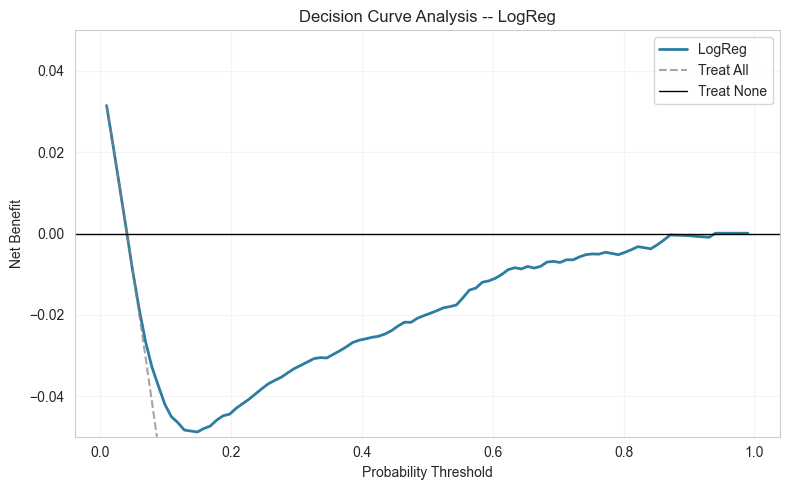

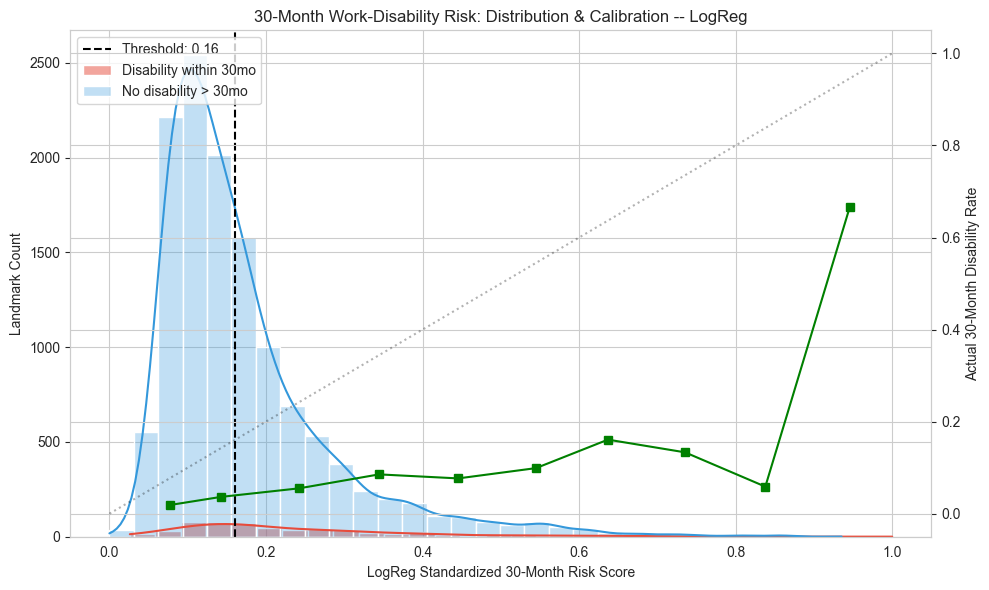

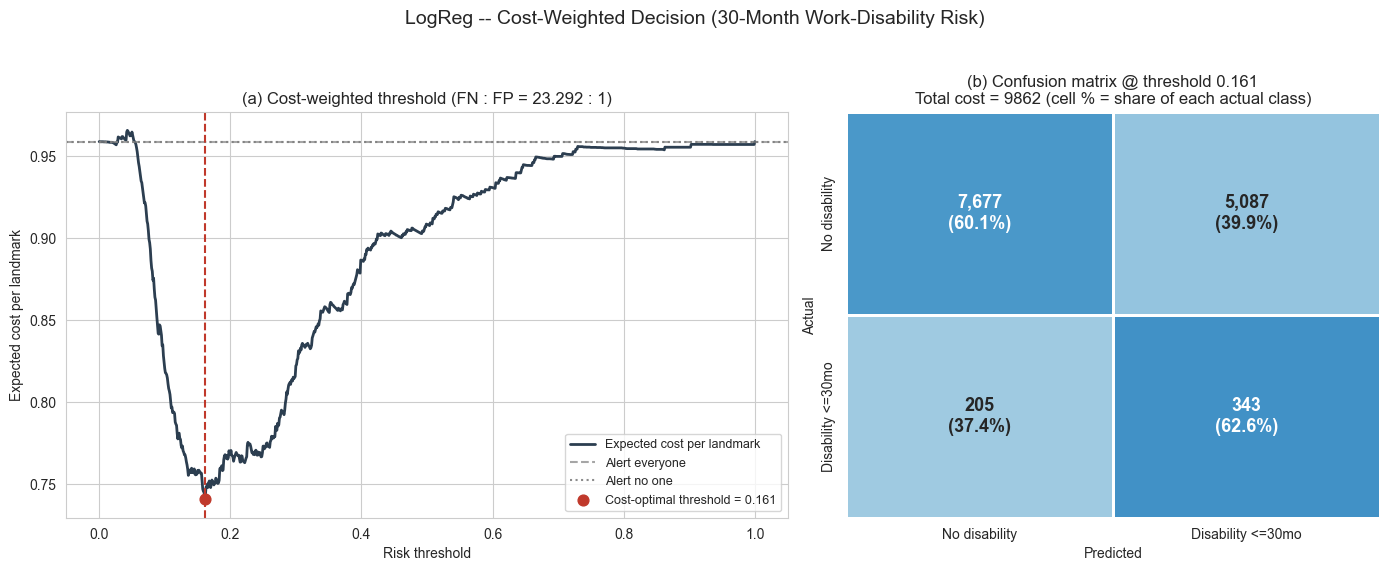


LogReg (patient-level) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.6258     | Discrimination
Brier Score                    | 0.1631     | Overall accuracy (lower=better)
Calibration Slope              | 0.6927     | Ideal = 1.0
Calibration Intercept          | 0.0005     | Ideal = 0.0
Sensitivity                    | 0.8068     | [0.742, 0.858]
Specificity                    | 0.3520     | [0.318, 0.388]
PPV                            | 0.2351     | [0.203, 0.271]
NPV                            | 0.8807     | [0.838, 0.913]
Balanced Accuracy              | 0.5794     | [0.547, 0.611]

LogReg -- PATIENT-LEVEL OPERATIONAL METRICS
----------------------------------------------------------------------
Patients      

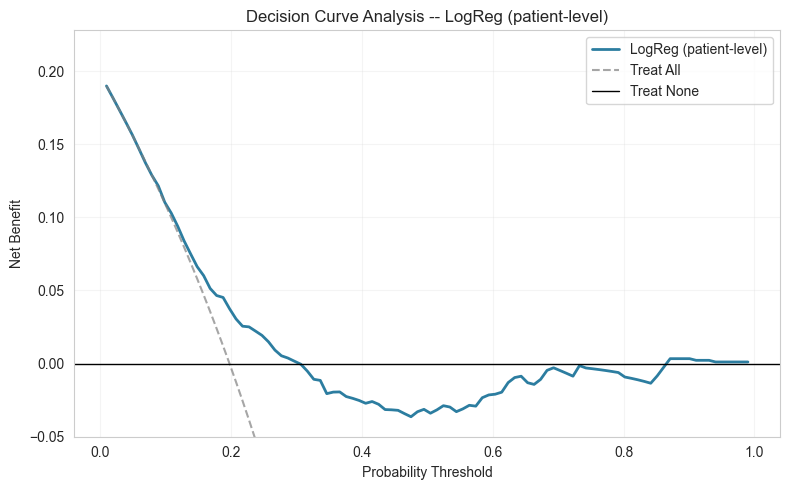

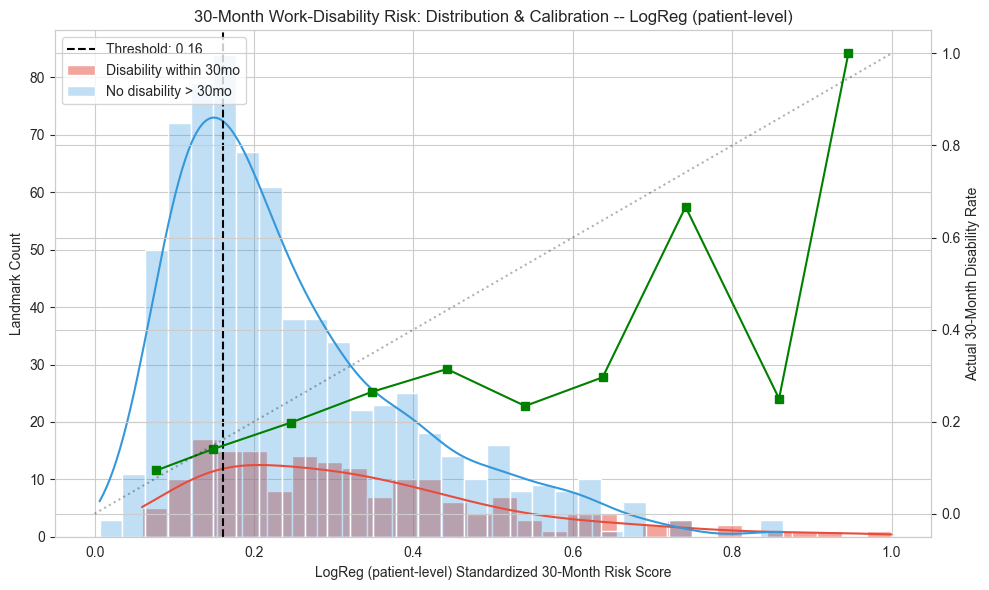

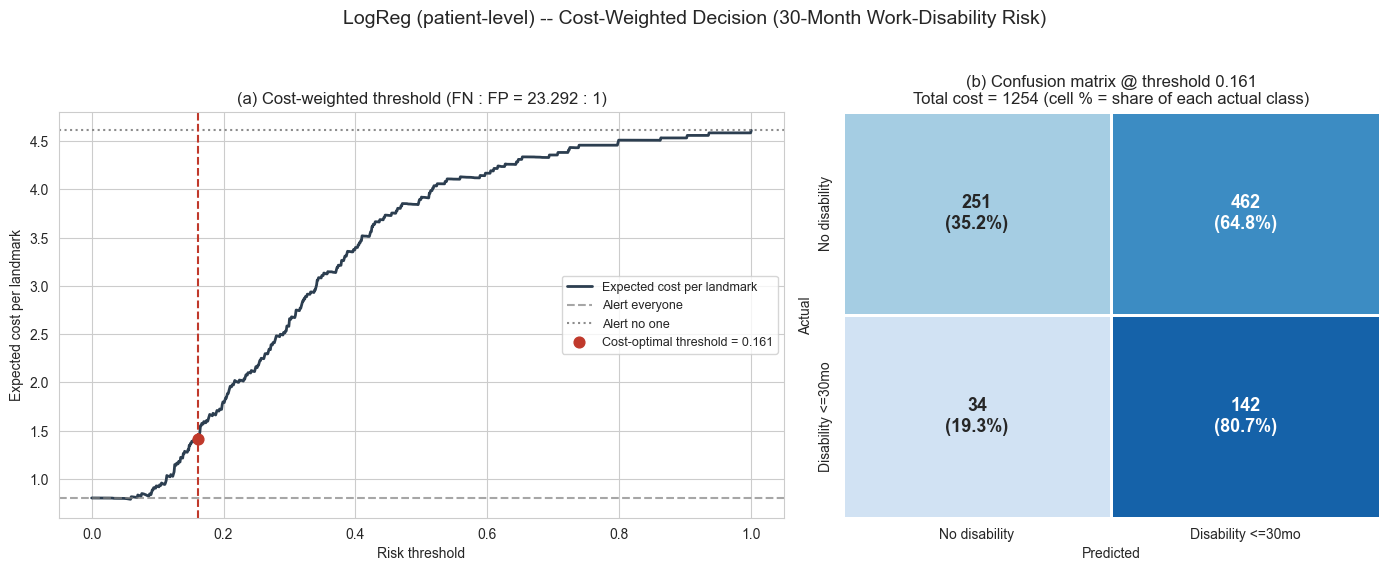

Fitting MICE imputer...
[LogReg] Landmark sample prevalence: 4.1%  |  Calibration-fold prevalence: 4.1%  |  Target prevalence used: 4.1%


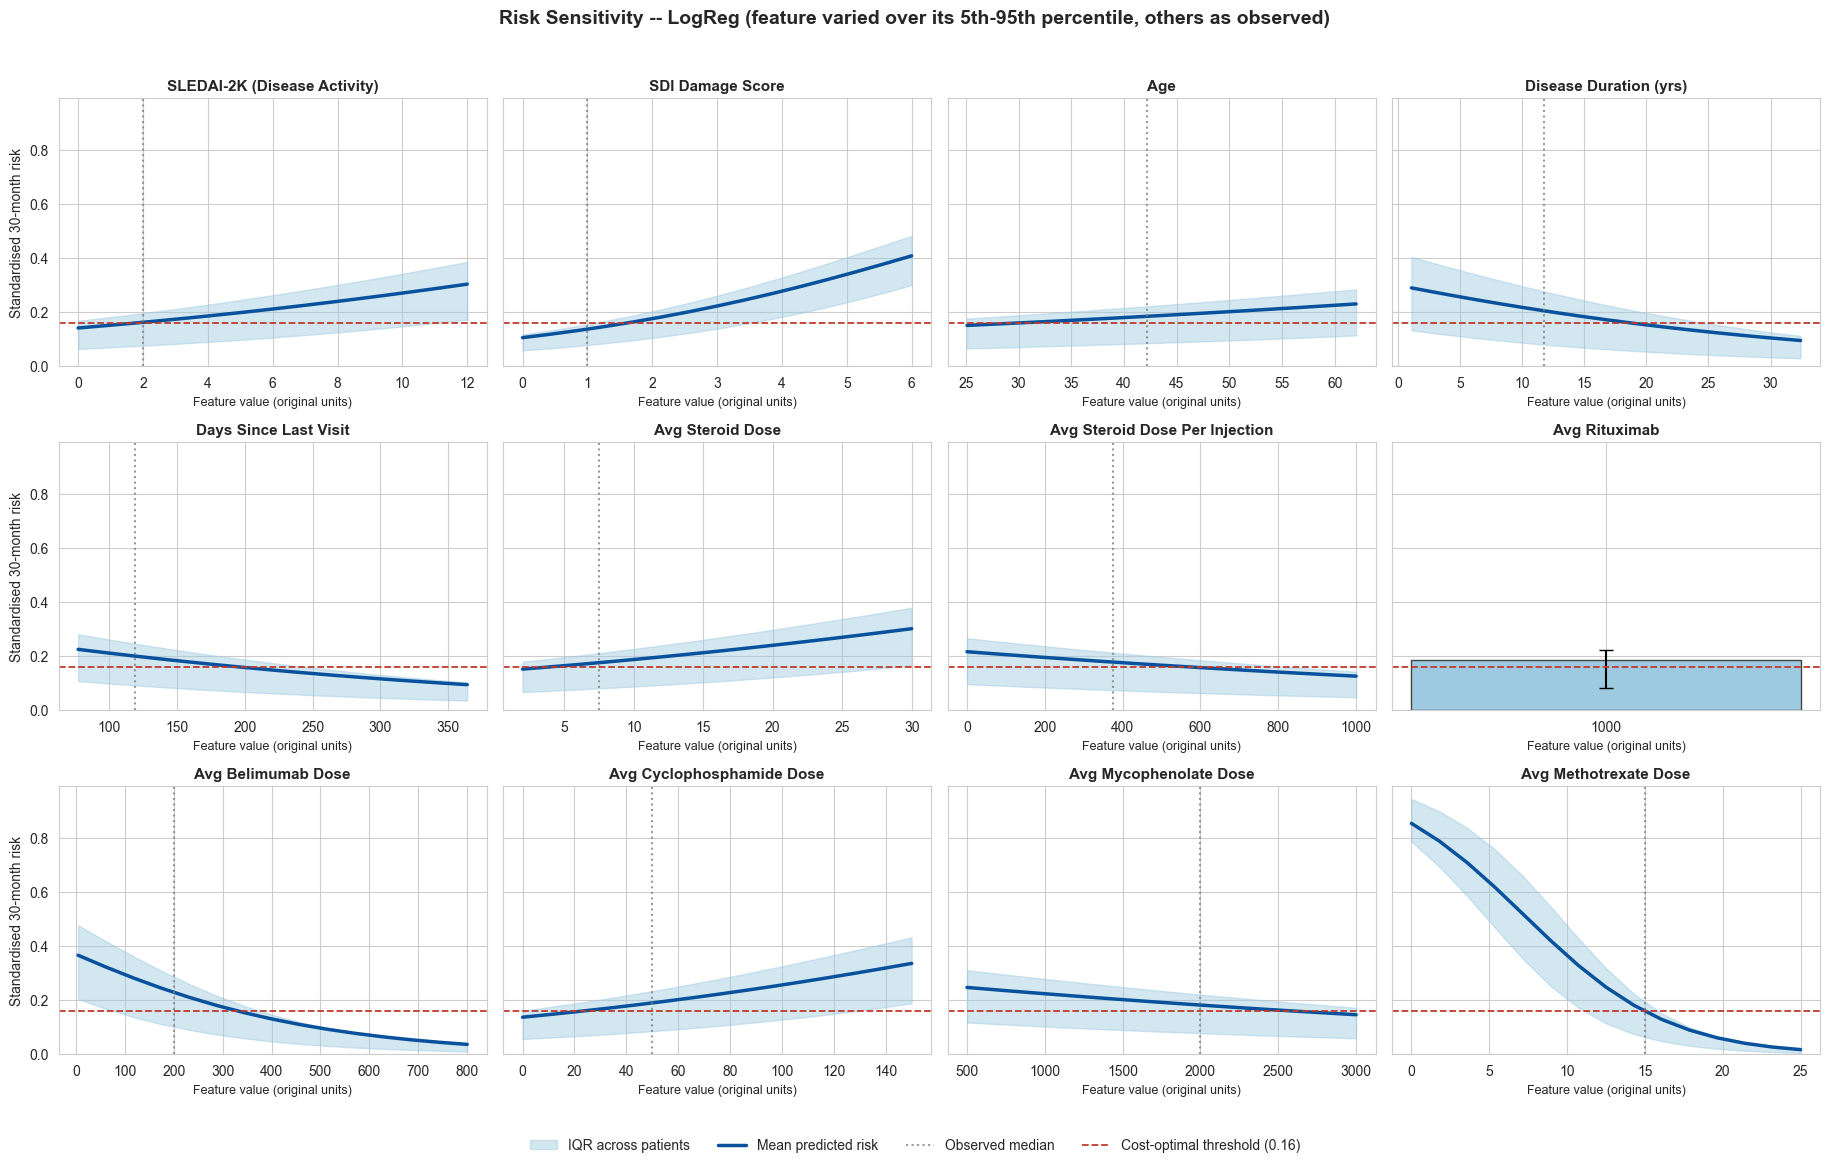


Risk-sensitivity summary -- LogReg (mean standardised risk; ranked by swing)
                       Feature  Risk @ low value  Risk @ high value  Risk swing (max-min)
         Avg Methotrexate Dose             0.855              0.017                 0.838
            Avg Belimumab Dose             0.367              0.037                 0.330
              SDI Damage Score             0.106              0.409                 0.303
     Avg Cyclophosphamide Dose             0.137              0.336                 0.199
        Disease Duration (yrs)             0.290              0.095                 0.195
  SLEDAI-2K (Disease Activity)             0.142              0.304                 0.162
              Avg Steroid Dose             0.152              0.302                 0.150
         Days Since Last Visit             0.226              0.095                 0.131
        Avg Mycophenolate Dose             0.247              0.146                 0.101
Avg Steroid Dose Per I

In [10]:
"""Landmark Logistic Regression, 30-month work-disability risk (SLE),
MICE-imputed features. Tuned and scored with repeated cross-validation (see
run_analysis below and the "Repeated Cross-Validation Infrastructure" cells
above). Adapted from the notebook's LandmarkSurvivalLogReg."""
import numpy as np
import pandas as pd
import random
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from lifelines.utils import concordance_index


random.seed(240); np.random.seed(240); torch.manual_seed(240)


class LandmarkSurvivalLogReg:
    def __init__(self, horizon_days=913):
        self.horizon_days = horizon_days
        self.feature_cols = FEATURE_COLS
        self.scaler = StandardScaler()
        self.model = LogisticRegression(class_weight="balanced", random_state=240, max_iter=1000)
        self.imputer = None
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.calibrator = None
    def prepare_data(self, land):
        raw = land[self.feature_cols].values.astype(float)
        print("Fitting MICE imputer...")
        self.imputer = train_mice(raw, max_iter=10, seed=240)
        imputed = impute_with_mice(self.imputer, raw)
        self.imputed = imputed  # unscaled, imputed features (used by risk-sensitivity analysis)
        scaled = self.scaler.fit_transform(imputed)
        X = scaled
        y = land["label"].values
        w = land["weight"].values
        return X, y, w

    def _predict_risk_override(self, rows, j, v):
        Xm = self.imputed[rows].copy()
        Xm[:, j] = v
        p = self.model.predict_proba(self.scaler.transform(Xm))[:, 1]
        calibrated = apply_risk_calibrator(self.calibrator, p)
        return np.clip(self.final_scaler.transform(calibrated.reshape(-1, 1)).flatten(), 1e-5, 1 - 1e-5)    

    def run_analysis(self, land):
        # 1. Repeated, patient-grouped, stratified K-fold CV: the MICE imputer,
        #    scaler, LogReg fit, Platt calibrator, cost weights and cost-optimal
        #    threshold are all learned inside each training fold only, and scored
        #    on that fold's held-out rows -- never train == test.
        global cv_state
        cv_state = run_repeated_cv(models=["LogReg"])
        report_repeated_cv("LogReg")
        y, risks, y_pred, best_t, c_idx = cv_pooled_predictions("LogReg", cv_state)

        report_comprehensive_metrics("LogReg (MICE-imputed), repeated CV", y, y_pred, risks, c_idx)
        meta = land.copy()
        meta["y_pred"] = y_pred
        print_operational_metrics("LogReg", meta, label_col="label")
        print_cost_metrics("LogReg", y, y_pred, best_t)
        plot_decision_curve("LogReg", y, risks, color="#2c7da0")
        plot_risk_distribution_and_calibration("LogReg", risks, y, best_t)
        plot_cost_decision_and_confusion("LogReg", y, risks, best_t)

        # 1b. Patient-level results: accumulate each patient's full follow-up.
        #     A patient who eventually goes into work disability is a true
        #     positive if ANY landmark in their follow-up crossed the alert
        #     threshold; a patient who never goes into work disability is a
        #     true negative only if NO landmark in their follow-up did.
        #     Patient-level risk is the peak (max) risk over that patient's
        #     follow-up, so thresholding it at the same best_t reproduces
        #     "alerted at any point in follow-up" exactly.
        patient_df = build_patient_level_frame(land, risks, y_pred)
        y_p, risks_p, y_pred_p = patient_df["label"].values, patient_df["risk"].values, patient_df["y_pred"].values
        c_idx_p = concordance_index(patient_df["duration"], -risks_p, patient_df["event"])

        report_comprehensive_metrics("LogReg (patient-level)", y_p, y_pred_p, risks_p, c_idx_p)
        print_patient_operational_metrics("LogReg", patient_df)
        print_cost_metrics("LogReg (patient-level)", y_p, y_pred_p, best_t)
        plot_decision_curve("LogReg (patient-level)", y_p, risks_p, color="#2c7da0")
        plot_risk_distribution_and_calibration("LogReg (patient-level)", risks_p, y_p, best_t)
        plot_cost_decision_and_confusion("LogReg (patient-level)", y_p, risks_p, best_t)

        # 2. Final refit on ALL landmark rows -- builds the deployed model object
        #    used only for the risk-sensitivity curves below, the SHAP dashboard
        #    and the cross-model calibration plot. None of the metrics/plots
        #    above come from this fit.
        X, y_full, w = self.prepare_data(land)
        self.model.fit(X, y_full, sample_weight=w)
        risks_raw = self.model.predict_proba(X)[:, 1]
        self.calibrator = fit_risk_calibrator(risks_raw, y_full, seed=240, model_name="LogReg")
        calibrated = apply_risk_calibrator(self.calibrator, risks_raw)
        self.final_scaler.fit(calibrated.reshape(-1, 1))   # fits final_scaler for _predict_risk_override

        sens_curves = compute_risk_sensitivity(self.feature_cols, land, self._predict_risk_override)
        plot_risk_sensitivity("LogReg", sens_curves, best_t)

        return {"model": self, "risks": risks, "y": y, "y_pred": y_pred, "c_index": c_idx,
                "best_t": best_t, "sensitivity": sens_curves, "patient": patient_df,
                "patient_c_index": c_idx_p}

logreg_pipeline = LandmarkSurvivalLogReg(horizon_days=HORIZON_DAYS)
res_logreg = logreg_pipeline.run_analysis(land)


## Model 2/5 — Random Survival Forest (MICE-imputed features)

Resuming from cv_state.pkl: 25 model-fold fits already done.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[RSF   ] repeat 1/5 fold 1/5 | C-index 0.629  AUROC 0.681  sens 0.65  spec 0.62  cost saving +20.1%  (32s)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[RSF   ] repeat 1/5 fold 2/5 | C-index 0.579  AUROC 0.570  sens 0.63  spec 0.43  cost saving -3.6%  (29s)


...

[RSF   ] repeat 5/5 fold 5/5 | C-index 0.636  AUROC 0.667  sens 0.50  spec 0.74  cost saving +10.9%  (34s)

Done in 27.0 min. 50 model-fold fits stored in cv_state.pkl.
RSF -- REPEATED CV, HELD-OUT PERFORMANCE: mean (SD) over 25 test folds (5 repeats x 5 folds)
----------------------------------------------------------------------------------------------------


,Folds,Repeats,C-index,AUROC,PR-AUC,Brier,Cal. slope,Cal. intercept,Sensitivity,Specificity,PPV,NPV,Bal. Acc,Cost saving,Threshold,Sec/fit
Model,,,,,,,,,,,,,,,,
RSF,25,5,0.606 (0.044),0.638 (0.043),0.090 (0.032),0.039 (0.005),1.038 (0.581),-0.025 (0.156),0.484 (0.156),0.682 (0.135),0.065 (0.016),0.969 (0.005),0.583 (0.037),0.113 (0.086),0.09 (0.09),65



Out-of-fold predictions pooled within each repeat, mean (SD) across repeats:


,Repeats,C-index,AUROC,PR-AUC,Brier,Cal. slope,Cal. intercept,Sensitivity,Specificity,PPV,NPV,Bal. Acc,Cost saving
Model,,,,,,,,,,,,,
RSF,5,0.599 (0.008),0.632 (0.019),0.075 (0.004),0.039 (0.000),0.830 (0.100),-0.017 (0.020),0.492 (0.060),0.682 (0.059),0.063 (0.005),0.969 (0.001),0.587 (0.008),0.174 (0.016)



RSF (MICE-imputed), repeated CV -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.6100     | Discrimination
Brier Score                    | 0.0433     | Overall accuracy (lower=better)
Calibration Slope              | 0.1915     | Ideal = 1.0
Calibration Intercept          | 0.0552     | Ideal = 0.0
Sensitivity                    | 0.4653     | [0.424, 0.507]
Specificity                    | 0.7664     | [0.759, 0.774]
PPV                            | 0.0788     | [0.070, 0.089]
NPV                            | 0.9709     | [0.967, 0.974]
Balanced Accuracy              | 0.6159     | [0.608, 0.624]

RSF -- OPERATIONAL / CLINICAL-BURDEN METRICS
----------------------------------------------------------------------
Aler

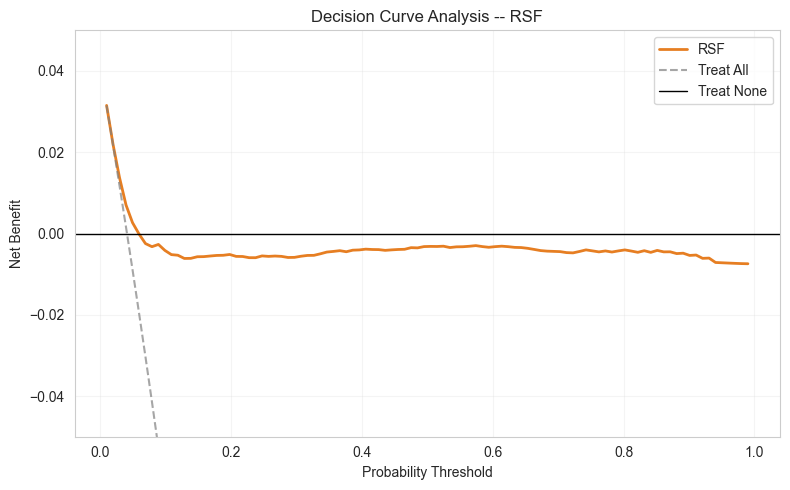

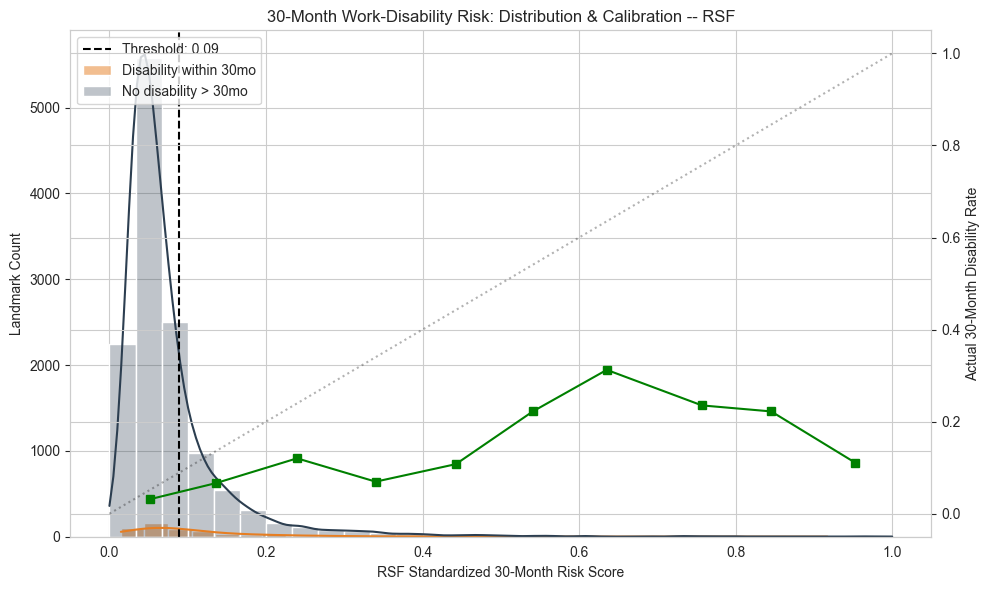

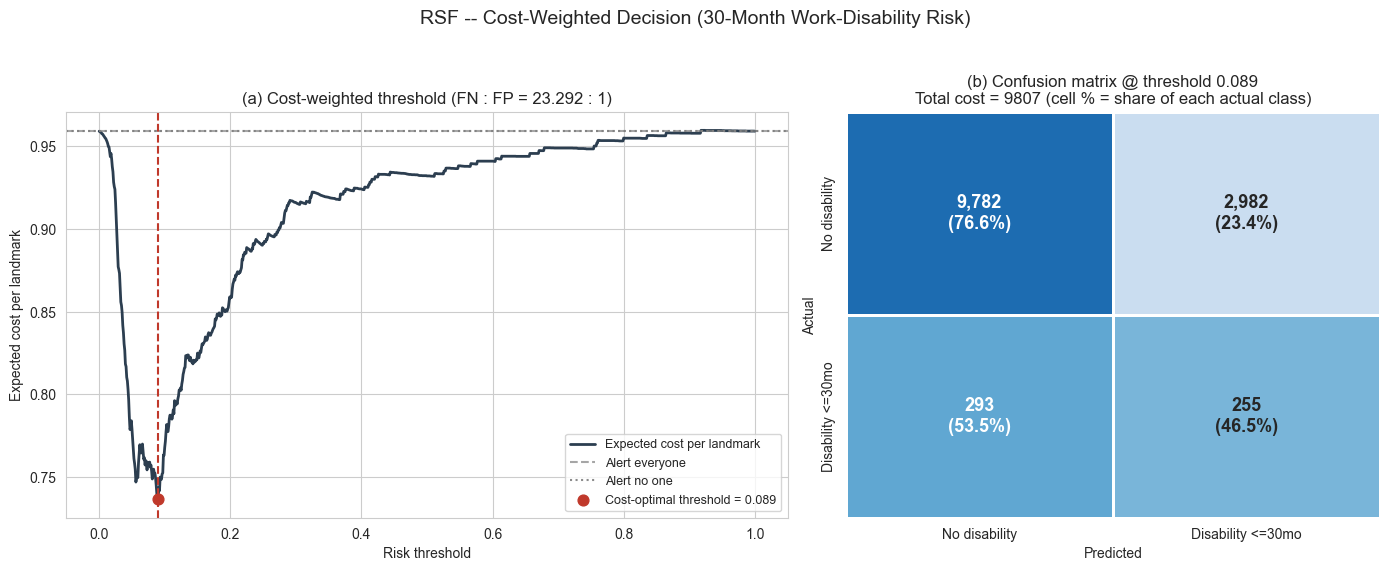


RSF (patient-level) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.5982     | Discrimination
Brier Score                    | 0.1561     | Overall accuracy (lower=better)
Calibration Slope              | 0.6228     | Ideal = 1.0
Calibration Intercept          | 0.1008     | Ideal = 0.0
Sensitivity                    | 0.7216     | [0.651, 0.783]
Specificity                    | 0.4222     | [0.386, 0.459]
PPV                            | 0.2356     | [0.202, 0.273]
NPV                            | 0.8600     | [0.820, 0.892]
Balanced Accuracy              | 0.5719     | [0.539, 0.604]

RSF -- PATIENT-LEVEL OPERATIONAL METRICS
----------------------------------------------------------------------
Patients            

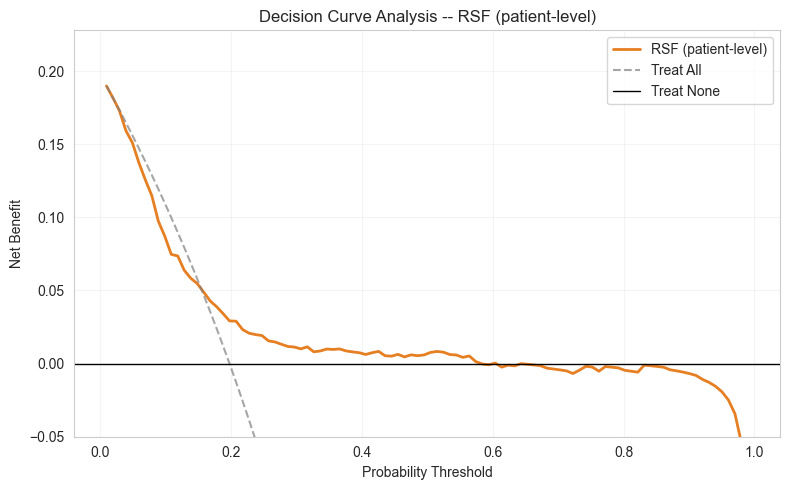

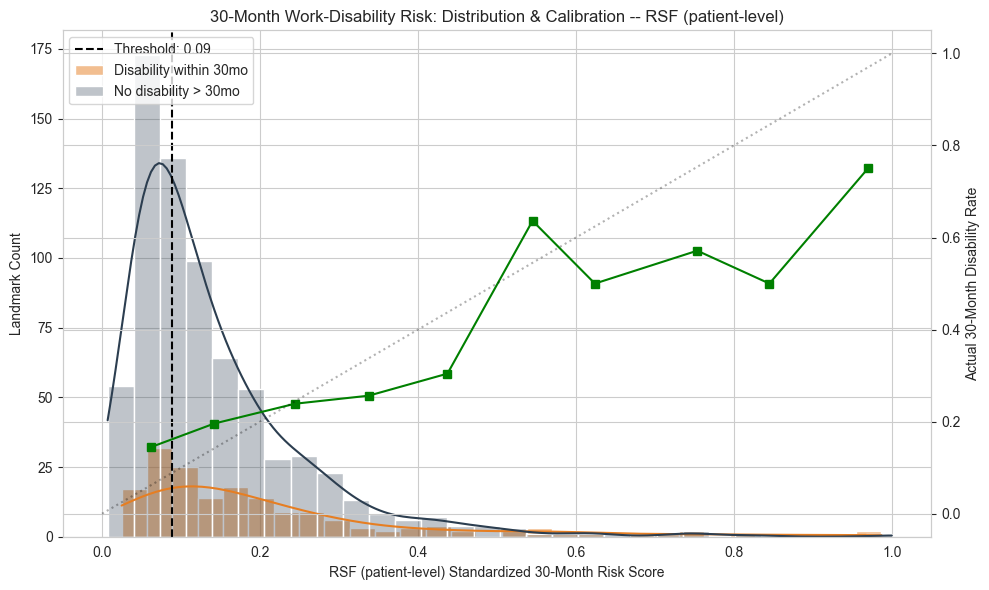

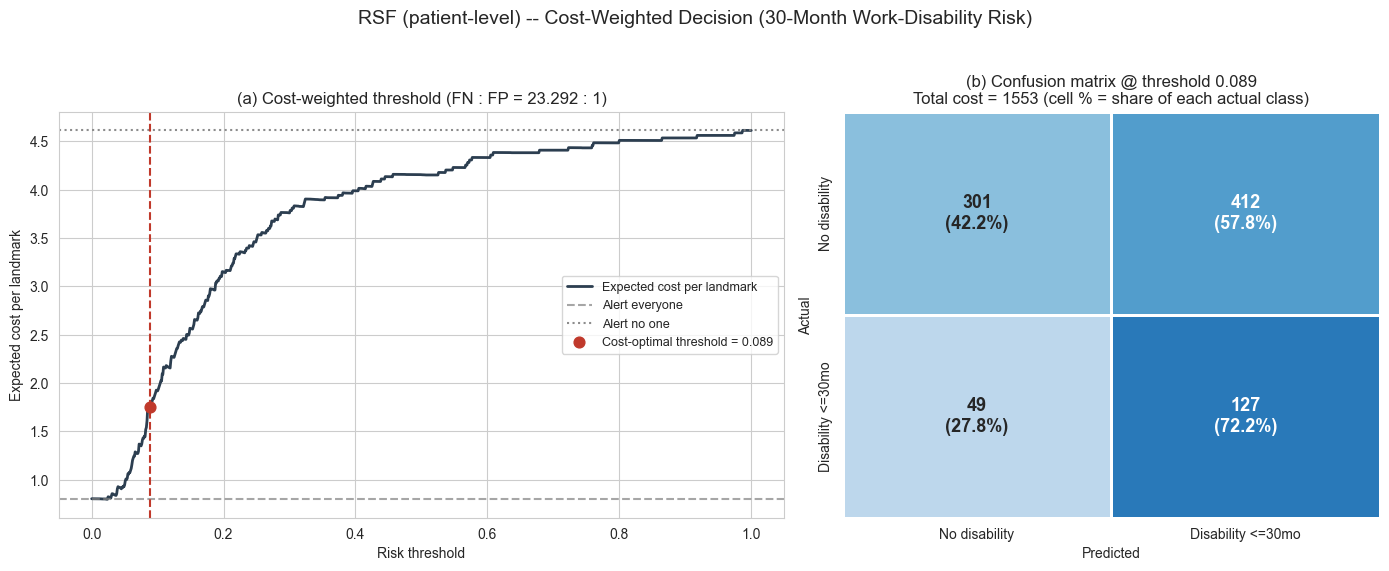

Fitting MICE imputer for feature imputation...
[RSF] Landmark sample prevalence: 4.1%  |  Calibration-fold prevalence: 4.1%  |  Target prevalence used: 4.1%


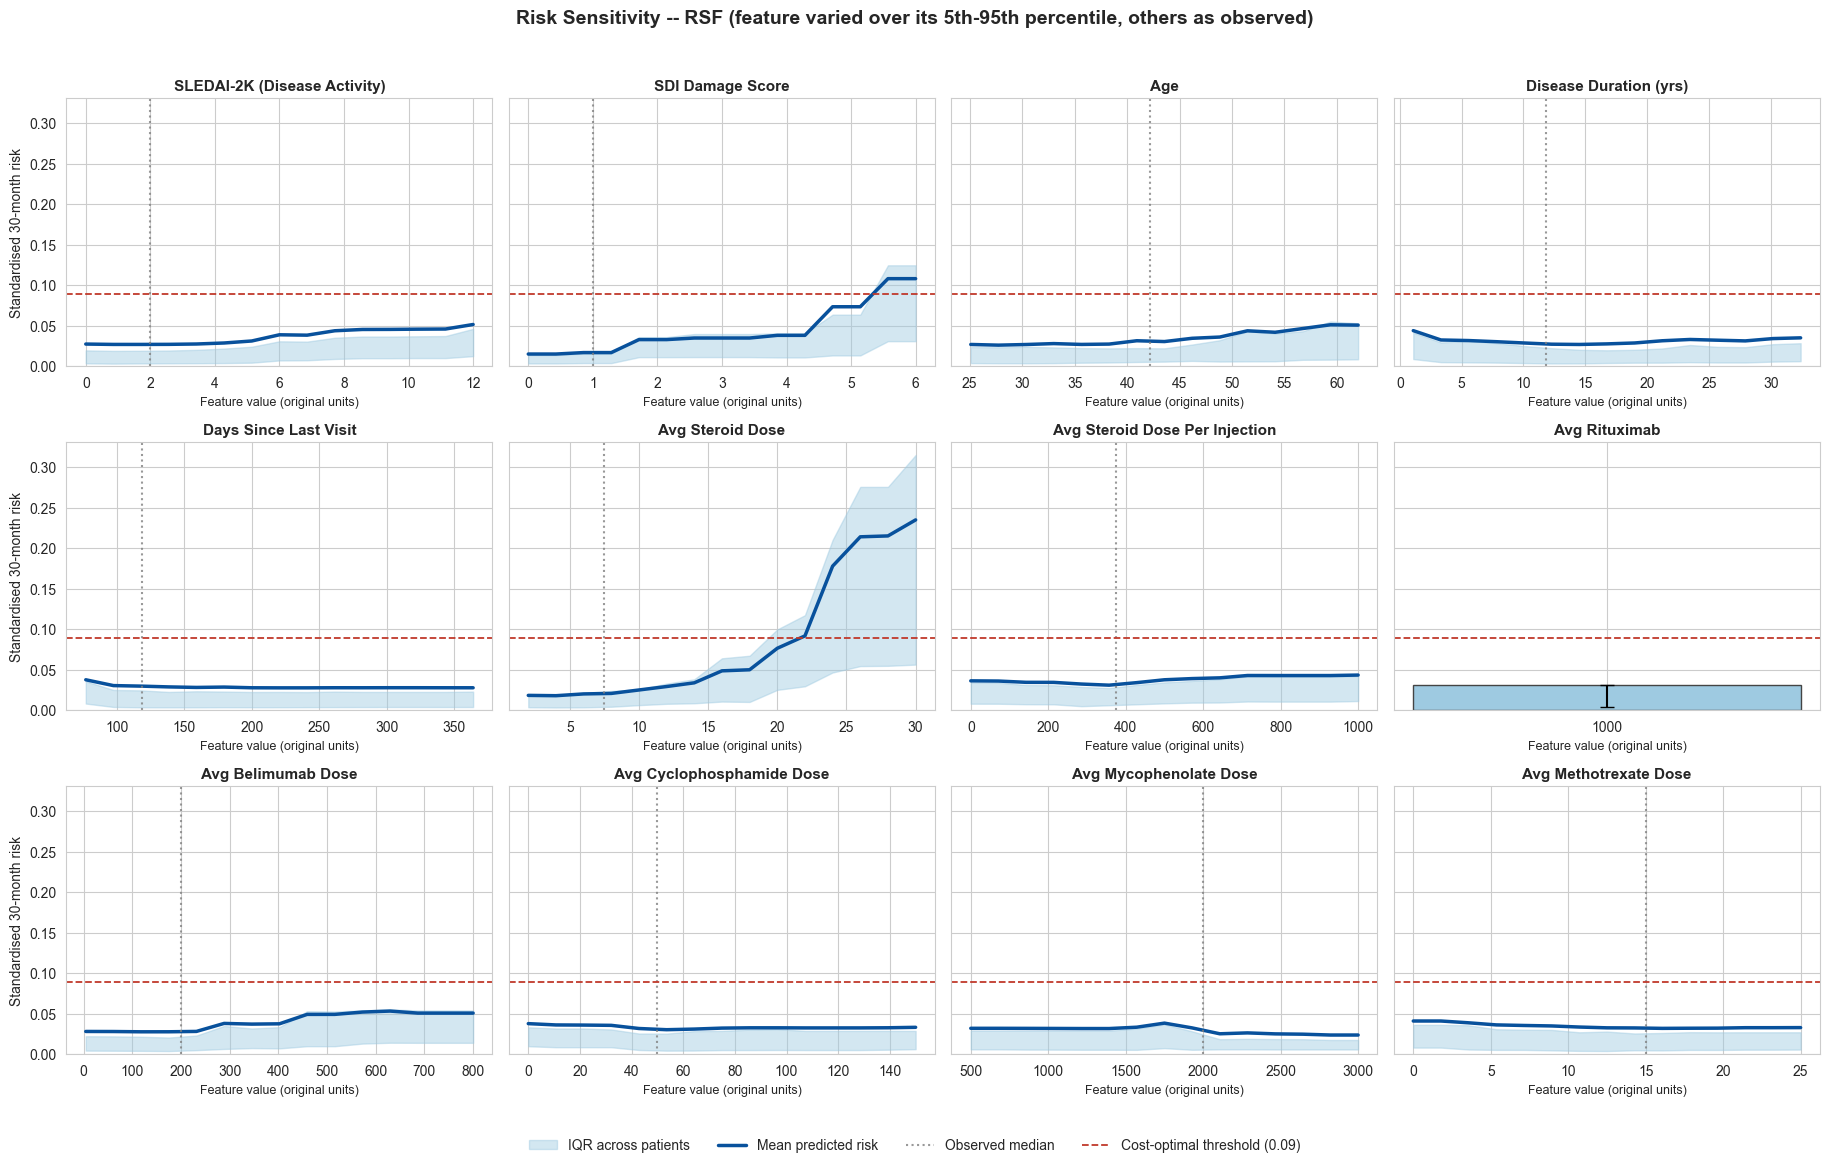


Risk-sensitivity summary -- RSF (mean standardised risk; ranked by swing)
                       Feature  Risk @ low value  Risk @ high value  Risk swing (max-min)
              Avg Steroid Dose             0.018              0.235                 0.217
              SDI Damage Score             0.015              0.108                 0.093
            Avg Belimumab Dose             0.028              0.051                 0.026
                           Age             0.027              0.051                 0.025
  SLEDAI-2K (Disease Activity)             0.027              0.052                 0.025
        Disease Duration (yrs)             0.044              0.035                 0.017
        Avg Mycophenolate Dose             0.032              0.024                 0.015
Avg Steroid Dose Per Injection             0.036              0.043                 0.012
         Days Since Last Visit             0.038              0.028                 0.010
         Avg Methotrexate

In [11]:
"""Landmark Random Survival Forest, 30-month work-disability risk (SLE),
MICE-imputed features. Tuned and scored with repeated cross-validation (see
run_analysis below and the "Repeated Cross-Validation Infrastructure" cells
above). Adapted from the notebook's LandmarkSurvivalRSF."""
import numpy as np
import pandas as pd
import random
import torch
from sklearn.preprocessing import StandardScaler
from sksurv.ensemble import RandomSurvivalForest
from lifelines.utils import concordance_index


random.seed(240); np.random.seed(240); torch.manual_seed(240)


class LandmarkSurvivalRSF:
    def __init__(self, horizon_days=913):
        self.horizon_days = horizon_days
        self.feature_cols = FEATURE_COLS
        self.scaler = StandardScaler()
        self.model = RandomSurvivalForest(
            n_estimators=50, min_samples_split=10, min_samples_leaf=15,
            max_features="sqrt", n_jobs=-1, random_state=240,
        )
        self.imputer = None
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.calibrator = None
    def prepare_data(self, land):
        raw = land[self.feature_cols].values.astype(float)
        print("Fitting MICE imputer for feature imputation...")
        self.imputer = train_mice(raw, max_iter=10, seed=240)
        imputed = impute_with_mice(self.imputer, raw)
        self.imputed = imputed  # unscaled, imputed features (used by risk-sensitivity analysis)
        scaled = self.scaler.fit_transform(imputed)

        y_struct = np.array(
            list(zip(land["event"].astype(bool), land["duration"].astype(float))),
            dtype=[("event", "bool"), ("time", "float")],
        )
        return scaled, land["label"].values, y_struct, land["weight"].values

    def _predict_risk_override(self, rows, j, v):
        """Calibrated risk for landmark `rows` with feature j forced to v (original units)."""
        Xm = self.imputed[rows].copy()
        Xm[:, j] = v
        p = self.model.predict(self.scaler.transform(Xm))
        calibrated = apply_risk_calibrator(self.calibrator, p)   # or `raw` in the GRU/LSTM cell
        return np.clip(self.final_scaler.transform(calibrated.reshape(-1, 1)).flatten(), 1e-5, 1 - 1e-5)
        #return apply_risk_calibrator(self.calibrator, p)

    def run_analysis(self, land):
        # 1. Repeated, patient-grouped, stratified K-fold CV: the MICE imputer,
        #    scaler, RSF fit, Platt calibrator, cost weights and cost-optimal
        #    threshold are all learned inside each training fold only, and scored
        #    on that fold's held-out rows -- never train == test.
        global cv_state
        cv_state = run_repeated_cv(models=["RSF"])
        report_repeated_cv("RSF")
        y, risks, y_pred, best_t, c_idx = cv_pooled_predictions("RSF", cv_state)

        report_comprehensive_metrics("RSF (MICE-imputed), repeated CV", y, y_pred, risks, c_idx)
        meta = land.copy()
        meta["y_pred"] = y_pred
        print_operational_metrics("RSF", meta, label_col="label")
        print_cost_metrics("RSF", y, y_pred, best_t)
        plot_decision_curve("RSF", y, risks, color="#e67e22")
        plot_risk_distribution_and_calibration("RSF", risks, y, best_t,
                                                color_pos="#e67e22", color_neg="#2c3e50")
        plot_cost_decision_and_confusion("RSF", y, risks, best_t)

        # 1b. Patient-level results: accumulate each patient's full follow-up.
        #     A patient who eventually goes into work disability is a true
        #     positive if ANY landmark in their follow-up crossed the alert
        #     threshold; a patient who never goes into work disability is a
        #     true negative only if NO landmark in their follow-up did.
        #     Patient-level risk is the peak (max) risk over that patient's
        #     follow-up, so thresholding it at the same best_t reproduces
        #     "alerted at any point in follow-up" exactly.
        patient_df = build_patient_level_frame(land, risks, y_pred)
        y_p, risks_p, y_pred_p = patient_df["label"].values, patient_df["risk"].values, patient_df["y_pred"].values
        c_idx_p = concordance_index(patient_df["duration"], -risks_p, patient_df["event"])

        report_comprehensive_metrics("RSF (patient-level)", y_p, y_pred_p, risks_p, c_idx_p)
        print_patient_operational_metrics("RSF", patient_df)
        print_cost_metrics("RSF (patient-level)", y_p, y_pred_p, best_t)
        plot_decision_curve("RSF (patient-level)", y_p, risks_p, color="#e67e22")
        plot_risk_distribution_and_calibration("RSF (patient-level)", risks_p, y_p, best_t,
                                                color_pos="#e67e22", color_neg="#2c3e50")
        plot_cost_decision_and_confusion("RSF (patient-level)", y_p, risks_p, best_t)

        # 2. Final refit on ALL landmark rows -- builds the deployed model object
        #    used only for the risk-sensitivity curves below, the SHAP dashboard
        #    and the cross-model calibration plot. None of the metrics/plots
        #    above come from this fit.
        X, y_full, y_surv, w = self.prepare_data(land)
        try:
            self.model.fit(X, y_surv, sample_weight=w)
        except TypeError:
            self.model.fit(X, y_surv)
        risks_raw = self.model.predict(X)
        self.calibrator = fit_risk_calibrator(risks_raw, y_full, seed=240, model_name="RSF")
        calibrated = apply_risk_calibrator(self.calibrator, risks_raw)
        self.final_scaler.fit(calibrated.reshape(-1, 1))   # fits final_scaler for _predict_risk_override

        sens_curves = compute_risk_sensitivity(self.feature_cols, land, self._predict_risk_override)
        plot_risk_sensitivity("RSF", sens_curves, best_t)

        return {"model": self, "risks": risks, "y": y, "y_pred": y_pred, "c_index": c_idx,
                "best_t": best_t, "sensitivity": sens_curves, "patient": patient_df,
                "patient_c_index": c_idx_p}

rsf_pipeline = LandmarkSurvivalRSF(horizon_days=HORIZON_DAYS)
res_rsf = rsf_pipeline.run_analysis(land)


## Model 3/5 — Cox Proportional Hazards (MICE-imputed, balanced fit)

Resuming from cv_state.pkl: 50 model-fold fits already done.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


  [CoxPH CV fold] Dropping constant covariate(s) for this fit (no ridge penalizer can rescue a zero-variance column): ['RIT_AVDS']
[CoxPH ] repeat 1/5 fold 1/5 | C-index 0.597  AUROC 0.636  sens 0.52  spec 0.66  cost saving +7.7%  (10s)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


  [CoxPH CV fold] Dropping constant covariate(s) for this fit (no ridge penalizer can rescue a zero-variance column): ['RIT_AVDS', 'IS_CYCLOPHOSPHAMIDE_DOSE']
[CoxPH ] repeat 1/5 fold 2/5 | C-index 0.646  AUROC 0.655  sens 0.89  spec 0.29  cost saving +14.4%  (8s)


...

  [CoxPH CV fold] Dropping constant covariate(s) for this fit (no ridge penalizer can rescue a zero-variance column): ['RIT_AVDS']
[CoxPH ] repeat 5/5 fold 5/5 | C-index 0.590  AUROC 0.633  sens 0.23  spec 0.86  cost saving -9.7%  (10s)

Done in 14.5 min. 75 model-fold fits stored in cv_state.pkl.
CoxPH -- REPEATED CV, HELD-OUT PERFORMANCE: mean (SD) over 25 test folds (5 repeats x 5 folds)
----------------------------------------------------------------------------------------------------


,Folds,Repeats,C-index,AUROC,PR-AUC,Brier,Cal. slope,Cal. intercept,Sensitivity,Specificity,PPV,NPV,Bal. Acc,Cost saving,Threshold,Sec/fit
Model,,,,,,,,,,,,,,,,
CoxPH,25,5,0.605 (0.044),0.653 (0.052),0.086 (0.029),0.039 (0.005),3.207 (1.798),-0.014 (0.146),0.517 (0.209),0.663 (0.187),0.065 (0.013),0.971 (0.008),0.590 (0.040),0.123 (0.110),0.39 (0.12),35



Out-of-fold predictions pooled within each repeat, mean (SD) across repeats:


,Repeats,C-index,AUROC,PR-AUC,Brier,Cal. slope,Cal. intercept,Sensitivity,Specificity,PPV,NPV,Bal. Acc,Cost saving
Model,,,,,,,,,,,,,
CoxPH,5,0.598 (0.006),0.644 (0.006),0.075 (0.003),0.039 (0.000),2.299 (0.356),-0.005 (0.008),0.521 (0.082),0.663 (0.092),0.064 (0.008),0.970 (0.001),0.592 (0.007),0.184 (0.015)



CoxPH (MICE-imputed, balanced fit), repeated CV -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.6075     | Discrimination
Brier Score                    | 0.0959     | Overall accuracy (lower=better)
Calibration Slope              | 0.4351     | Ideal = 1.0
Calibration Intercept          | -0.0833     | Ideal = 0.0
Sensitivity                    | 0.5073     | [0.466, 0.549]
Specificity                    | 0.7238     | [0.716, 0.731]
PPV                            | 0.0731     | [0.065, 0.082]
NPV                            | 0.9716     | [0.968, 0.975]
Balanced Accuracy              | 0.6155     | [0.607, 0.624]

CoxPH -- OPERATIONAL / CLINICAL-BURDEN METRICS
--------------------------------------------------------

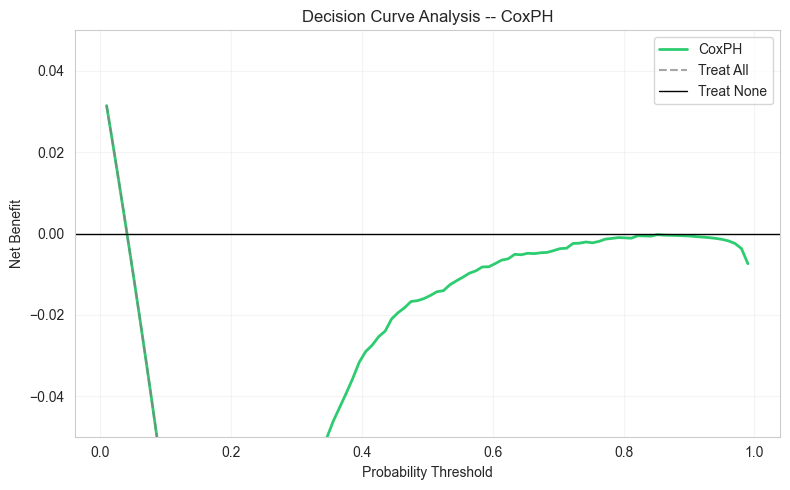

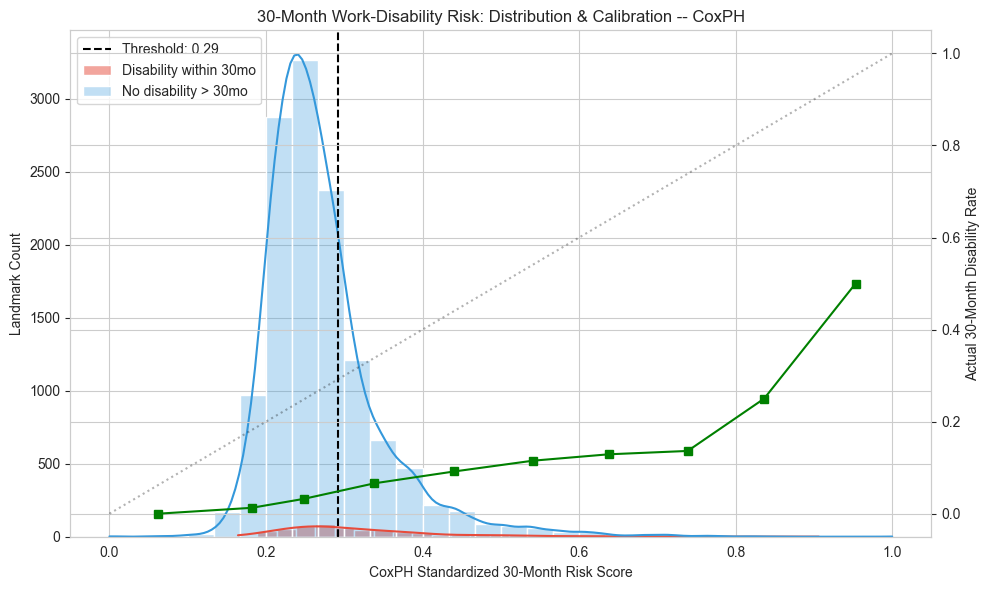

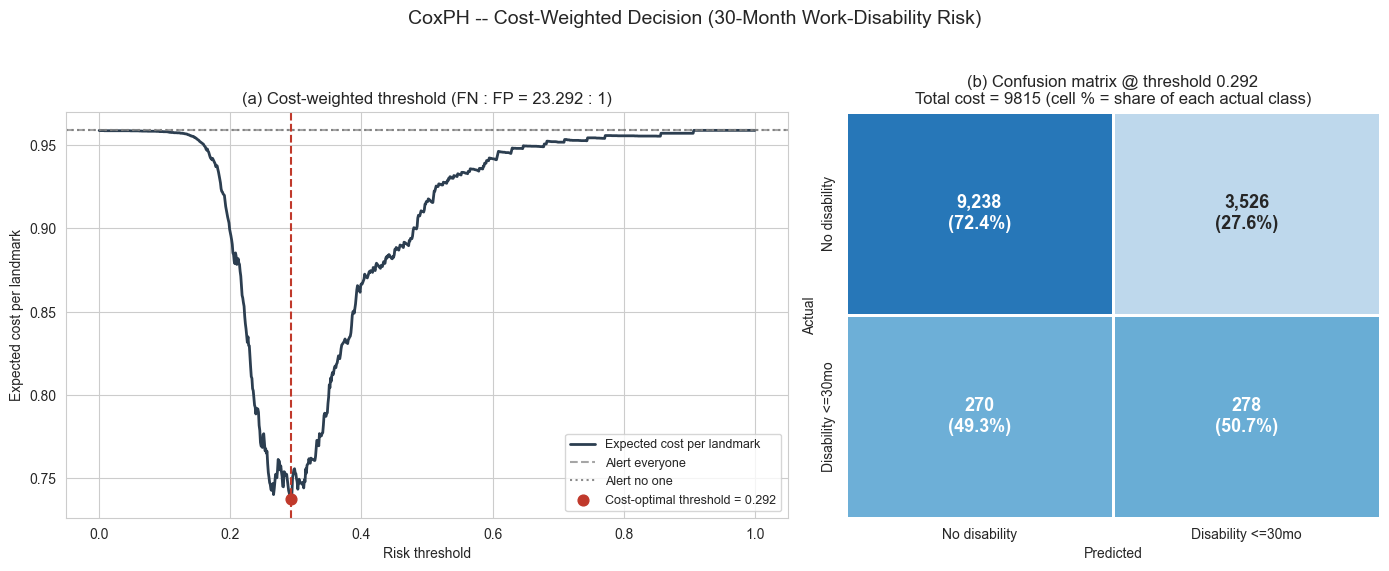


CoxPH (patient-level) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.6180     | Discrimination
Brier Score                    | 0.1810     | Overall accuracy (lower=better)
Calibration Slope              | 1.0787     | Ideal = 1.0
Calibration Intercept          | -0.1858     | Ideal = 0.0
Sensitivity                    | 0.7784     | [0.711, 0.833]
Specificity                    | 0.3815     | [0.347, 0.418]
PPV                            | 0.2370     | [0.204, 0.273]
NPV                            | 0.8746     | [0.833, 0.907]
Balanced Accuracy              | 0.5799     | [0.547, 0.612]

CoxPH -- PATIENT-LEVEL OPERATIONAL METRICS
----------------------------------------------------------------------
Patients       

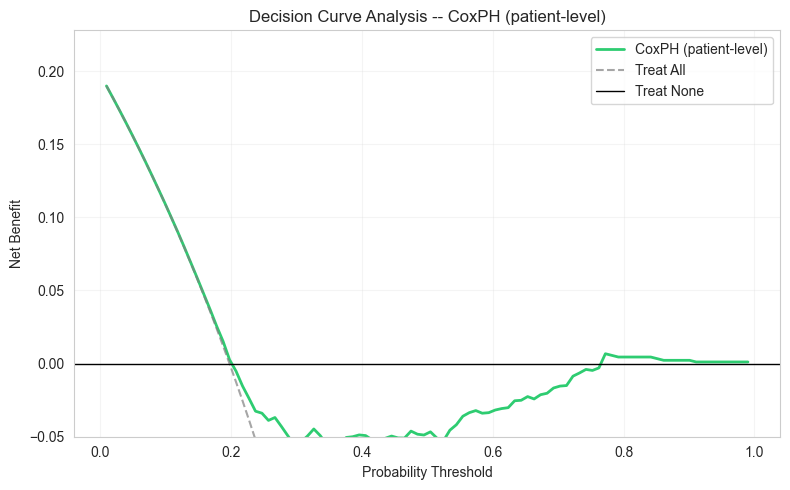

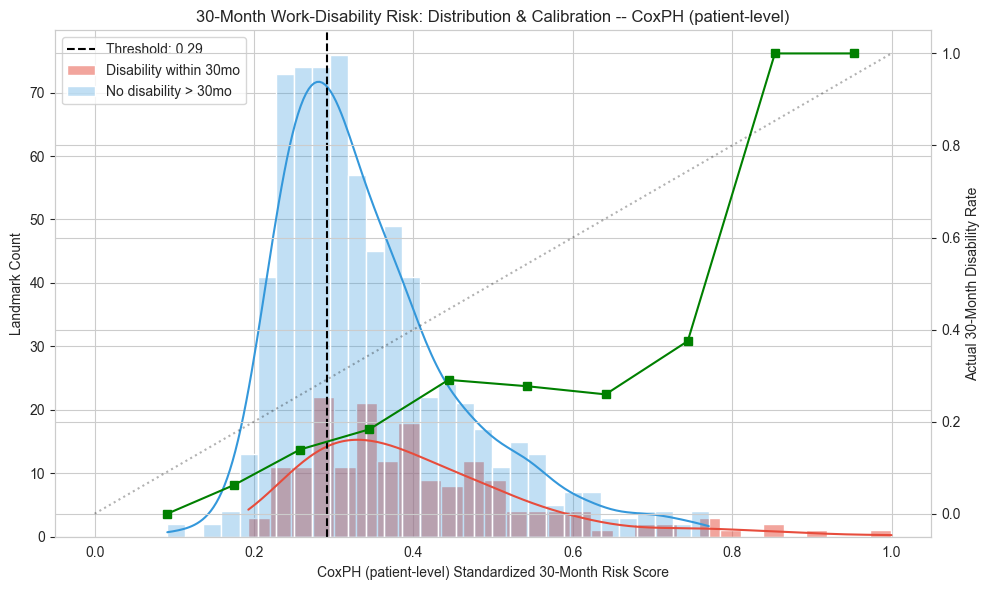

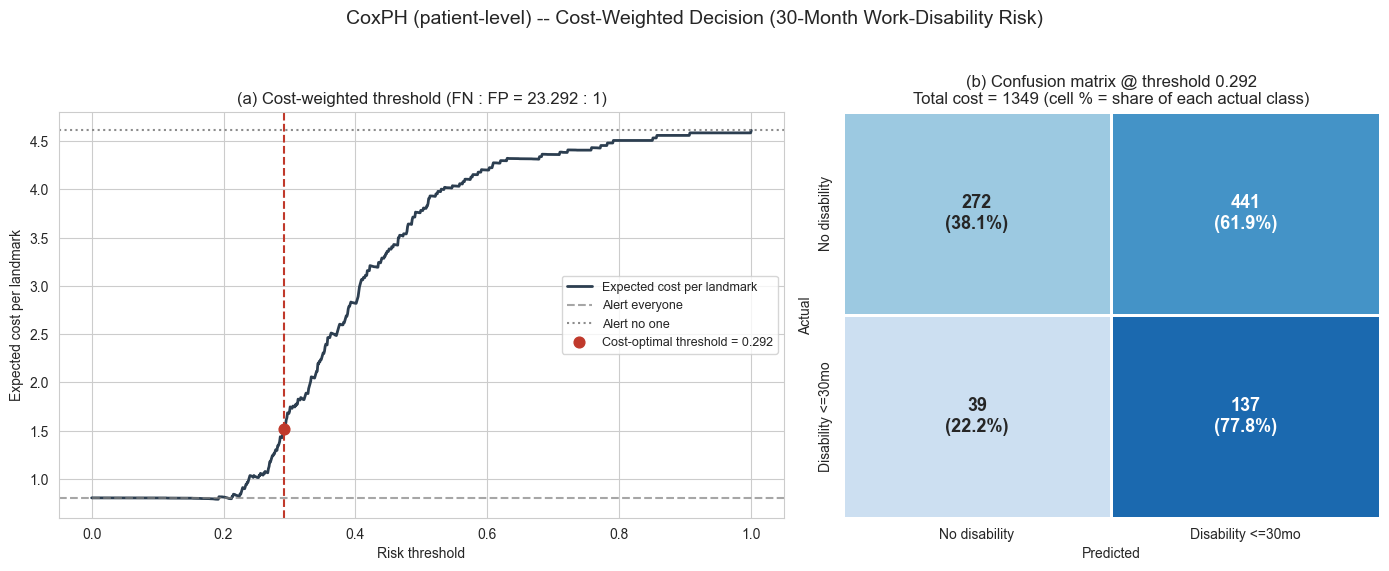

Fitting MICE imputer for feature imputation...
  [CoxPH final refit] Dropping constant covariate(s) for this fit (no ridge penalizer can rescue a zero-variance column): ['RIT_AVDS']
[CoxPH] Landmark sample prevalence: 4.1%  |  Calibration-fold prevalence: 4.1%  |  Target prevalence used: 4.1%


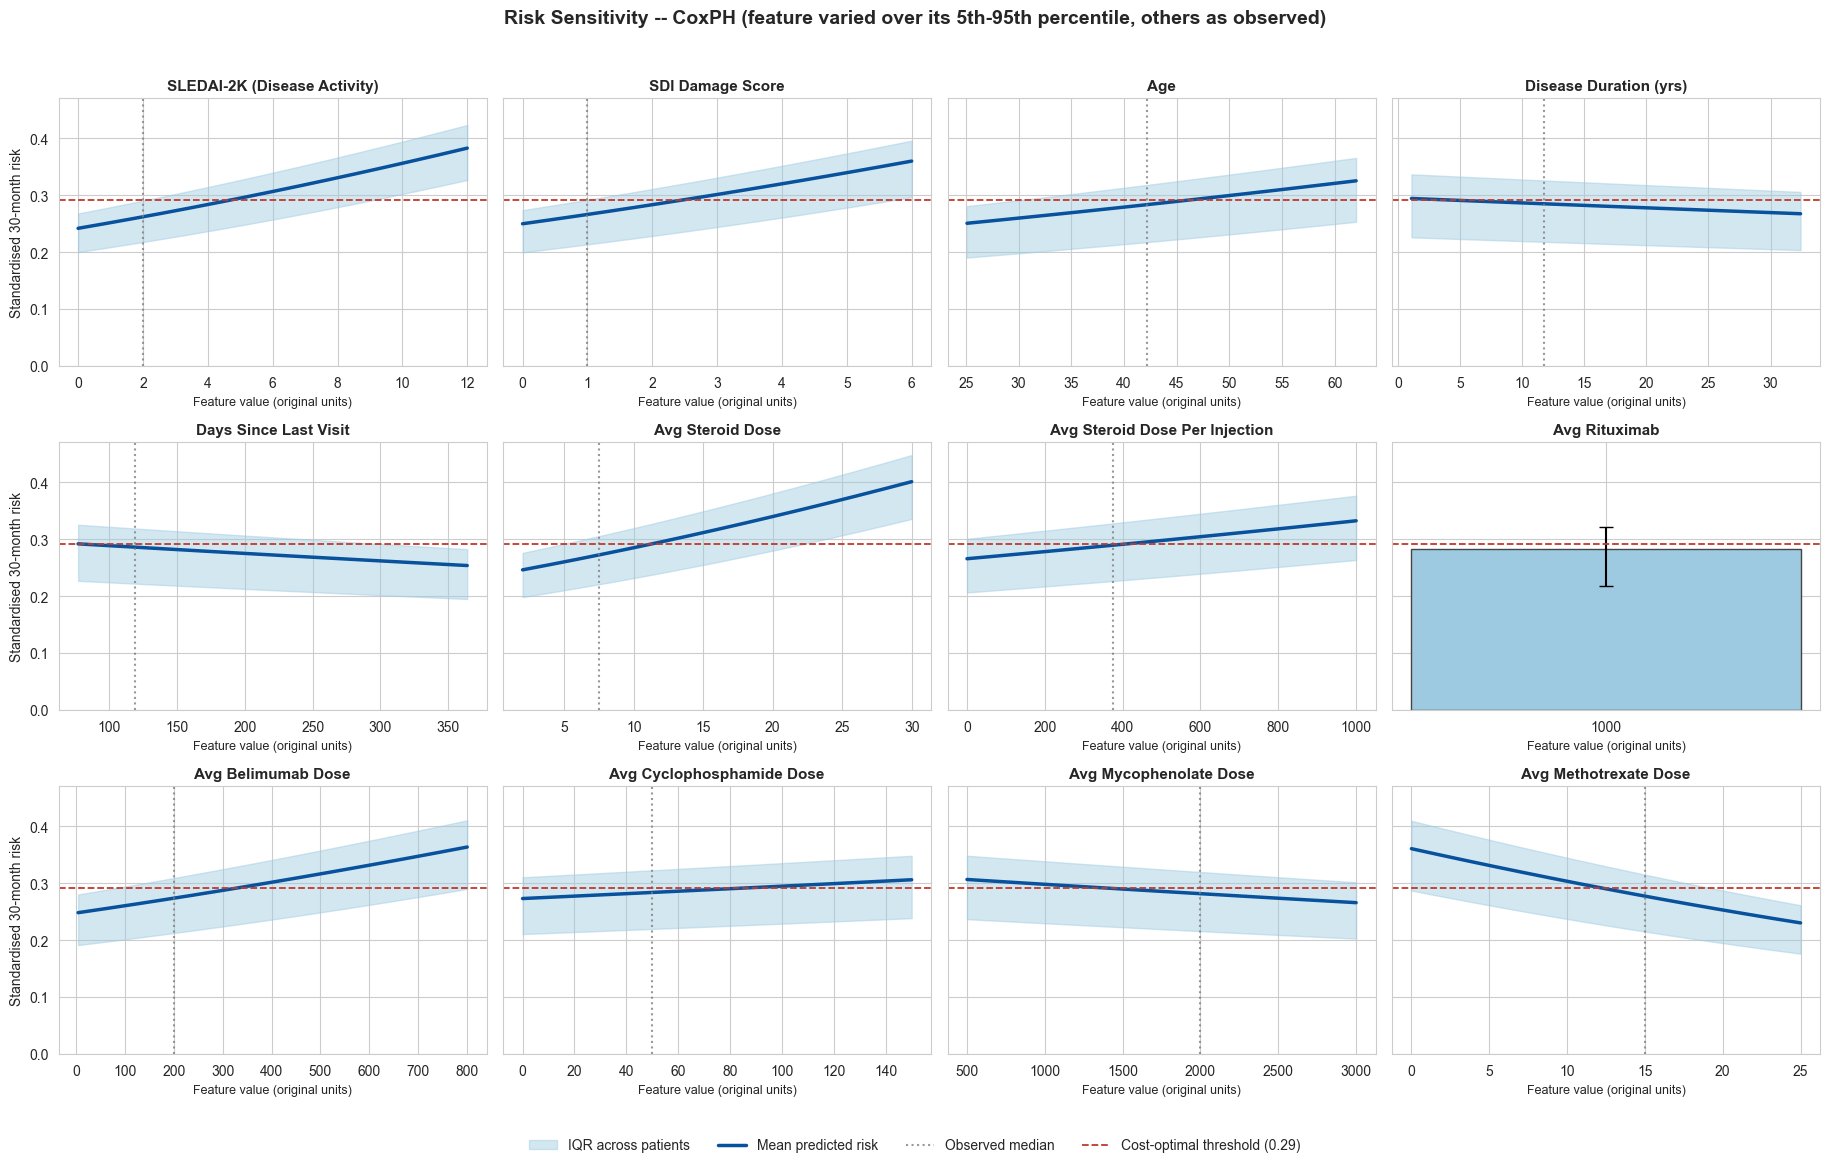


Risk-sensitivity summary -- CoxPH (mean standardised risk; ranked by swing)
                       Feature  Risk @ low value  Risk @ high value  Risk swing (max-min)
              Avg Steroid Dose             0.247              0.401                 0.155
  SLEDAI-2K (Disease Activity)             0.242              0.383                 0.141
         Avg Methotrexate Dose             0.361              0.231                 0.130
            Avg Belimumab Dose             0.249              0.364                 0.115
              SDI Damage Score             0.250              0.360                 0.110
                           Age             0.251              0.326                 0.075
Avg Steroid Dose Per Injection             0.266              0.333                 0.067
        Avg Mycophenolate Dose             0.307              0.266                 0.041
         Days Since Last Visit             0.292              0.254                 0.038
     Avg Cyclophosphami

In [12]:
"""Landmark Cox Proportional Hazards model, 30-month work-disability risk
(SLE), MICE-imputed features, balanced (oversampled) fit. Tuned and scored
with repeated cross-validation (see run_analysis below and the "Repeated
Cross-Validation Infrastructure" cells above). Adapted from the notebook's
LandmarkSurvivalCoxPH."""
import numpy as np
import pandas as pd
import random
import torch
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index


random.seed(240); np.random.seed(240); torch.manual_seed(240)


class LandmarkSurvivalCoxPH:
    def __init__(self, horizon_days=913):
        self.horizon_days = horizon_days
        self.feature_cols = FEATURE_COLS
        self.scaler = StandardScaler()
        self.model = None   # set by fit_cox_with_backoff in run_analysis (penalizer chosen adaptively)
        self.imputer = None
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.calibrator = None
    def prepare_data(self, land):
        raw = land[self.feature_cols].values.astype(float)
        print("Fitting MICE imputer for feature imputation...")
        self.imputer = train_mice(raw, max_iter=10, seed=240)
        imputed = impute_with_mice(self.imputer, raw)
        self.imputed = imputed  # unscaled, imputed features (used by risk-sensitivity analysis)
        scaled = self.scaler.fit_transform(imputed)

        data = land.copy().reset_index(drop=True)
        data[self.feature_cols] = scaled
        return data

    def _predict_risk_override(self, rows, j, v):
        """Calibrated risk for landmark `rows` with feature j forced to v (original units)."""
        Xm = self.imputed[rows].copy()
        Xm[:, j] = v
        df = pd.DataFrame(self.scaler.transform(Xm), columns=self.feature_cols)
        surv = self.model.predict_survival_function(df, times=[self.horizon_days]).T
        p = 1 - surv.values.flatten()
        calibrated = apply_risk_calibrator(self.calibrator, p)   # or `raw` in the GRU/LSTM cell
        return np.clip(self.final_scaler.transform(calibrated.reshape(-1, 1)).flatten(), 1e-5, 1 - 1e-5)

    def run_analysis(self, land):
        # 1. Repeated, patient-grouped, stratified K-fold CV: the MICE imputer,
        #    scaler, balanced (oversampled) CoxPH fit, Platt calibrator, cost
        #    weights and cost-optimal threshold are all learned inside each
        #    training fold only, and scored on that fold's held-out rows --
        #    never train == test.
        global cv_state
        cv_state = run_repeated_cv(models=["CoxPH"])
        report_repeated_cv("CoxPH")
        y, risks, y_pred, best_t, c_idx = cv_pooled_predictions("CoxPH", cv_state)

        report_comprehensive_metrics("CoxPH (MICE-imputed, balanced fit), repeated CV", y, y_pred, risks, c_idx)
        meta = land.copy()
        meta["y_pred"] = y_pred
        print_operational_metrics("CoxPH", meta, label_col="label")
        print_cost_metrics("CoxPH", y, y_pred, best_t)
        plot_decision_curve("CoxPH", y, risks, color="#2ecc71")
        plot_risk_distribution_and_calibration("CoxPH", risks, y, best_t)
        plot_cost_decision_and_confusion("CoxPH", y, risks, best_t)

        # 1b. Patient-level results: accumulate each patient's full follow-up.
        #     A patient who eventually goes into work disability is a true
        #     positive if ANY landmark in their follow-up crossed the alert
        #     threshold; a patient who never goes into work disability is a
        #     true negative only if NO landmark in their follow-up did.
        #     Patient-level risk is the peak (max) risk over that patient's
        #     follow-up, so thresholding it at the same best_t reproduces
        #     "alerted at any point in follow-up" exactly.
        patient_df = build_patient_level_frame(land, risks, y_pred)
        y_p, risks_p, y_pred_p = patient_df["label"].values, patient_df["risk"].values, patient_df["y_pred"].values
        c_idx_p = concordance_index(patient_df["duration"], -risks_p, patient_df["event"])

        report_comprehensive_metrics("CoxPH (patient-level)", y_p, y_pred_p, risks_p, c_idx_p)
        print_patient_operational_metrics("CoxPH", patient_df)
        print_cost_metrics("CoxPH (patient-level)", y_p, y_pred_p, best_t)
        plot_decision_curve("CoxPH (patient-level)", y_p, risks_p, color="#2ecc71")
        plot_risk_distribution_and_calibration("CoxPH (patient-level)", risks_p, y_p, best_t)
        plot_cost_decision_and_confusion("CoxPH (patient-level)", y_p, risks_p, best_t)

        # 2. Final refit on ALL landmark rows -- builds the deployed model object
        #    used only for the risk-sensitivity curves below, the SHAP dashboard
        #    and the cross-model calibration plot. None of the metrics/plots
        #    above come from this fit.
        data = self.prepare_data(land)
        pos_df = data[data["label"] == 1]
        neg_df = data[data["label"] == 0]
        pos_over = pos_df.sample(n=len(neg_df), replace=True, random_state=240)
        balanced = pd.concat([neg_df, pos_over]).sample(frac=1, random_state=240)

        train_cols = self.feature_cols + ["duration", "event", "weight"]
        self.model = fit_cox_with_backoff(balanced[train_cols], verbose_label="CoxPH final refit")

        surv = self.model.predict_survival_function(data[self.feature_cols],
                                                      times=[self.horizon_days]).T
        risks_raw = 1 - surv.values.flatten()
        y_full = data["label"].values
        self.calibrator = fit_risk_calibrator(risks_raw, y_full, seed=240, model_name="CoxPH")
        calibrated = apply_risk_calibrator(self.calibrator, risks_raw)
        self.final_scaler.fit(calibrated.reshape(-1, 1))   # fits final_scaler for _predict_risk_override

        sens_curves = compute_risk_sensitivity(self.feature_cols, land, self._predict_risk_override)
        plot_risk_sensitivity("CoxPH", sens_curves, best_t)

        print("\nCox model coefficients (hazard ratios), final refit on all data:")
        print(self.model.summary[["coef", "exp(coef)", "p"]])

        return {"model": self, "risks": risks, "y": y, "y_pred": y_pred, "c_index": c_idx,
                "best_t": best_t, "sensitivity": sens_curves, "patient": patient_df,
                "patient_c_index": c_idx_p}

cox_pipeline = LandmarkSurvivalCoxPH(horizon_days=HORIZON_DAYS)
res_cox = cox_pipeline.run_analysis(land)


## Model 4/5 — Sequential GRU

MICE imputation over the last 12 visits (flattened across visits, see the
sequential-model cell), followed by a 2-layer GRU classifier trained on
class-balanced minibatches. Reports the
same comprehensive metrics as the tabular models plus the full performance
grid (ROC / PR / sensitivity-specificity / PPV-NPV), a cost-weighted
confusion matrix, and risk-sensitivity plots (in place of permutation feature
importance).


Resuming from cv_state.pkl: 75 model-fold fits already done.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[GRU   ] repeat 1/5 fold 1/5 | C-index 0.515  AUROC 0.539  sens 0.44  spec 0.60  cost saving -8.1%  (75s)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[GRU   ] repeat 1/5 fold 2/5 | C-index 0.583  AUROC 0.537  sens 0.80  spec 0.27  cost saving +1.7%  (70s)


...

[GRU   ] repeat 5/5 fold 4/5 | C-index 0.578  AUROC 0.617  sens 0.62  spec 0.62  cost saving +12.6%  (93s)
[GRU   ] repeat 5/5 fold 5/5 | C-index 0.597  AUROC 0.595  sens 0.11  spec 0.94  cost saving -16.9%  (87s)

Done in 34.5 min. 99 model-fold fits stored in cv_state.pkl. Folds skipped due to errors: {'GRU': 1}.
GRU -- REPEATED CV, HELD-OUT PERFORMANCE: mean (SD) over 24 test folds (5 repeats x 5 folds)
----------------------------------------------------------------------------------------------------


,Folds,Repeats,C-index,AUROC,PR-AUC,Brier,Cal. slope,Cal. intercept,Sensitivity,Specificity,PPV,NPV,Bal. Acc,Cost saving,Threshold,Sec/fit
Model,,,,,,,,,,,,,,,,
GRU,24,5,0.539 (0.057),0.536 (0.091),0.061 (0.030),0.040 (0.005),1.265 (2.619),0.002 (0.149),0.453 (0.255),0.597 (0.265),0.050 (0.017),0.961 (0.012),0.525 (0.049),-0.035 (0.143),0.39 (0.40),86



Out-of-fold predictions pooled within each repeat, mean (SD) across repeats:


,Repeats,C-index,AUROC,PR-AUC,Brier,Cal. slope,Cal. intercept,Sensitivity,Specificity,PPV,NPV,Bal. Acc,Cost saving
Model,,,,,,,,,,,,,
GRU,4,0.546 (0.017),0.543 (0.044),0.057 (0.013),0.039 (0.000),0.734 (0.398),0.009 (0.009),0.408 (0.202),0.635 (0.233),0.048 (0.008),0.961 (0.005),0.522 (0.034),0.043 (0.067)



GRU (Sequential), repeated CV -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.5746     | Discrimination
Brier Score                    | 0.0690     | Overall accuracy (lower=better)
Calibration Slope              | 1.0912     | Ideal = 1.0
Calibration Intercept          | -0.2472     | Ideal = 0.0
Sensitivity                    | 0.4982     | [0.456, 0.540]
Specificity                    | 0.6408     | [0.632, 0.649]
PPV                            | 0.0562     | [0.050, 0.063]
NPV                            | 0.9675     | [0.963, 0.971]
Balanced Accuracy              | 0.5695     | [0.561, 0.578]

GRU (Sequential) -- OPERATIONAL / CLINICAL-BURDEN METRICS
---------------------------------------------------------------

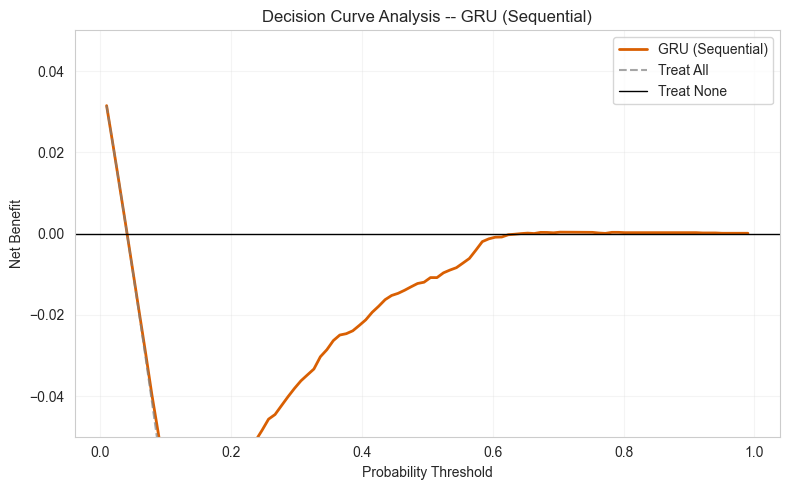

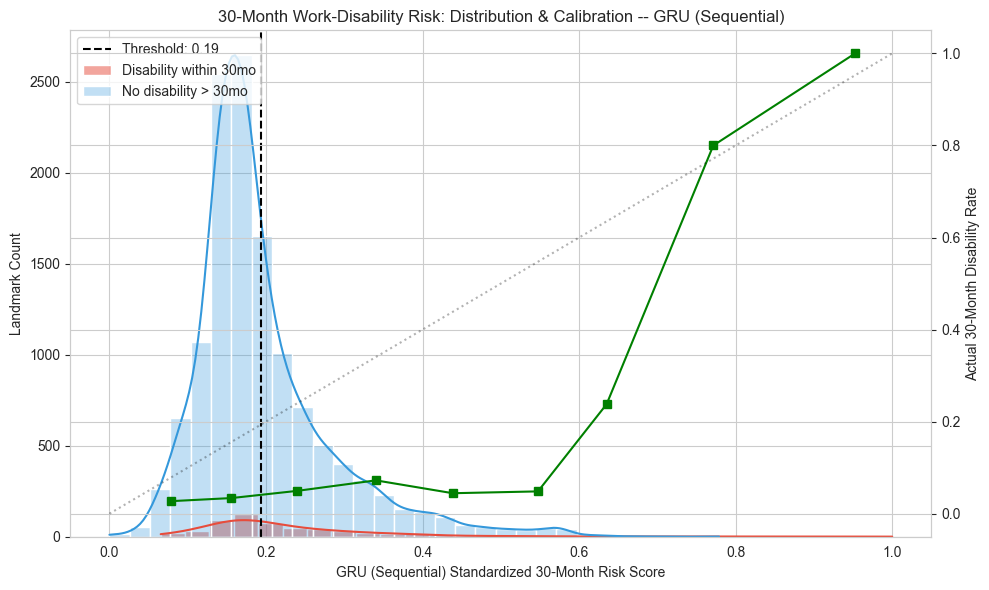

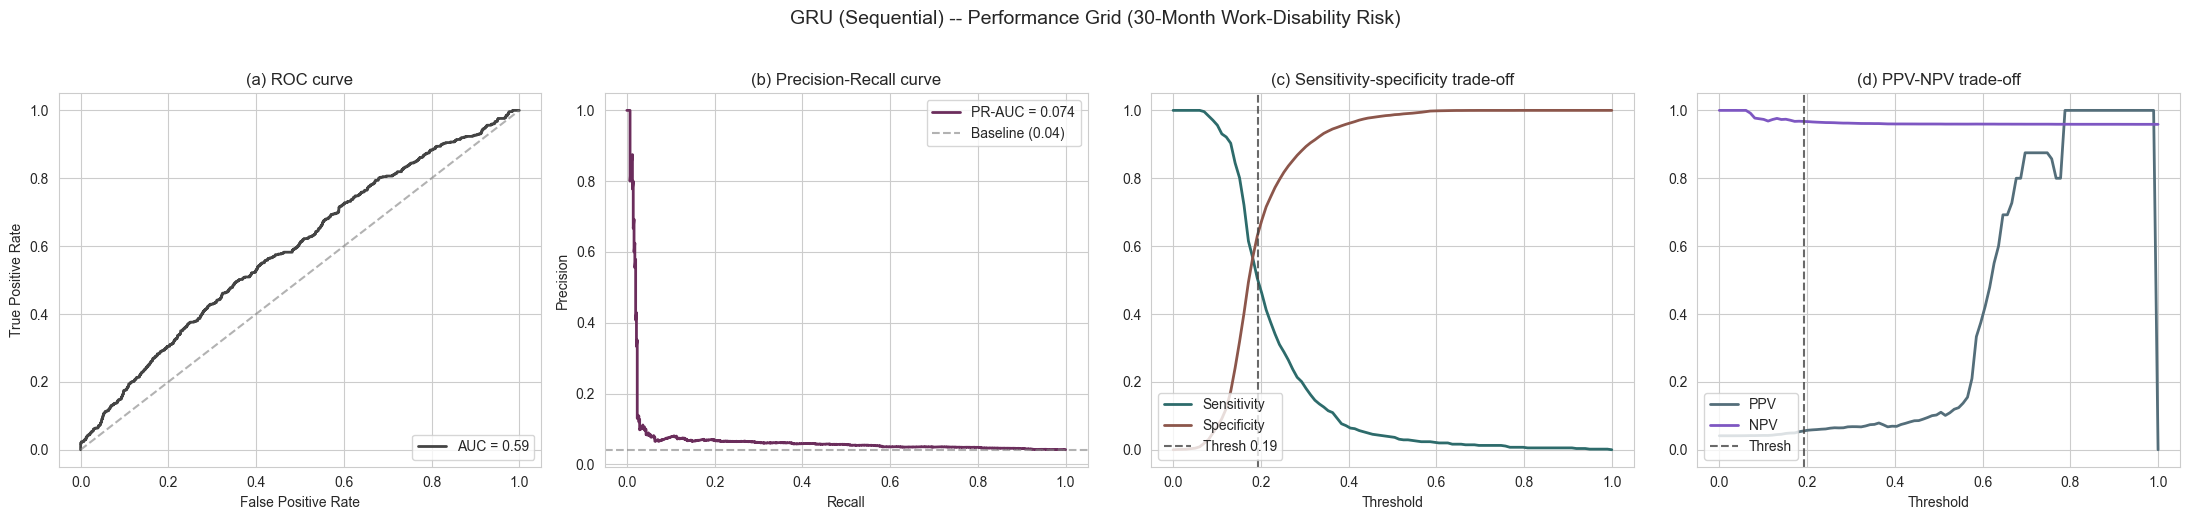

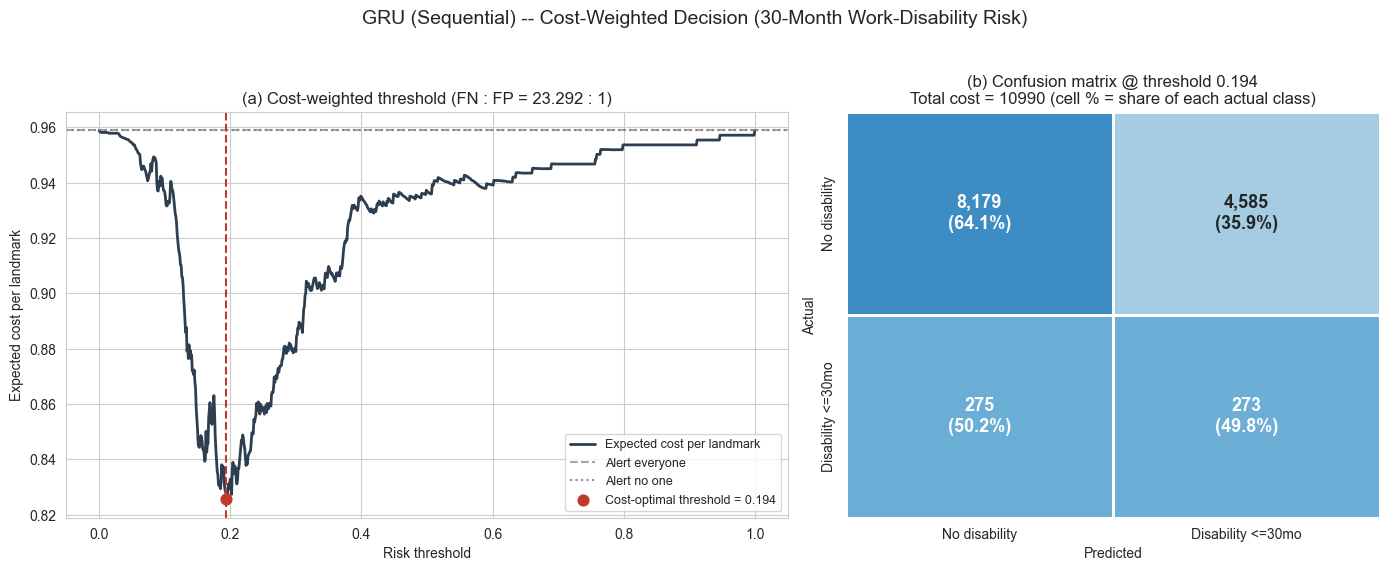


GRU (Sequential) (patient-level) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.5485     | Discrimination
Brier Score                    | 0.1736     | Overall accuracy (lower=better)
Calibration Slope              | 0.7499     | Ideal = 1.0
Calibration Intercept          | -0.0119     | Ideal = 0.0
Sensitivity                    | 0.8977     | [0.844, 0.934]
Specificity                    | 0.1557     | [0.131, 0.184]
PPV                            | 0.2079     | [0.181, 0.238]
NPV                            | 0.8605     | [0.790, 0.910]
Balanced Accuracy              | 0.5267     | [0.494, 0.559]

GRU -- PATIENT-LEVEL OPERATIONAL METRICS
----------------------------------------------------------------------
Patien

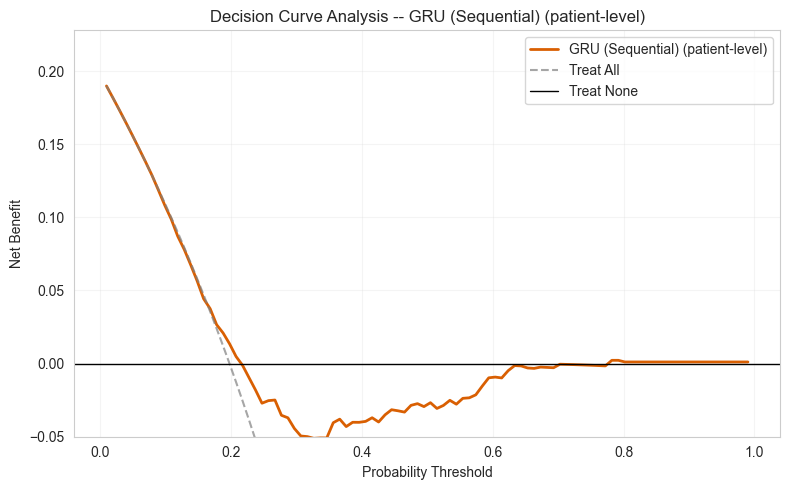

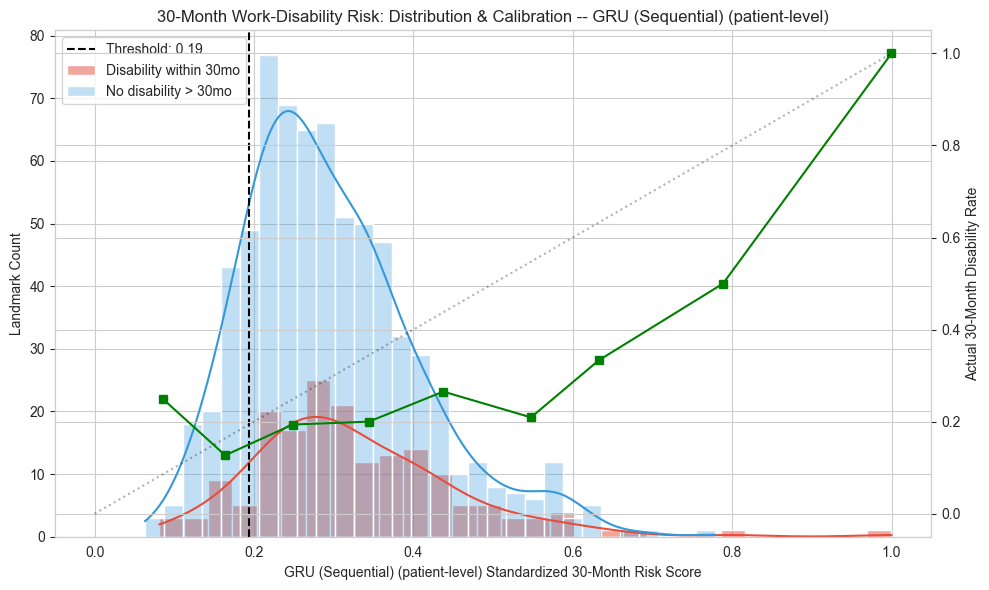

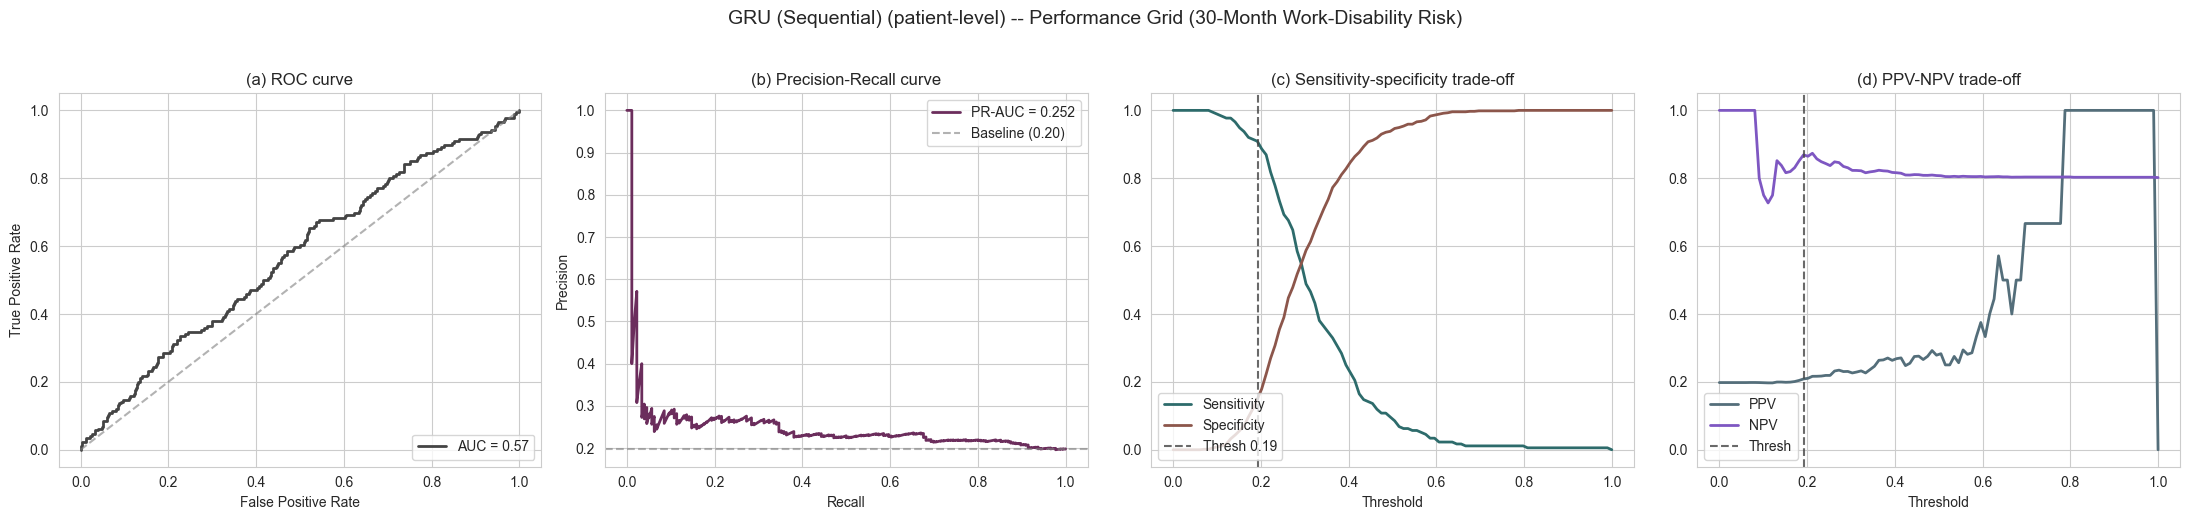

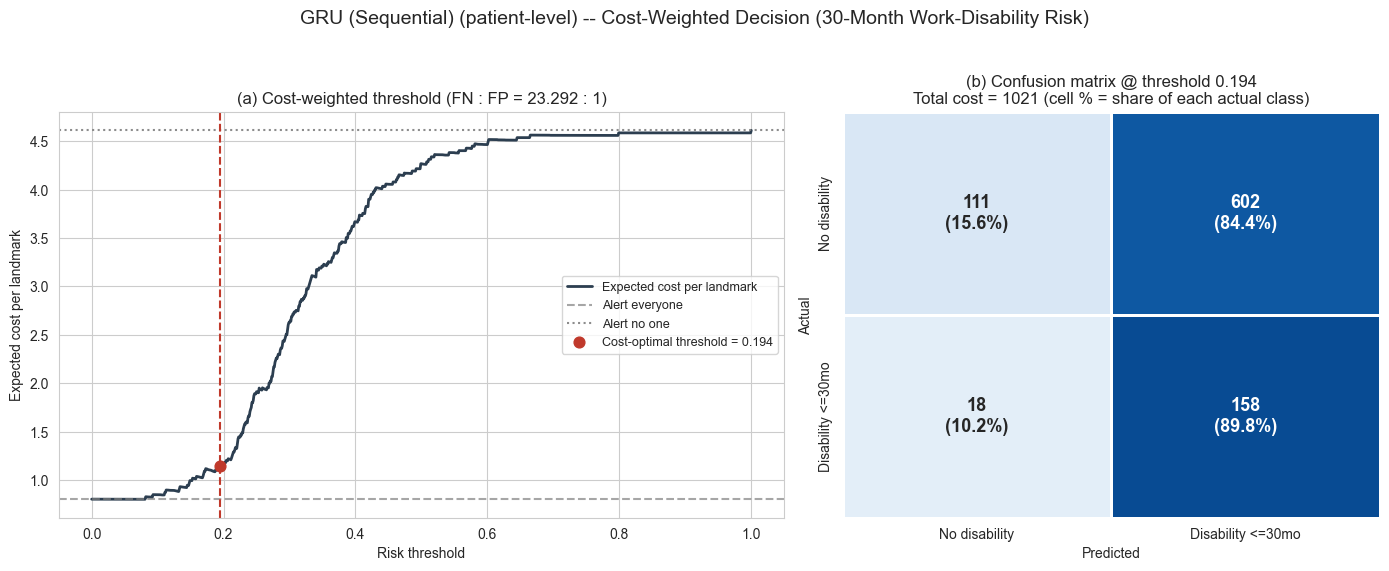

Fitting MICE imputer for GRU input sequences...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Training Survival GRU (final refit on all data)...
[GRU] Landmark sample prevalence: 4.1%  |  Calibration-fold prevalence: 4.1%  |  Target prevalence used: 4.1%


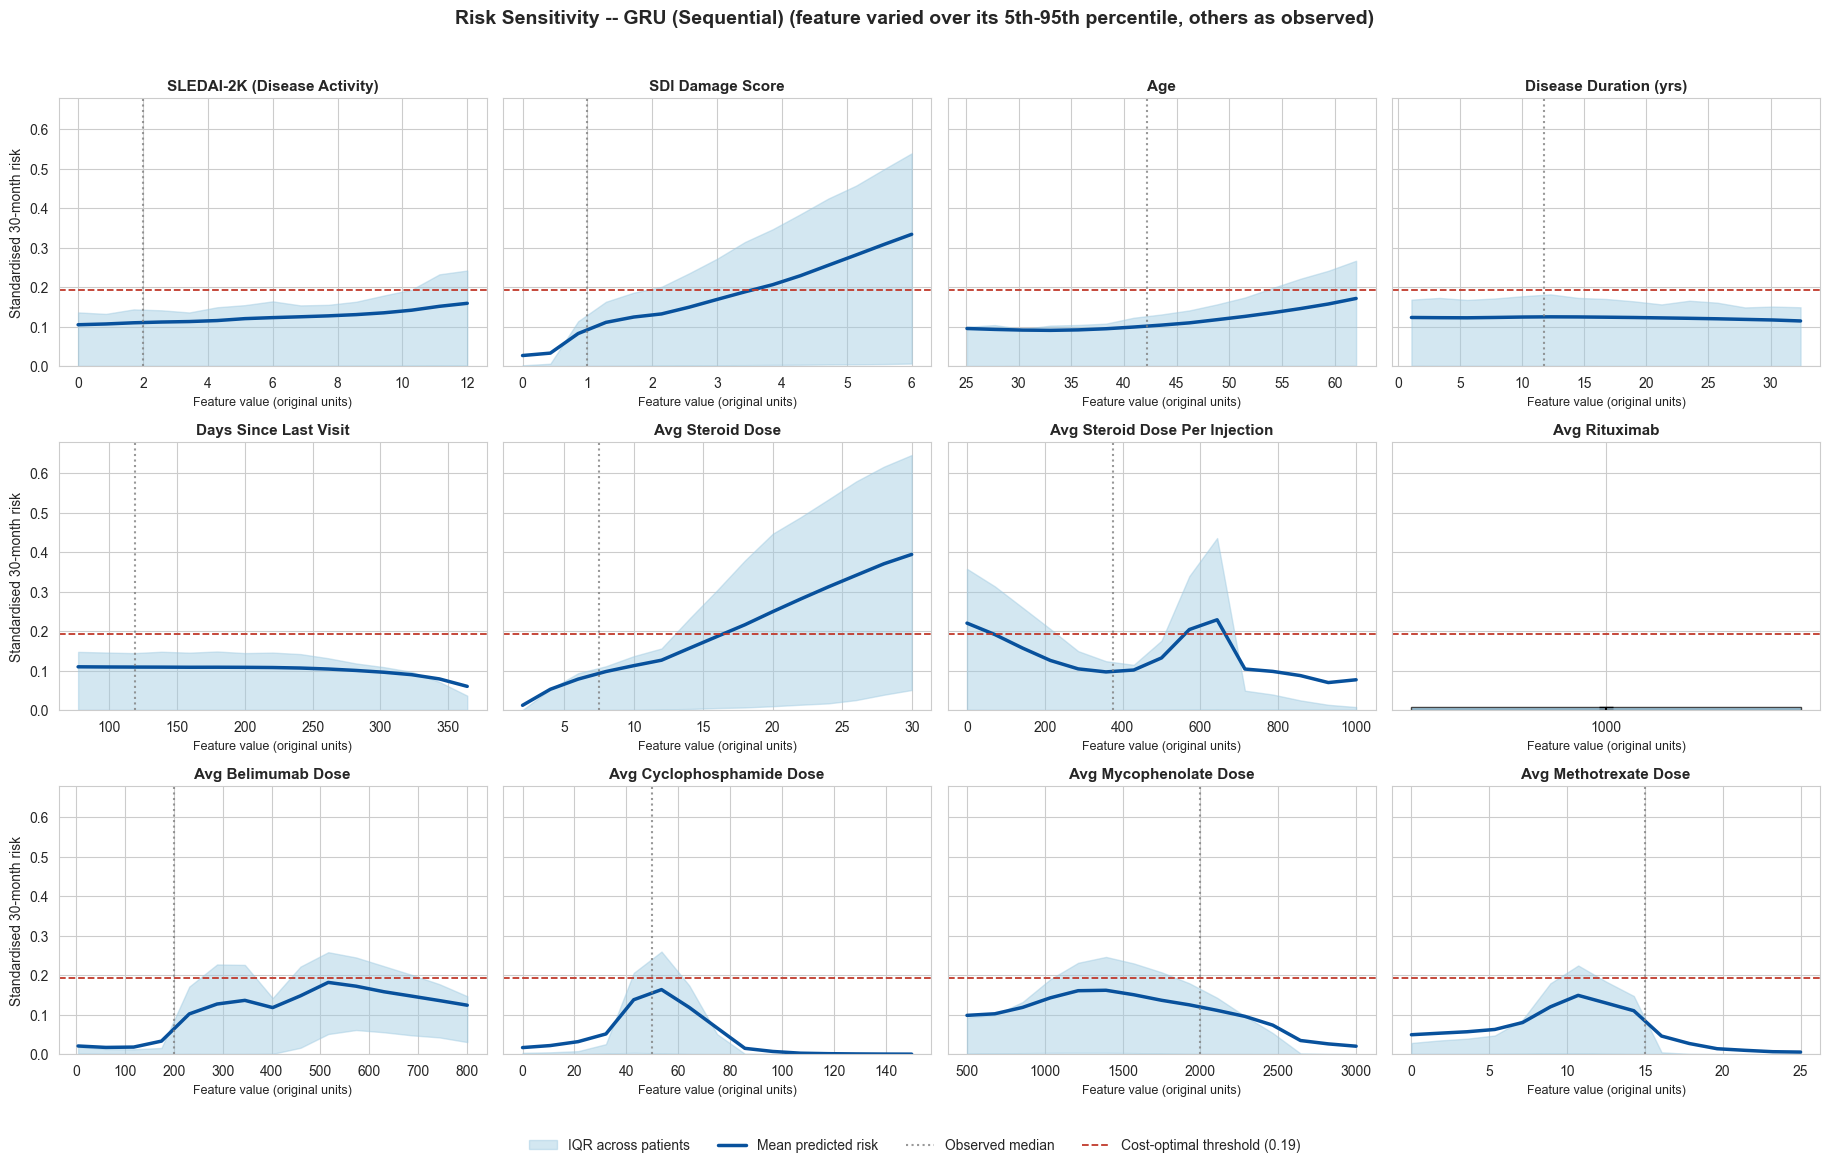


Risk-sensitivity summary -- GRU (Sequential) (mean standardised risk; ranked by swing)
                       Feature  Risk @ low value  Risk @ high value  Risk swing (max-min)
              Avg Steroid Dose             0.013              0.394                 0.382
              SDI Damage Score             0.027              0.334                 0.307
            Avg Belimumab Dose             0.021              0.124                 0.164
     Avg Cyclophosphamide Dose             0.017              0.000                 0.163
Avg Steroid Dose Per Injection             0.220              0.077                 0.159
         Avg Methotrexate Dose             0.049              0.006                 0.143
        Avg Mycophenolate Dose             0.098              0.020                 0.141
                           Age             0.096              0.172                 0.081
  SLEDAI-2K (Disease Activity)             0.105              0.159                 0.054
         Day

In [13]:
gru_pipeline = SequentialSurvivalRNN(cell='gru', horizon_days=HORIZON_DAYS)
res_gru = gru_pipeline.run_analysis(land, X_seq, epochs=25)


## Model 5/5 — Sequential LSTM

Resuming from cv_state.pkl: 99 model-fold fits already done.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[LSTM  ] repeat 1/5 fold 1/5 | C-index 0.542  AUROC 0.602  sens 1.00  spec 0.00  cost saving +0.0%  (91s)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[LSTM  ] repeat 1/5 fold 2/5 | C-index 0.521  AUROC 0.449  sens 0.40  spec 0.51  cost saving -24.6%  (97s)


...

[LSTM  ] repeat 5/5 fold 4/5 | C-index 0.608  AUROC 0.571  sens 0.39  spec 0.75  cost saving +6.4%  (88s)
[LSTM  ] repeat 5/5 fold 5/5 | C-index 0.618  AUROC 0.663  sens 0.23  spec 0.88  cost saving -7.4%  (84s)

Done in 36.8 min. 123 model-fold fits stored in cv_state.pkl. Folds skipped due to errors: {'LSTM': 1}.
LSTM -- REPEATED CV, HELD-OUT PERFORMANCE: mean (SD) over 24 test folds (5 repeats x 5 folds)
----------------------------------------------------------------------------------------------------


,Folds,Repeats,C-index,AUROC,PR-AUC,Brier,Cal. slope,Cal. intercept,Sensitivity,Specificity,PPV,NPV,Bal. Acc,Cost saving,Threshold,Sec/fit
Model,,,,,,,,,,,,,,,,
LSTM,24,5,0.539 (0.057),0.536 (0.088),0.057 (0.025),0.040 (0.005),-0.186 (4.465),-0.004 (0.145),0.448 (0.253),0.586 (0.277),0.050 (0.019),0.959 (0.014),0.517 (0.059),-0.053 (0.172),0.22 (0.28),91



Out-of-fold predictions pooled within each repeat, mean (SD) across repeats:


,Repeats,C-index,AUROC,PR-AUC,Brier,Cal. slope,Cal. intercept,Sensitivity,Specificity,PPV,NPV,Bal. Acc,Cost saving
Model,,,,,,,,,,,,,
LSTM,4,0.537 (0.036),0.544 (0.037),0.055 (0.009),0.039 (0.000),0.688 (0.556),-0.001 (0.009),0.460 (0.163),0.554 (0.229),0.044 (0.006),0.957 (0.011),0.507 (0.042),0.014 (0.085)



LSTM (Sequential), repeated CV -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.5698     | Discrimination
Brier Score                    | 0.0676     | Overall accuracy (lower=better)
Calibration Slope              | 0.7488     | Ideal = 1.0
Calibration Intercept          | -0.1871     | Ideal = 0.0
Sensitivity                    | 0.4909     | [0.449, 0.533]
Specificity                    | 0.6536     | [0.645, 0.662]
PPV                            | 0.0573     | [0.051, 0.064]
NPV                            | 0.9676     | [0.964, 0.971]
Balanced Accuracy              | 0.5722     | [0.564, 0.581]

LSTM (Sequential) -- OPERATIONAL / CLINICAL-BURDEN METRICS
-------------------------------------------------------------

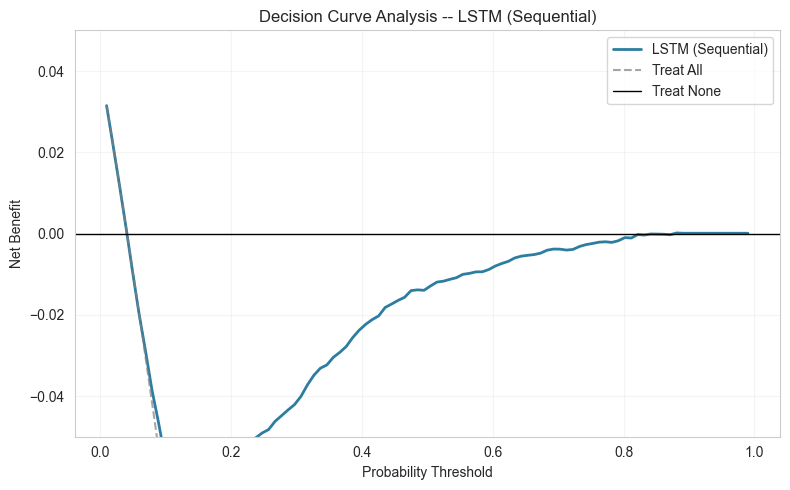

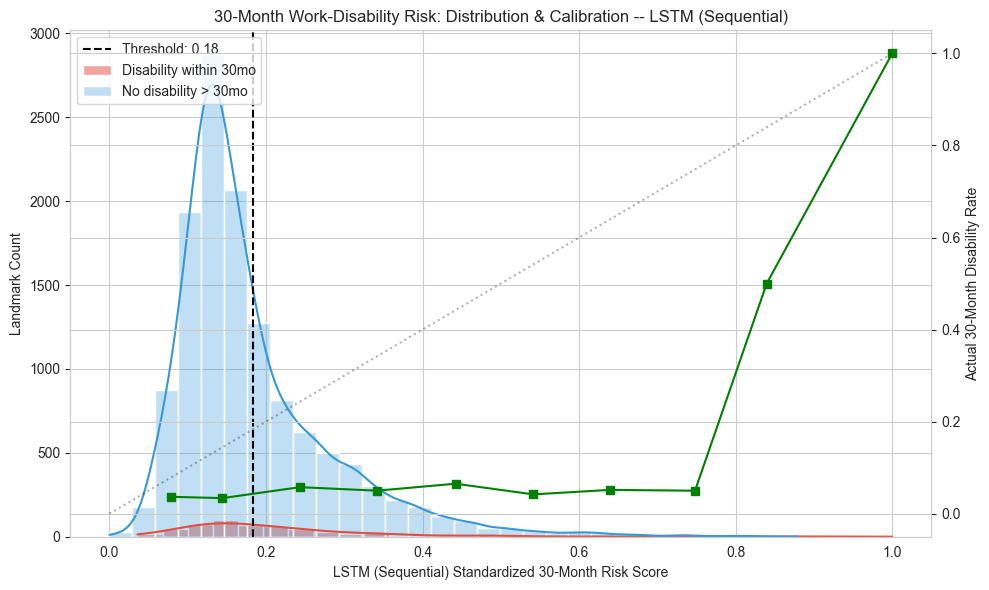

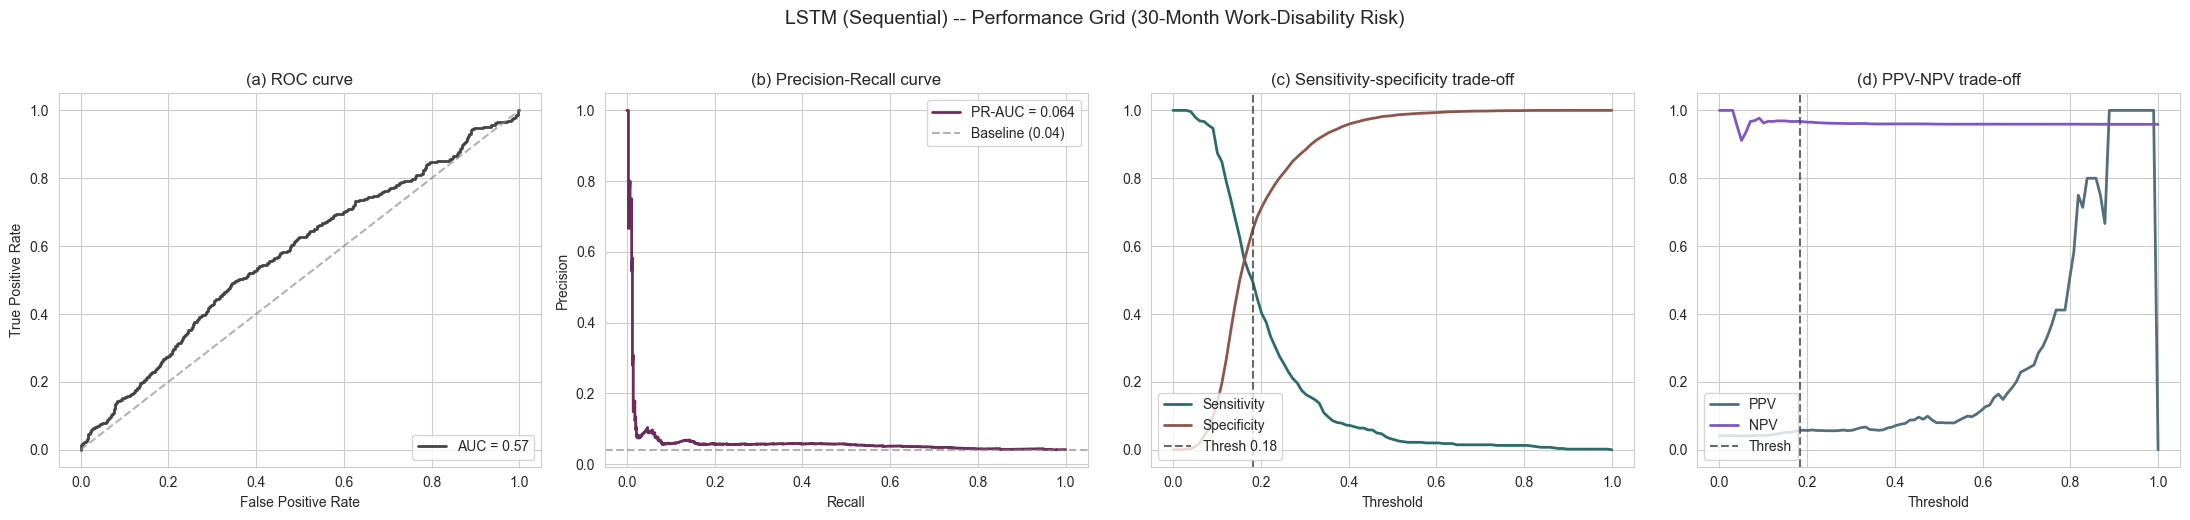

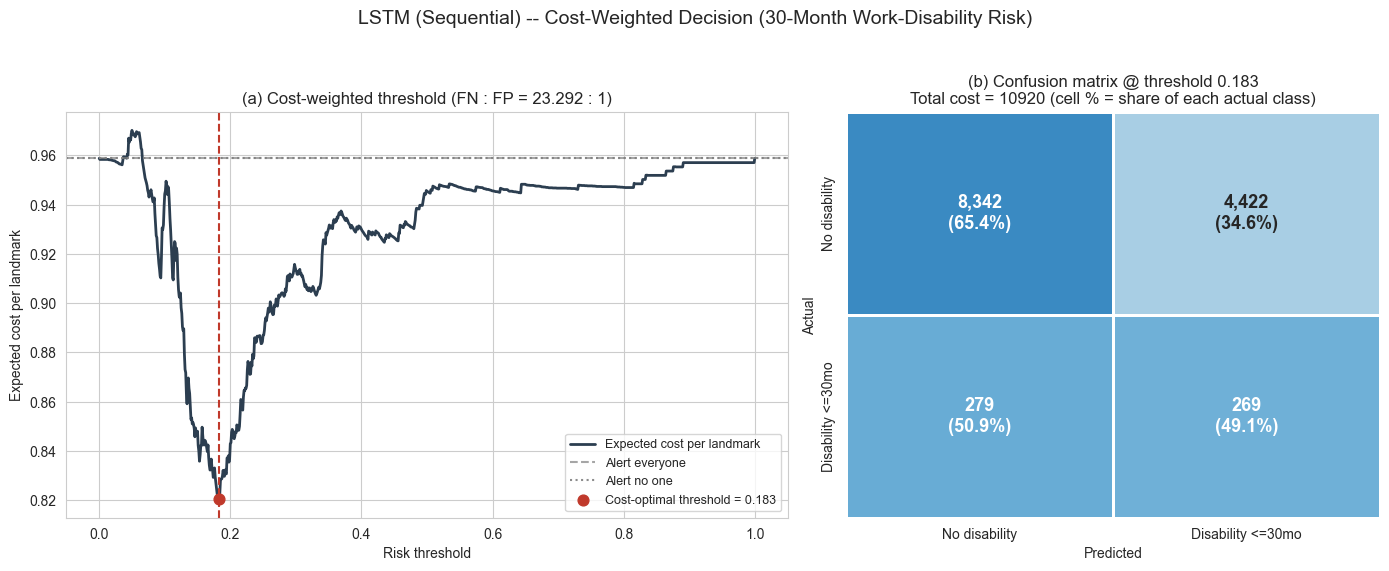


LSTM (Sequential) (patient-level) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.5374     | Discrimination
Brier Score                    | 0.1775     | Overall accuracy (lower=better)
Calibration Slope              | 0.5807     | Ideal = 1.0
Calibration Intercept          | -0.0011     | Ideal = 0.0
Sensitivity                    | 0.8636     | [0.805, 0.907]
Specificity                    | 0.2048     | [0.177, 0.236]
PPV                            | 0.2114     | [0.183, 0.243]
NPV                            | 0.8588     | [0.799, 0.903]
Balanced Accuracy              | 0.5342     | [0.501, 0.567]

LSTM -- PATIENT-LEVEL OPERATIONAL METRICS
----------------------------------------------------------------------
Pati

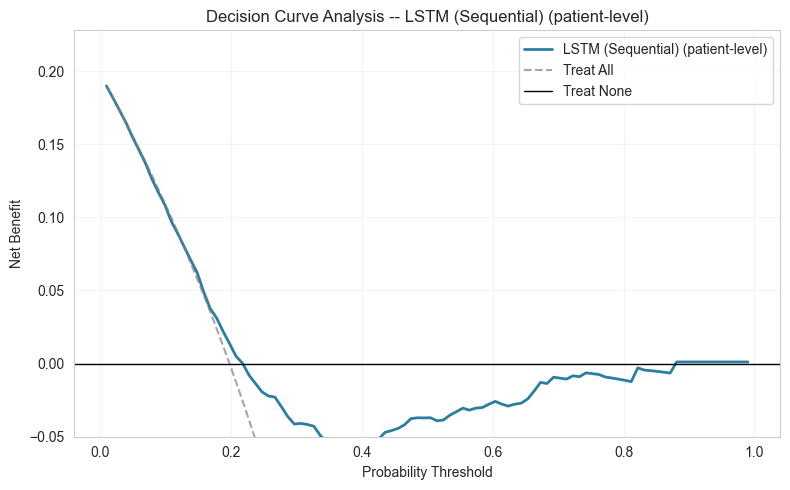

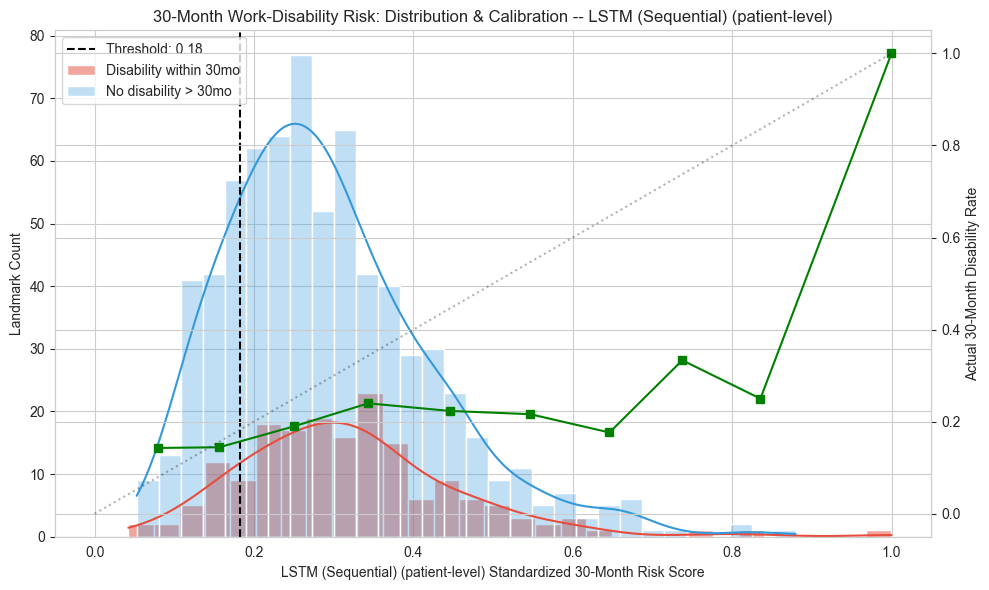

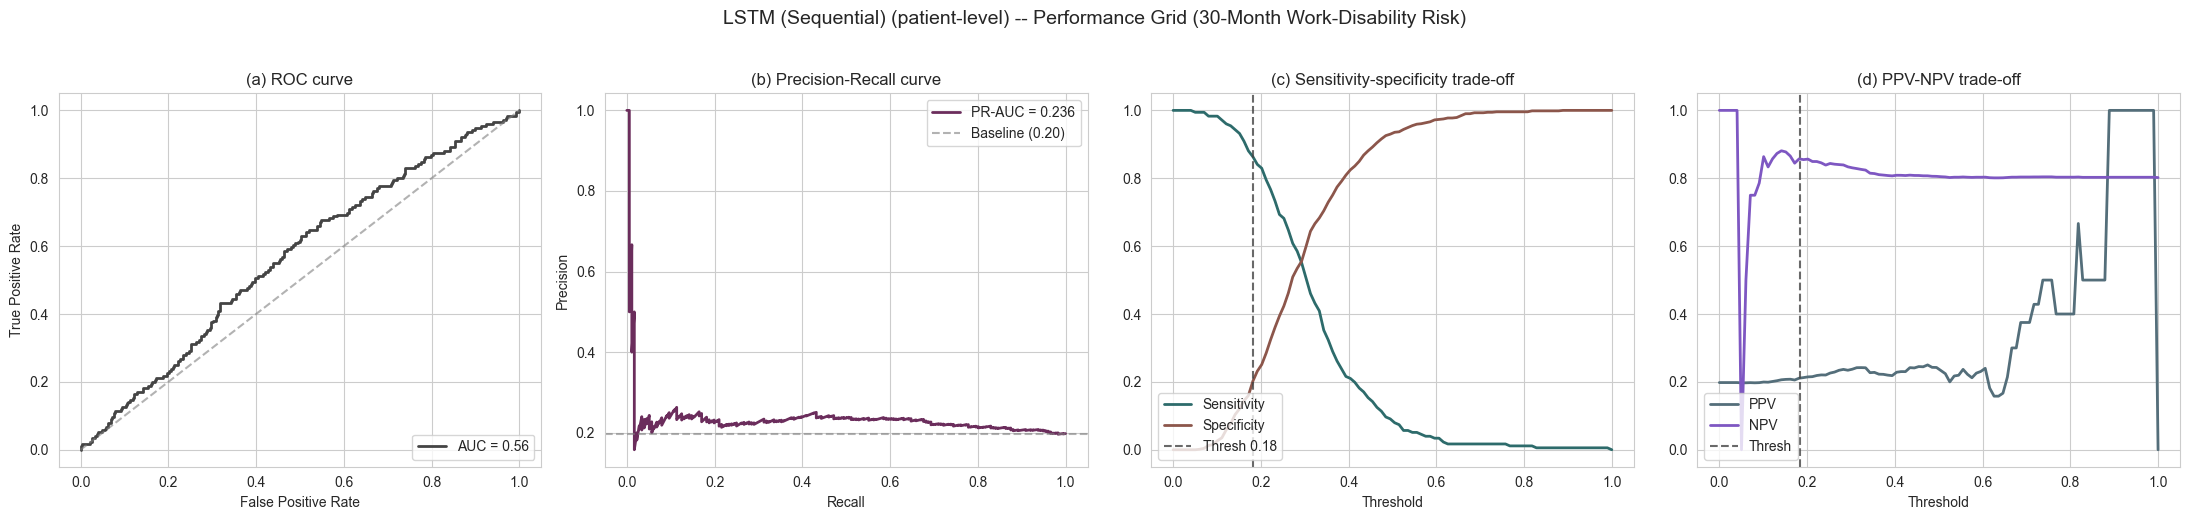

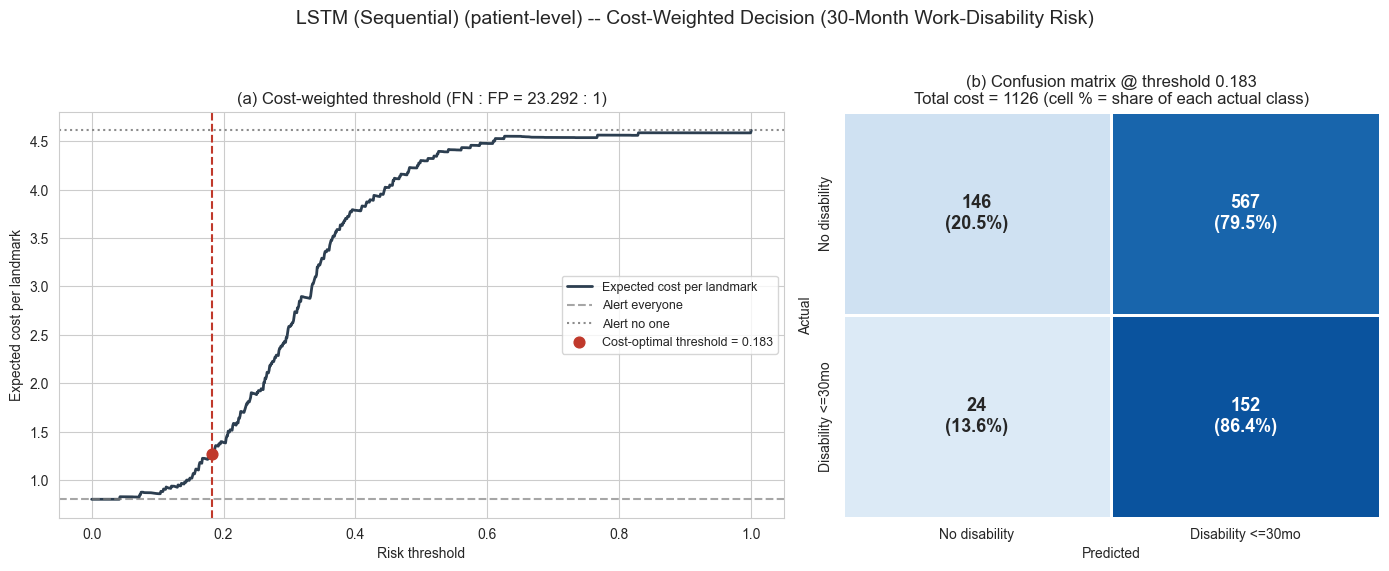

Fitting MICE imputer for LSTM input sequences...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Training Survival LSTM (final refit on all data)...


In [ ]:
lstm_pipeline = SequentialSurvivalRNN(cell='lstm', horizon_days=HORIZON_DAYS)
res_lstm = lstm_pipeline.run_analysis(land, X_seq, epochs=25)

In [ ]:
w_eff = land["weight"].values * np.where(land["label"]==1, 
        len(land)/(2*land["label"].sum()), len(land)/(2*(len(land)-land["label"].sum())))
print(pd.Series(w_eff).groupby(land["label"]).sum())

## Cross-Model Calibration Comparison

In [ ]:
"""Cross-model calibration comparison plot (mirrors the notebook's 'Plots'
cell), built here from each model's *actual* calibration-curve output on
the SLE landmark data rather than the original notebook's hard-coded demo
numbers."""
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.calibration import calibration_curve


def plot_calibration_comparison(results, save="figs/calibration_comparison.pdf"):
    """results: dict of {model_name: (y_true, risks)}"""
    bin_centers = np.linspace(0.05, 0.95, 10)

    plt.figure(figsize=(9, 9), facecolor="white")
    plt.plot([0, 1], [0, 1], linestyle="--", color="#7f8c8d",
              label="Perfect Calibration (Slope=1, Int=0)", alpha=0.8, lw=1.5)

    colors = ["#4a69bd", "#78a083", "#b33939", "#574b90", "#2f3542"]
    markers = ["P", "s", "o", "^", "D"]
    highlight = max(results, key=lambda k: results[k][2])  # highest c-index gets highlighted

    for (model_name, (y_true, risks, _)), color, marker in zip(results.items(), colors, markers):
        prob_true, prob_pred = calibration_curve(y_true, risks, n_bins=10)
        # align onto common bin centers via interpolation for a clean comparison line
        observed = np.interp(bin_centers, prob_pred, prob_true)
        slope, intercept, _, _, _ = stats.linregress(bin_centers, observed)
        label_text = f"{model_name}\n(Slope: {slope:.2f}, Int: {intercept:.2f})"

        is_highlight = model_name == highlight
        plt.plot(bin_centers, observed, marker=marker, label=label_text, color=color,
                  lw=3.5 if is_highlight else 2.5, markersize=9 if is_highlight else 6,
                  alpha=1.0 if is_highlight else 0.55,
                  zorder=10 if is_highlight else 5, markeredgecolor="white", markeredgewidth=0.5)

    plt.xlabel("Mean Predicted Probability (30-Month Work Disability)", fontsize=16, labelpad=10)
    plt.ylabel("Observed Proportion of Events", fontsize=16, labelpad=10)
    plt.legend(loc="upper left", fontsize=11, frameon=True, facecolor="white", framealpha=0.9)
    plt.grid(True, linestyle=":", alpha=0.4, color="#ced4da")
    plt.xlim([0, 1]); plt.ylim([0, 1])
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.title("Calibration Comparison Across Models")
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

all_results = {
    'LogReg': (res_logreg['y'], res_logreg['risks'], res_logreg['c_index']),
    'RSF': (res_rsf['y'], res_rsf['risks'], res_rsf['c_index']),
    'CoxPH': (res_cox['y'], res_cox['risks'], res_cox['c_index']),
    'GRU': (res_gru['y'], res_gru['risks'], res_gru['c_index']),
    'LSTM': (res_lstm['y'], res_lstm['risks'], res_lstm['c_index']),
}
plot_calibration_comparison(all_results)

## SHAP Dashboard

The original notebook's SHAP cell imports an external `grumodelwdashboard.py`
module that was not included in the uploaded files, so it could not be run
verbatim. This reproduces its intent directly against the best-discriminating
sequential model using the `shap` package: SHAP attribution is computed for
each landmark's most recent ("current-visit") feature vector, tiled across
the model's fixed 12-visit input window.


In [ ]:
"""SHAP explainability dashboard for the trained GRU sequential model.

The original notebook's SHAP/dashboard cell imports a separate, not-supplied
module (`grumodelwdashboard.py`) that is not part of this upload, so it
cannot be executed verbatim. This module reproduces its intent -- a SHAP
explanation layer on top of the best-performing sequential model -- using
the `shap` package directly against the trained GRU classifier from
model_sequential.py.

Because the classifier consumes a (patients, 12-visit, 8-feature) tensor,
SHAP attribution is computed for the "current visit" (the most recent,
last-timestep) feature vector: a background/foreground wrapper tiles each
candidate current-visit vector across the model's fixed sequence length so
that the model sees a constant short-term trajectory ending at that visit.
This is the standard simplification used to make a recurrent risk model
locally explainable at the point of a single clinical visit.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import torch



def run_shap_dashboard(pipeline, land, X_seq, n_background=100, n_explain=300, seed=240):
    rng = np.random.RandomState(seed)
    model = pipeline.model
    model.eval()
    seq_len = pipeline.sequence_length
    feature_names = [DISPLAY_NAMES.get(c, c) for c in pipeline.feature_cols]

    # Last-visit (current-state) feature vectors, in the *model's* scaled
    # space, for every landmark row.
    last_visit = X_seq[:, -1, :]  # already imputed+scaled inside prepare_data
    # Recompute scaled/imputed last-visit features the same way prepare_data does.
    X_full, y_true, weight = pipeline.prepare_data(land, X_seq)
    last_visit_scaled = X_full[:, -1, :]

    def predict_fn(current_visit_batch):
        current_visit_batch = np.asarray(current_visit_batch, dtype=np.float32)
        n = current_visit_batch.shape[0]
        seq = np.repeat(current_visit_batch[:, None, :], seq_len, axis=1)
        with torch.no_grad():
            out = model(torch.FloatTensor(seq)).numpy()
        return out[:, -1, 0]

    bg_idx = rng.choice(len(last_visit_scaled), size=min(n_background, len(last_visit_scaled)),
                         replace=False)
    background = last_visit_scaled[bg_idx]

    ex_idx = rng.choice(len(last_visit_scaled), size=min(n_explain, len(last_visit_scaled)),
                         replace=False)
    explain_set = last_visit_scaled[ex_idx]

    print("Computing SHAP values (KernelExplainer over the last-visit state)...")
    masker = shap.maskers.Independent(background, max_samples=len(background))
    explainer = shap.Explainer(predict_fn, masker, feature_names=feature_names)
    shap_values = explainer(explain_set)

    # --- Summary (beeswarm) plot ---
    plt.figure()
    shap.plots.beeswarm(shap_values, show=False, max_display=len(feature_names))
    plt.title("SHAP Summary -- GRU 30-Month Work-Disability Risk")
    plt.tight_layout()
    plt.savefig("figs/shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # --- Mean |SHAP| bar plot ---
    plt.figure()
    shap.plots.bar(shap_values, show=False, max_display=len(feature_names))
    plt.title("Mean |SHAP value| -- GRU 30-Month Work-Disability Risk")
    plt.tight_layout()
    plt.savefig("figs/shap_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # --- Individual waterfall plots for a high-risk and a low-risk patient ---
    preds = predict_fn(explain_set)
    hi = int(np.argmax(preds))
    lo = int(np.argmin(preds))
    for label, idx in [("highest-risk", hi), ("lowest-risk", lo)]:
        plt.figure()
        shap.plots.waterfall(shap_values[idx], show=False)
        plt.title(f"SHAP Waterfall -- {label} landmark (pred={preds[idx]:.3f})")
        plt.tight_layout()
        plt.savefig(f"figs/shap_waterfall_{label.replace('-', '_')}.png", dpi=150,
                     bbox_inches="tight")
        plt.show()
        plt.close()

    mean_abs = np.abs(shap_values.values).mean(axis=0)
    imp_df = pd.DataFrame({"Feature": feature_names, "Mean |SHAP|": mean_abs}) \
        .sort_values("Mean |SHAP|", ascending=False)
    print("\n" + "=" * 55)
    print("SHAP FEATURE IMPORTANCE (mean |SHAP| over sampled landmarks)")
    print("-" * 55)
    print(imp_df.to_string(index=False))
    print("=" * 55)

    return shap_values, imp_df

best_name = max(all_results, key=lambda k: all_results[k][2])
print(f'Best model by C-index: {best_name} ({all_results[best_name][2]:.4f})')
shap_pipeline = lstm_pipeline if best_name == 'LSTM' else gru_pipeline
shap_values, shap_imp = run_shap_dashboard(shap_pipeline, land, X_seq,
                                            n_background=100, n_explain=300)

## Summary — All Models

In [ ]:
"""
Comprehensive Model Comparison & LaTeX Table Generator
Extracts metrics directly from trained model results with bootstrap standard errors,
automatically identifies top performers for bolding, and exports LaTeX tabular code.
"""
import numpy as np
import pandas as pd
from lifelines.utils import concordance_index
from sklearn.metrics import confusion_matrix

# 1. Map models to their result dictionaries
models = {
    "CoxPH": res_cox,
    "LR":    res_logreg,
    "RSF":   res_rsf,
    "GRU":   res_gru,
    "LSTM":  res_lstm,
}

# 2. Extract shared survival targets from the landmark dataset
durations = land["duration"].values.astype(float)
events = land["event"].values.astype(int)
n_samples = len(durations)

# 3. Helper to compute binary classification metrics
def compute_binary_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    bal_acc = 0.5 * (sens + spec)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    return {
        "Sensitivity": sens,
        "Specificity": spec,
        "Bal. Acc": bal_acc,
        "PPV": ppv,
        "NPV": npv,
    }

# 4. Bootstrap routine to calculate mean/point estimates and standard deviations
N_BOOT = 500
RNG_SEED = 240
rng = np.random.RandomState(RNG_SEED)

metric_names = ["C-Index", "Sensitivity", "Specificity", "Bal. Acc", "PPV", "NPV"]
table_data = {}

print(f"Calculating point estimates and bootstrap SEs ({N_BOOT} iterations)...")

for name, res in models.items():
    risks = np.asarray(res["risks"], dtype=float)
    y_true = np.asarray(res["y"], dtype=int)
    threshold = float(res["best_t"])
    y_pred = (risks >= threshold).astype(int)

    # Point estimates on full landmark sample
    c_pt = concordance_index(durations, -risks, events)
    bin_pt = compute_binary_metrics(y_true, y_pred)
    point_estimates = {"C-Index": c_pt, **bin_pt}

    # Bootstrap distributions
    boot_metrics = {m: [] for m in metric_names}
    for _ in range(N_BOOT):
        boot_idx = rng.choice(n_samples, size=n_samples, replace=True)
        dur_b, ev_b = durations[boot_idx], events[boot_idx]
        y_b, risk_b = y_true[boot_idx], risks[boot_idx]
        pred_b = (risk_b >= threshold).astype(int)

        try:
            boot_metrics["C-Index"].append(concordance_index(dur_b, -risk_b, ev_b))
        except (ZeroDivisionError, ValueError):
            pass

        b_bin = compute_binary_metrics(y_b, pred_b)
        for k in b_bin:
            boot_metrics[k].append(b_bin[k])

    # Store point estimates and standard deviations
    stats_dict = {}
    for m in metric_names:
        pt = point_estimates[m]
        std = np.nanstd(boot_metrics[m])
        stats_dict[m] = (pt, std)
    
    stats_dict["Threshold"] = threshold
    table_data[name] = stats_dict

# 5. Identify maximum values across models for automatic bolding
max_values = {
    m: max(table_data[model][m][0] for model in table_data)
    for m in metric_names
}

# 6. Construct formatted rows for LaTeX and Pandas
latex_rows = []
df_display_rows = []

for model_name, metrics in table_data.items():
    latex_row = [f"{model_name:<5}"]
    df_row = {"Model": model_name}

    for m in metric_names:
        val, std = metrics[m]
        cell_str = f"{val:.2f} ({std:.2f})"
        
        # Bold if within 0.005 of max to account for rounding/ties
        is_best = (val >= max_values[m] - 0.005)
        
        latex_cell = f"\\textbf{{{cell_str}}}" if is_best else cell_str
        latex_row.append(latex_cell)
        
        df_row[m] = f"**{cell_str}**" if is_best else cell_str

    thresh_str = f"{metrics['Threshold']:.2f}"
    latex_row.append(thresh_str)
    df_row["Threshold"] = thresh_str

    latex_rows.append(" & ".join(latex_row) + " \\\\")
    df_display_rows.append(df_row)
    


# 9. Return interactive summary dataframe
summary_df = pd.DataFrame(df_display_rows)
summary_df

Model	C-Index	Sensitivity	Specificity	Bal. Acc	PPV	NPV	Threshold
0	CoxPH	0.60 (0.01)	0.67 (0.02)	0.55 (0.01)	0.61 (0.01)	0.23 (0.01)	0.89 (0.01)	0.57
1	LR	0.61 (0.01)	0.67 (0.02)	0.58 (0.01)	0.63 (0.01)	0.24 (0.01)	0.90 (0.01)	0.52
2	RSF	0.75 (0.01)	0.71 (0.02)	0.73 (0.01)	0.72 (0.01)	0.35 (0.01)	0.93 (0.01)	0.39
3	GRU	0.80 (0.01)	0.80 (0.02)	**0.83 (0.01)**	0.81 (0.01)	0.48 (0.01)	0.95 (0.00)	0.64
4	LSTM	**0.81 (0.01)**	**0.89 (0.01)**	**0.82 (0.01)**	**0.86 (0.01)**	**0.50 (0.01)**	**0.97 (0.00)**	0.5

## LSTM Landmark Sensitivity Analysis (6–48 Months)

Re-runs **only the sequential LSTM pipeline** (`SequentialSurvivalRNN`,
`cell='lstm'`) at a grid of prediction horizons ("landmarks"): 6, 12, 18, 24,
30, 36, 42 and 48 months, in 6-month steps.

At each landmark the landmark-building step (`build_landmark_dataset`) is
re-run with that landmark's `horizon_days`, but the **censoring trims are left
unchanged**: `DEATH_TRIM_DAYS` (12 months) and `ADMIN_TRIM_DAYS` are the same
module-level constants used inside `_plan_patient` for every horizon below, so
only the outcome window moves -- the death/administrative-exit censoring rule
does not. A fresh LSTM (new weights, same architecture, training recipe and
random seed as the Model 5/5 cell above) is trained at every landmark, since
the labels, durations and landmark rows themselves are horizon-specific.

The cells below report, for each landmark: discrimination (C-index),
calibration (slope, intercept, Brier score, reliability curve), and the usual
binary-classification metrics at the cost-optimal threshold -- in a summary
table (bootstrap SEs, same methodology as the "Comprehensive Model
Comparison" table above) and in trend / calibration-curve plots.

In [ ]:
"""
=============================================================================
LSTM LANDMARK SENSITIVITY -- TRAINING LOOP (6 TO 48 MONTHS, 6-MONTH STEPS)
=============================================================================
Rebuilds the landmark dataset at each horizon and trains a fresh LSTM with
the identical architecture / training recipe used by the main Model 5/5 cell
(`SequentialSurvivalRNN(cell="lstm")`), just without that cell's per-model
plotting so the loop output stays readable across 8 horizons. The death
(`DEATH_TRIM_DAYS`) and administrative-exit (`ADMIN_TRIM_DAYS`) censoring
trims are module-level constants used unconditionally by `_plan_patient`, so
they are identical at every landmark below -- only `horizon_days` changes.
"""
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from lifelines.utils import concordance_index

LANDMARK_MONTHS = list(range(12, 49, 6))   # 12, 18, 24, 30, 36, 42, 48
LANDMARK_EPOCHS = 25                       # same as the main LSTM cell (Model 5/5)
LANDMARK_SEED = 240                        # same seed as the main LSTM cell


def _months_to_days(m):
    return round(m * 365.25 / 12)


def train_lstm_at_landmark(horizon_months, epochs=LANDMARK_EPOCHS, seed=LANDMARK_SEED, verbose=False):
    """Rebuild the landmark set at `horizon_months` (same death/admin censoring
    trims as the main pipeline) and train a fresh LSTM exactly as the Model
    5/5 cell does (same balanced-minibatch BCE training loop), returning the
    trained pipeline plus risks/labels for downstream reporting."""
    horizon_days = _months_to_days(horizon_months)
    land_h, X_seq_h = build_landmark_dataset(
        horizon_days=horizon_days, verbose=verbose,
        with_sequences=True, sequence_length=12,
        require_continuous_employment=True)

    pipeline = SequentialSurvivalRNN(cell="lstm", horizon_days=horizon_days, seed=seed)
    X, y_true, weight = pipeline.prepare_data(land_h, X_seq_h)
    model = pipeline._build_classifier()
    opt = optim.Adam(model.parameters(), lr=1e-3)
    bce = nn.BCELoss()

    gen = pipeline._balanced_batch(X, y_true, weight, 32)
    spe = max(1, len(X) // 32)
    model.train()
    for _ep in range(epochs):
        for _ in range(spe):
            xb, yb = next(gen)
            xb_t = torch.FloatTensor(xb)
            yb_t = torch.FloatTensor(yb).view(-1, 1, 1).repeat(1, pipeline.sequence_length, 1)
            opt.zero_grad()
            pred = model(xb_t)
            loss = bce(pred, yb_t)
            loss.backward()
            opt.step()
    pipeline.model = model

    model.eval()
    with torch.no_grad():
        raw_preds = model(torch.FloatTensor(X)).numpy()
    visit_risks_raw = raw_preds[:, -1, 0]
    visit_risks = pipeline.final_scaler.fit_transform(visit_risks_raw.reshape(-1, 1)).flatten()
    visit_risks = np.clip(visit_risks, 1e-5, 1 - 1e-5)

    duration = land_h["duration"].values
    event = land_h["event"].values
    c_val = concordance_index(duration, 1 - visit_risks, event)
    best_t = find_cost_optimal_threshold(y_true, visit_risks)
    y_pred = (visit_risks >= best_t).astype(int)

    return {"horizon_months": horizon_months, "horizon_days": horizon_days,
            "pipeline": pipeline, "land": land_h, "risks": visit_risks,
            "y": y_true, "y_pred": y_pred, "c_index": c_val, "best_t": best_t}


print(f"Re-training the LSTM at {len(LANDMARK_MONTHS)} landmarks: {LANDMARK_MONTHS} months "
      f"(censoring trims unchanged: death={DEATH_TRIM_DAYS}d, admin exit={ADMIN_TRIM_DAYS}d)\n")

landmark_results = {}
for _m in LANDMARK_MONTHS:
    print(f"--- Landmark: {_m} months ({_months_to_days(_m)} days) ---")
    landmark_results[_m] = train_lstm_at_landmark(_m)
    _r = landmark_results[_m]
    print(f"    n={len(_r['y'])}, events={int(_r['y'].sum())} ({_r['y'].mean():.1%}), "
          f"C-index={_r['c_index']:.3f}, cost-optimal threshold={_r['best_t']:.3f}\n")


In [ ]:
"""
Comparison table across LSTM landmarks -- same bootstrap-SE methodology as
the "Comprehensive Model Comparison" cell above (point estimate + bootstrap
standard deviation over 500 resamples), extended with calibration slope,
calibration intercept and Brier score so discrimination AND calibration can
both be read off directly for each landmark.
"""
import numpy as np
import pandas as pd
from lifelines.utils import concordance_index
from sklearn.metrics import confusion_matrix, brier_score_loss


def _compute_binary_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    bal_acc = 0.5 * (sens + spec)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    return {"Sensitivity": sens, "Specificity": spec, "Bal. Acc": bal_acc, "PPV": ppv, "NPV": npv}


N_BOOT_LANDMARK = 500
RNG_SEED_LANDMARK = 240
metric_names_lm = ["C-Index", "Sensitivity", "Specificity", "Bal. Acc", "PPV", "NPV",
                    "Brier", "Cal. Slope", "Cal. Intercept"]

landmark_table_rows = []
calibration_curves_by_landmark = {}

print(f"Calculating point estimates and bootstrap SEs ({N_BOOT_LANDMARK} iterations per landmark)...")

for _m in LANDMARK_MONTHS:
    _res = landmark_results[_m]
    land_h = _res["land"]
    risks = np.asarray(_res["risks"], dtype=float)
    y_true = np.asarray(_res["y"], dtype=int)
    threshold = float(_res["best_t"])
    y_pred = (risks >= threshold).astype(int)
    durations = land_h["duration"].values.astype(float)
    events = land_h["event"].values.astype(int)
    n_samples = len(durations)

    c_pt = _res["c_index"]
    bin_pt = _compute_binary_metrics(y_true, y_pred)
    slope, intercept, r2, prob_true, prob_pred = calibration_stats(y_true, risks)
    brier_pt = brier_score_loss(y_true, risks)
    calibration_curves_by_landmark[_m] = {"prob_true": prob_true, "prob_pred": prob_pred,
                                           "n": n_samples, "event_rate": y_true.mean()}

    point_estimates = {"C-Index": c_pt, **bin_pt, "Brier": brier_pt,
                        "Cal. Slope": slope, "Cal. Intercept": intercept}

    rng = np.random.RandomState(RNG_SEED_LANDMARK)
    boot_metrics = {mm: [] for mm in metric_names_lm}
    for _ in range(N_BOOT_LANDMARK):
        boot_idx = rng.choice(n_samples, size=n_samples, replace=True)
        dur_b, ev_b = durations[boot_idx], events[boot_idx]
        y_b, risk_b = y_true[boot_idx], risks[boot_idx]
        pred_b = (risk_b >= threshold).astype(int)
        try:
            boot_metrics["C-Index"].append(concordance_index(dur_b, -risk_b, ev_b))
        except (ZeroDivisionError, ValueError):
            pass
        b_bin = _compute_binary_metrics(y_b, pred_b)
        for k in b_bin:
            boot_metrics[k].append(b_bin[k])
        try:
            boot_metrics["Brier"].append(brier_score_loss(y_b, risk_b))
        except ValueError:
            pass
        try:
            if len(np.unique(y_b)) > 1:
                s_b, i_b, _, _, _ = calibration_stats(y_b, risk_b)
                boot_metrics["Cal. Slope"].append(s_b)
                boot_metrics["Cal. Intercept"].append(i_b)
        except Exception:
            pass

    row = {"Landmark (mo)": _m, "N": n_samples, "Events": int(y_true.sum()),
           "Event rate": y_true.mean(), "Threshold": threshold}
    for mm in metric_names_lm:
        pt = point_estimates[mm]
        std = np.nanstd(boot_metrics[mm]) if len(boot_metrics[mm]) else np.nan
        row[mm] = pt
        row[f"{mm} SE"] = std
    landmark_table_rows.append(row)

landmark_summary_df = pd.DataFrame(landmark_table_rows)

# Display-formatted version: "value (SE)" per metric, mirroring the all-model table above
_display_rows = []
for row in landmark_table_rows:
    d = {"Landmark (mo)": int(row["Landmark (mo)"]), "N": row["N"], "Events": row["Events"],
         "Event rate": f"{row['Event rate']:.1%}", "Threshold": f"{row['Threshold']:.2f}"}
    for mm in metric_names_lm:
        d[mm] = f"{row[mm]:.3f} ({row[f'{mm} SE']:.3f})"
    _display_rows.append(d)
landmark_summary_display = pd.DataFrame(_display_rows)
landmark_summary_display


In [ ]:
"""
Trend plots: how LSTM discrimination (C-index) and calibration (slope,
intercept, Brier score) move across the 6-48 month landmarks.
"""
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
xs = landmark_summary_df["Landmark (mo)"].values

ax = axes[0]
ax.errorbar(xs, landmark_summary_df["C-Index"], yerr=landmark_summary_df["C-Index SE"],
            fmt="o-", color="#2c7da0", capsize=4, lw=2, label="LSTM C-index")
ax.axhline(0.5, color="gray", ls="--", alpha=0.6, label="Chance (0.5)")
ax.set_xlabel("Landmark horizon (months)")
ax.set_ylabel("Concordance index")
ax.set_title("(a) Discrimination vs. landmark")
ax.set_xticks(xs)
ax.legend(fontsize=9)

ax = axes[1]
ax.errorbar(xs, landmark_summary_df["Cal. Slope"], yerr=landmark_summary_df["Cal. Slope SE"],
            fmt="o-", color="#c0392b", capsize=4, lw=2, label="Calibration slope")
ax.axhline(1.0, color="gray", ls="--", alpha=0.6, label="Ideal slope = 1")
ax.set_xlabel("Landmark horizon (months)")
ax.set_ylabel("Calibration slope")
ax.set_title("(b) Calibration slope vs. landmark")
ax.set_xticks(xs)
ax.legend(fontsize=9)

ax = axes[2]
ax.errorbar(xs, landmark_summary_df["Cal. Intercept"], yerr=landmark_summary_df["Cal. Intercept SE"],
            fmt="o-", color="#7e57c2", capsize=4, lw=2, label="Calibration intercept")
ax.axhline(0.0, color="gray", ls="--", alpha=0.6, label="Ideal intercept = 0")
ax2 = ax.twinx()
ax2.plot(xs, landmark_summary_df["Brier"], "s--", color="#2d6b2d", lw=1.5, label="Brier score")
ax2.set_ylabel("Brier score", color="#2d6b2d")
ax.set_xlabel("Landmark horizon (months)")
ax.set_ylabel("Calibration intercept")
ax.set_title("(c) Calibration intercept & Brier score vs. landmark")
ax.set_xticks(xs)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=9, loc="best")

plt.suptitle("LSTM (Sequential) \u2014 Discrimination & Calibration Across Landmarks (6\u201348 Months)",
             y=1.04, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
plt.close()


In [ ]:
"""
Small-multiples reliability (calibration) plot: one panel per landmark, each
showing the observed vs. predicted event rate in 10 risk bins -- the same
`calibration_curve` construction used by `plot_risk_distribution_and_calibration`
above, just laid out side-by-side across horizons for direct comparison.
"""
import numpy as np
import matplotlib.pyplot as plt

ncols = 4
nrows = int(np.ceil(len(LANDMARK_MONTHS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.2 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, _m in zip(axes, LANDMARK_MONTHS):
    c = calibration_curves_by_landmark[_m]
    ax.plot(c["prob_pred"], c["prob_true"], "s-", color="#2c7da0", lw=2, label="Observed")
    ax.plot([0, 1], [0, 1], "k:", alpha=0.4, label="Ideal")
    ax.set_title(f"{_m} mo  (n={c['n']}, events={c['event_rate']:.1%})", fontsize=10, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

for ax in axes[len(LANDMARK_MONTHS):]:
    ax.set_visible(False)
for r in range(nrows):
    axes[r * ncols].set_ylabel("Observed event rate")
for c_i in range(ncols):
    idx = (nrows - 1) * ncols + c_i
    if idx < len(axes):
        axes[idx].set_xlabel("Predicted risk (bin mean)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle("LSTM (Sequential) \u2014 Calibration Curves at Each Landmark (10-bin reliability plots)",
             y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
plt.close()
